<h1 align="center" style="font-weight: bold;">Optimasi Telemarketing Perbankan: Model Prediktif Minat Nasabah Terhadap Deposito Berjangka Berbasis Minimalisasi Biaya Loss</h1>

**Penulis       :** [Muhammad Hafizh Hafiyanto](https://www.linkedin.com/in/muhammad-hafizh-hariyanto/) dan [Baira Rahayu](https://www.linkedin.com/in/baira-rahayu/)  
**Dataset       :** Bank Marketing Dataset — UCI Machine Learning Repository *(Moro et al., 2014)*  
**Link Data     :** [Dataset](https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset/data)  
**Tableau       :** [Dashboard](https://public.tableau.com/app/profile/muhammad.hafizh.hariyanto/viz/BankTelemarketingProfileofCostumersLikelytoSubscribetoTermDeposit/Dashboard2)  
**Streamlit     :** [Deployment](https://termdepositpredictor-alpha.streamlit.app/)

---

Notebook ini mencakup:
- **Part 1** – Business Understanding
- **Part 2** – Data Understanding
- **Part 3** – Data Quality Check
- **Part 4** – Exploratory Data Analysis (EDA)
- **Part 5** – Data Preprocessing
- **Part 6** – Methodology (Data Analytics)
- **Part 7** – Methodology (Machine Learning)
- **Part 8** – Conclusion and Recommendation

<p align="center">
  <img src="portubank.png" width="500">
</p>

# **1. Business Understanding**

## 1.1. Latar Belakang Bisnis

PortuBank adalah institusi perbankan ritel yang secara aktif mengandalkan strategi **telemarketing langsung** (*outbound calls*) untuk mengakuisisi dana pihak ketiga melalui produk **Term Deposit** (Deposito Berjangka). Dataset ini merekam kampanye yang berjalan antara **2008–2013** — periode di mana instrumen simpanan berjangka menjadi salah satu pilihan utama nasabah ritel yang mencari stabilitas di tengah kondisi pasar yang tidak menentu, sekaligus menjadi sumber pendanaan yang dapat diprediksi bagi bank¹.

Strategi akuisisi yang dipilih adalah **telemarketing langsung** (*outbound calls*): agen pusat kontak diberikan daftar berisi ratusan hingga ribuan nomor telepon nasabah eksisting untuk dihubungi satu per satu, menawarkan suku bunga khusus dengan periode penawaran terbatas.

Data historis kampanye menunjukkan bahwa hanya **11,3%** dari total nasabah yang dihubungi akhirnya setuju untuk *subscribe* — artinya **hampir 9 dari setiap 10 panggilan berakhir tanpa konversi**. Di tengah kondisi operasional dengan margin yang tertekan, setiap euro dari anggaran kampanye harus menghasilkan dampak maksimal.

Yang menjadi inti masalah bukanlah panggilan yang gagal itu sendiri — biaya satu panggilan sia-sia (*False Positive*) sangat kecil — melainkan **biaya kehilangan nasabah yang sebenarnya mau subscribe namun tidak dihubungi (*False Negative*)**. Setiap nasabah yang gagal terdeteksi adalah **dana deposito yang lepas** dari bank. Dengan rata-rata nilai deposito retail Portugal sebesar **€2.500/nasabah** dan Net Interest Margin (NIM) konservatif **1,5%/tahun** *(asumsi internal proyek — lihat Section 1.5)*, satu *False Negative* berarti hilangnya **€37,50 revenue tahunan** — sementara satu *False Positive* hanya membuang biaya panggilan **€1,09**. Bobot kerugian FN **34× lipat** lebih besar dari FP, dan inilah yang harus menjadi dasar pemilihan metrik dan threshold modeling.

*¹ Moro, S., Cortez, P., & Rita, P. (2014). *A Data-Driven Approach to Predict the Success of Bank Telemarketing*. Decision Support Systems, Elsevier, 62, 22-31. Dataset tersedia di: https://archive.ics.uci.edu/dataset/222/bank+marketing*

## 1.2. Stakeholder

**Head of Retail Banking** adalah pemangku kepentingan utama untuk inisiatif ini, karena mereka bertanggung jawab langsung atas pertumbuhan portofolio deposito dan strategi kampanye telemarketing, memiliki wewenang atas keputusan alokasi target nasabah dan prioritas kontak, kendali atas anggaran kampanye yang relevan, serta peran sentral dalam menerapkan model prediktif untuk perencanaan kampanye berbasis data guna meminimalkan biaya kehilangan nasabah berminat. 

## 1.3. Rumusan Masalah dan Tujuan

**Rumusan Masalah**

> *"Bagaimana membangun model klasifikasi propensity-to-subscribe yang **meminimalkan biaya kehilangan nasabah berminat (False Negative)** — di mana setiap FN bernilai €37,50 (revenue NIM tahunan yang lepas), sekitar **34× lebih besar** dari biaya satu panggilan tidak produktif (False Positive €1,09) — sehingga total biaya loss kampanye telemarketing serendah mungkin?"*

**Mengapa fokus ke biaya loss (FN) dan bukan conversion rate?**

Conversion rate adalah metrik agregat yang **tidak membedakan** antara nasabah yang berhasil dihubungi-dan-subscribe dengan nasabah berminat yang **terlewatkan**. Dari kacamata bisnis, dua jenis error tidak setara:

| Jenis Error | Dampak Bisnis | Estimasi Biaya |
| :--- | :--- | :--- |
| **False Positive (FP)** | Panggilan ke nasabah yang ternyata tidak subscribe — biaya operasional 1 panggilan | **€1,09** (telepon + porsi gaji agen) |
| **False Negative (FN)** | Nasabah yang sebenarnya berminat subscribe namun  diprediksi tidak subscribe oleh model → terlewat dari daftar prioritas kontak, revenue tahunan hilang | **€37,50** (NIM 1,5% × deposito €2.500) |

> Dengan rasio bobot **FN : FP = 34,4 : 1**, optimasi Recall (menangkap sebanyak mungkin yang positif) lebih penting daripada Precision. Inilah dasar pemilihan **F6 Score** sebagai metrik utama — F-beta dengan β=6 memberi bobot **β²=36×** lebih besar pada Recall dibanding Precision, mendekati rasio bobot biaya sebenarnya (34,4×).

**Tujuan yang Terukur**

- **Membangun model klasifikasi yang memaksimalkan F6 Score pada test set**, sebagai proxy untuk minimalisasi total biaya loss kampanye (37,50·FN + 1,09·FP).
- **Membandingkan F6 Score di train, validation, dan test** untuk memastikan model **tidak underfit maupun overfit** sehingga generalisasinya andal saat di-deploy.
- **Menurunkan total biaya loss** (37,50·FN + 1,09·FP) dibanding strategi kontak tanpa seleksi model, dengan menerima trade-off kenaikan FP yang terjustifikasi secara ekonomi.

## 1.4. Batasan dan Asumsi Proyek

**Batasan Proyek**

- **Pengecualian Fitur `duration`:** Durasi panggilan hanya tersedia *setelah* panggilan selesai — menggunakannya sebagai prediktor menyebabkan **data leakage**. Fitur ini digunakan di EDA untuk insight, namun **dieksklusi dari modeling**.
- **Keterbatasan Temporal dan Geografis:** Dataset merekam kampanye di Portugal periode 2008–2013. Penerapan di wilayah lain memerlukan validasi dan *re-calibration* ulang.
- **Asumsi Nilai Nasabah (NIM, bukan LTV):** Biaya FN diturunkan dari NIM tahun pertama — angka konservatif. Jika data LTV multi-tahun + cross-selling tersedia, nilai per FN naik dan β optimal F-beta akan lebih besar lagi.

**Asumsi Data**

- Nilai `unknown` pada kolom kategorikal dipertahankan sebagai kategori tersendiri (informasi yang tidak berhasil dikumpulkan, bukan kesalahan input).
- Setiap baris diperlakukan sebagai observasi independen.

## 1.5. Struktur Biaya & Justifikasi Metrik F6 Score

Seluruh estimasi biaya menggunakan satuan **Euro (€)** mengikuti konteks Portugal dan **diturunkan langsung dari asumsi pasti** berikut:

### a) Asumsi Biaya

| No. | Item Biaya | Nilai Pasti (Euro) | Satuan |
| :--- | :--- | :--- | :--- |
| 1 | Tarif telepon bisnis | **€0,10** | per menit |
| 2 | Gaji agen telemarketing bank | **€800** | per bulan |
| 3 | Kapasitas agen telepon per hari | **60** | panggilan/hari |
| 4 | Total biaya gaji data scientist | **€2.000** | per bulan |
| 5 | Durasi project untuk data scientist | **3** | bulan |
| — | Rata-rata nilai deposito retail Portugal | **€2.500** | per nasabah |
| — | Net Interest Margin bank (konservatif) | **1,5%** | per tahun |

> **Sumber rujukan:**
> 1. [ANACOM (Otoritas Komunikasi Portugal)](https://www.anacom.pt/) — tarif telepon bisnis
> 2. [Eurofound — Portugal Minimum Wage](https://www.eurofound.europa.eu/en/countries/portugal/minimum-wage) — gaji minimum & telemarketer
> 3. [Plecto — Telemarketing KPIs](https://www.plecto.com/blog/sales-performance/telemarketing-kpis/) — kapasitas panggilan agen
> 4. [Statista — Average Annual Wages Portugal](https://www.statista.com/statistics/419498/average-annual-wages-portugal-y-on-y/) — gaji data scientist
> 5. [Banco de Portugal — portal edukasi keuangan](https://clientebancario.bportugal.pt/en/interest-rates) — rata-rata nilai deposito nasabah
> 6. [World Bank Global Financial Development Database](https://fred.stlouisfed.org/series/DDEI01PTA156NWDB) — Net Interest Margin bank (dengan asumsi NIM 1,5% yang merepresentasikan kondisi awal periode kampanye (2008–2009))

### b) Perhitungan Biaya per Panggilan (Biaya 1 False Positive)

Biaya 1 panggilan tidak produktif (FP) = biaya telepon menurut durasi aktual + porsi gaji agen per kontak.

| Komponen | Perhitungan | Nilai |
| :--- | :--- | :--- |
| Rata-rata durasi panggilan | dari dataset (`duration.mean()`) ≈ 4,84 menit | 4,84 menit |
| Biaya telepon per call | 4,84 menit × €0,10/menit | **€0,484** |
| Hari kerja per bulan | 22 hari (asumsi standar) | 22 hari |
| Kapasitas agen per bulan | 60 panggilan/hari × 22 hari | 1.320 panggilan/bulan |
| Biaya agen per call | €800 ÷ 1.320 | **€0,606** |
| **Total biaya per panggilan (= biaya 1 FP)** | €0,484 + €0,606 | **≈ €1,09** |

### c) Biaya per Nasabah Subscribe (Biaya 1 False Negative)

Setiap nasabah yang gagal kita hubungi padahal sebenarnya akan subscribe = revenue NIM yang hilang.

| Komponen | Nilai |
| :--- | :--- |
| Rata-rata nilai deposito retail Portugal | **€2.500** |
| Net Interest Margin bank (konservatif) | **1,5%** per tahun |
| **Revenue per nasabah/tahun (= biaya 1 FN)** | **€2.500 × 1,5% = €37,50** |

### d) Biaya Investasi Data Scientist (Biaya Tetap)

| Komponen | Nilai |
| :--- | :--- |
| Gaji DS per bulan | **€2.000** |
| Durasi proyek | **3 bulan** |
| **Total biaya DS (one-time)** | **€2.000 × 3 = €6.000** |

### e) Justifikasi Metrik Utama: **F6 Score**

| Aspek | Nilai | Catatan |
| :--- | :--- | :--- |
| Biaya 1 FP | €1,09 | biaya 1 panggilan sia-sia |
| Biaya 1 FN | €37,50 | revenue NIM 1 nasabah hilang |
| **Bobot FN ÷ Bobot FP** | **€37,50 / €1,09 ≈ 34,4×** | FN **34,4 kali lebih mahal** dari FP |
| β yang setara secara matematis | √34,4 ≈ 5,87 | F-beta meng-emfasiskan Recall ketika β > 1 |
| **β yang dipilih** | **β = 6** | dibulatkan ke atas, β² = 36 ≈ 34,4 ✅ |

**Formula F6 Score:**

$$F_6 = (1 + 6^2) \cdot \frac{Precision \cdot Recall}{6^2 \cdot Precision + Recall} = 37 \cdot \frac{P \cdot R}{36 P + R}$$

> **Mengapa bukan F1, F2, atau F3?**
> - **F1 (β=1)** menyamakan bobot FN dan FP → tidak sesuai konteks bisnis kami karen FN 34× lebih mahal.
> - **F2 (β=2)** memberi bobot 4× pada Recall → masih jauh di bawah rasio biaya 34×.
> - **F3 (β=3)** memberi bobot 9× pada Recall → masih jauh di bawah rasio biaya 34×.
> - **F6 (β=6)** memberi bobot **36× pada Recall** → sangat dekat dengan rasio biaya sebenarnya (34,4×). Inilah pilihan yang paling konsisten dengan struktur biaya bisnis.

> **Konsekuensi pemilihan F6:** Model akan didorong menangkap sebanyak mungkin nasabah berminat (Recall tinggi), sekalipun harus mengorbankan Precision. Ini adalah **trade-off yang disengaja secara ekonomi** — mengingat 1 FN merugikan setara dengan 34 panggilan FP, lebih baik membuang 34 call FP demi menyelamatkan 1 FN.

### f) Metrik Evaluasi yang Digunakan

- **F6 Score** *(Metrik utama tunggal)* — diukur pada **train, validation, dan test set** untuk memastikan model tidak underfit/overfit.
- Confusion Matrix dilaporkan sebagai pelengkap visual; **Precision, Recall, Accuracy bukan metrik keputusan**.

---


# **2. Data Understanding**

**Memahami struktur dan isi data** sebelum melakukan analisis. Dimulai dari membaca dataset → melihat tipe data & statistik deskriptif → memahami makna setiap fitur dan unit analisis (apa yang direpresentasikan setiap baris).

## 2.1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

# Statistik
import scipy.stats as stats
from scipy.stats import chi2_contingency, mannwhitneyu

# Preprocessing & Pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.base import clone

# Resampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Evaluation
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, f1_score, fbeta_score,
    roc_auc_score, accuracy_score, make_scorer,
    roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import LabelEncoder


## 2.2. Read Dataset

In [3]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print(f'Jumlah Baris: {df.shape[0]}')
print(f'Jumlah Kolom: {df.shape[1]}')
df.sample(10)

Jumlah Baris: 41188
Jumlah Kolom: 21


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
22623,59,admin.,married,university.degree,no,yes,no,cellular,aug,fri,73,5,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no
28644,38,blue-collar,married,basic.4y,unknown,yes,no,cellular,apr,thu,258,1,999,1,failure,-1.8,93.075,-47.1,1.410,5099.1,no
29757,39,management,single,university.degree,no,yes,no,cellular,apr,mon,48,3,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,no
725,40,technician,married,basic.9y,no,no,no,telephone,may,tue,135,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
14547,30,blue-collar,single,basic.4y,no,yes,no,cellular,jul,tue,82,2,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,no
26611,31,blue-collar,single,high.school,no,no,no,cellular,nov,thu,184,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,no
6274,37,blue-collar,married,basic.4y,unknown,no,no,telephone,may,tue,123,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2962,47,technician,married,professional.course,unknown,no,no,telephone,may,wed,301,3,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,no
18823,45,management,divorced,high.school,no,no,yes,cellular,aug,mon,78,1,999,0,nonexistent,1.4,93.444,-36.1,4.970,5228.1,no
37250,51,housemaid,married,unknown,no,yes,yes,cellular,aug,fri,268,1,999,0,nonexistent,-2.9,92.201,-31.4,0.881,5076.2,yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## 2.3. Deskripsi Fitur & Unit Analysis

**Unit Analysis:**

Setiap baris merepresentasikan ringkasan akhir upaya kontak terhadap seorang nasabah dalam satu periode kampanye telemarketing. Bukan log panggilan individual, melainkan agregat kumulatif yang mencatat jumlah total kontak beserta atribut interaksi terakhir. Dataset tidak memiliki pengenal unik nasabah, sehingga tidak dapat dipastikan apakah satu nasabah muncul di beberapa baris. Namun, keberadaan informasi riwayat kampanye sebelumnya mengindikasikan kemungkinan tersebut. Untuk keperluan pemodelan, setiap baris diasumsikan independen.

**Label (Target):** `y` 

Status akhir kampanye → nasabah menyetujui pembukaan deposito berjangka (`yes`) atau menolak (`no`).

**Features dibagi ke dalam 4 kategori:**

| Fitur | Tipe | Kategori | Deskripsi |
|---|---|---|---|
| **age** | Numerik | Demografi | Usia nasabah (tahun) |
| **job** | Kategorikal | Demografi | Jenis pekerjaan |
| **marital** | Kategorikal | Demografi | Status pernikahan |
| **education** | Kategorikal | Demografi | Tingkat pendidikan |
| **default** | Kategorikal | Keuangan | Status kredit macet (yes/no/unknown) |
| **housing** | Kategorikal | Keuangan | Status pinjaman rumah (yes/no/unknown) |
| **loan** | Kategorikal | Keuangan | Status pinjaman pribadi (yes/no/unknown) |
| **contact** | Kategorikal | Kampanye | Jenis komunikasi (cellular/telephone) |
| **month** | Kategorikal | Kampanye | Bulan terakhir kontak |
| **day_of_week** | Kategorikal | Kampanye | Hari terakhir kontak |
| **duration** | Numerik | Kampanye | Durasi panggilan terakhir (detik) ⚠️ *post-call only* |
| **campaign** | Numerik | Kampanye | Jumlah kontak selama kampanye ini |
| **pdays** | Numerik | Kampanye | Hari sejak terakhir dihubungi (999 = belum pernah) |
| **previous** | Numerik | Kampanye | Jumlah kontak sebelum kampanye ini |
| **poutcome** | Kategorikal | Kampanye | Hasil kampanye sebelumnya |
| **emp.var.rate** | Numerik | Ekonomi Makro | Employment variation rate |
| **cons.price.idx** | Numerik | Ekonomi Makro | Consumer price index |
| **cons.conf.idx** | Numerik | Ekonomi Makro | Consumer confidence index |
| **euribor3m** | Numerik | Ekonomi Makro | Euribor 3 month rate |
| **nr.employed** | Numerik | Ekonomi Makro | Jumlah karyawan (kuartalan) |

> ⚠️ **Catatan penting `duration`:** Nilai ini hanya diketahui *setelah* panggilan selesai. Jika model digunakan untuk memprediksi siapa yang perlu dihubungi *sebelum* menelepon, fitur ini **tidak boleh dimasukkan** sebagai input model (data leakage). Fitur ini digunakan dalam EDA untuk memahami pola, namun akan dieksklusi dari modeling.



In [5]:
print('Statistik Deskriptif Kolom Numerikal:')
display(df.select_dtypes(include='number').describe())

print('\nStatistik Deskriptif Kolom Kategorikal:')
display(df.select_dtypes(include='object').describe())

Statistik Deskriptif Kolom Numerikal:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Statistik Deskriptif Kolom Kategorikal:


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


---

# **3. Data Quality Check**

**Mengidentifikasi dan mendokumentasikan semua permasalahan kualitas data** sebelum analisis dilakukan. Urutan pemeriksaan:

1. **Proporsi Target Variable** → Cek class imbalance
2. **Duplikat** → Identifikasi baris identik yang dapat membiaskan model
3. **Missing Values** → Cek NaN eksplisit + nilai `unknown` sebagai proxy missing
4. **Outlier** → Deteksi nilai ekstrem menggunakan boxplot + IQR
5. **Normalitas** → Shapiro-Wilk test + QQ-Plot untuk menentukan scaler yang tepat
6. **Kardinalitas** → Cek nilai unik kolom kategorikal
7. **Korelasi Numerikal** → Pearson correlation heatmap terhadap target
8. **Korelasi Kategorikal** → Cramér's V untuk asosiasi fitur kategorikal vs target

## 3.1. Proporsi Target Variable

=== Distribusi Target Variable (y) ===
no  (Tidak Subscribe) : 36,548 nasabah (88.7%)
yes (Subscribe)       : 4,640 nasabah (11.3%)


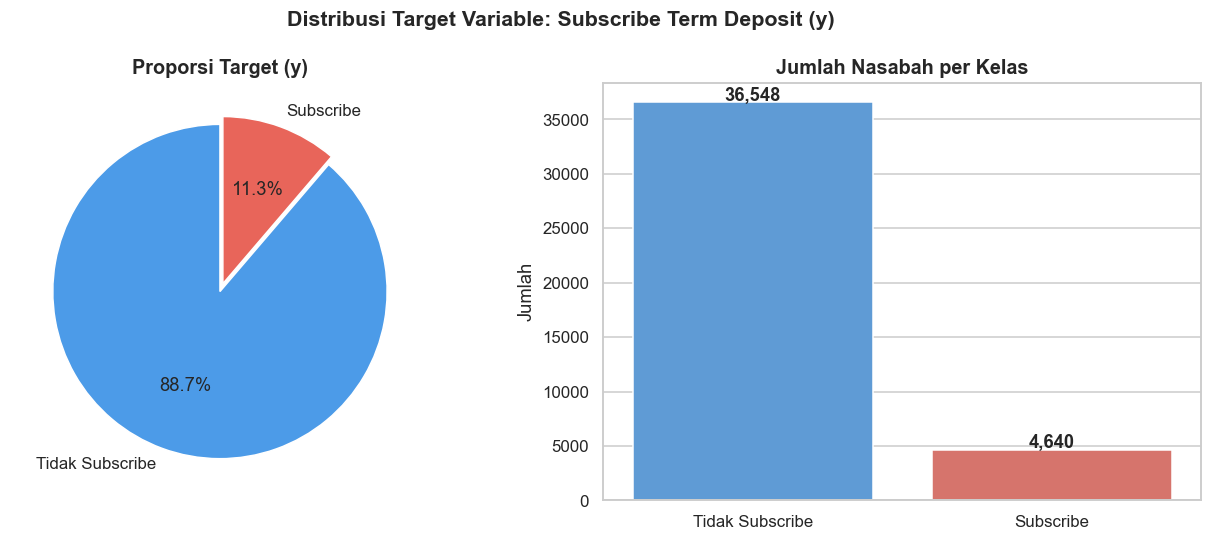

In [6]:
subscribe_counts = df['y'].value_counts()
subscribe_pct = df['y'].value_counts(normalize=True) * 100

print('=== Distribusi Target Variable (y) ===')
print(f"no  (Tidak Subscribe) : {subscribe_counts['no']:,} nasabah ({subscribe_pct['no']:.1f}%)")
print(f"yes (Subscribe)       : {subscribe_counts['yes']:,} nasabah ({subscribe_pct['yes']:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(subscribe_counts.values, labels=['Tidak Subscribe', 'Subscribe'],
            autopct='%1.1f%%', colors=['#4C9BE8', '#E8655A'],
            explode=(0, 0.05), startangle=90)
axes[0].set_title('Proporsi Target (y)', fontsize=13, fontweight='bold')

sns.barplot(x=['Tidak Subscribe', 'Subscribe'], y=subscribe_counts.values,
            palette=['#4C9BE8', '#E8655A'], ax=axes[1])
for i, v in enumerate(subscribe_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
axes[1].set_title('Jumlah Nasabah per Kelas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah')

plt.suptitle('Distribusi Target Variable: Subscribe Term Deposit (y)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> Dataset mengalami **class imbalance** signifikan dengan rasio ~89% : 11%.
> - Class majority : **Tidak Subscribe (88.7%)**
> - Class minority : **Subscribe (11.3%)**
>
> Ketidakseimbangan ini perlu ditangani dengan teknik **resampling** (SMOTE / Undersampling) pada tahap modeling.

## 3.2. Cek Data Duplikat

In [7]:
duplicate = df.duplicated().sum()
print(f'Jumlah Data Duplikat: {duplicate}')

Jumlah Data Duplikat: 12


In [8]:
df = df.drop_duplicates()
print(f'Shape setelah drop duplicates: {df.shape}')

Shape setelah drop duplicates: (41176, 21)


> Terdapat **12 data duplikat** yang telah dihapus. Dataset bersih: **41,176 baris**.

## 3.3. Cek Missing Values

In [9]:
# Cek missing values eksplisit (NaN)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / df.shape[0]) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct.round(2)})
display(missing_df)
print(f'\n✅ Total missing values: {missing.sum()}')

# Cek nilai 'unknown' sebagai proxy missing value
print('\n--- Nilai "unknown" per kolom kategorikal ---')
for col in df.select_dtypes(include='object').columns:
    n = (df[col] == 'unknown').sum()
    pct = n / len(df) * 100
    if n > 0:
        print(f'{col}: {n} ({pct:.1f}%)')

,Missing Count,Missing (%)
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
month,0,0.0
day_of_week,0,0.0



✅ Total missing values: 0

--- Nilai "unknown" per kolom kategorikal ---
job: 330 (0.8%)
marital: 80 (0.2%)
education: 1730 (4.2%)
default: 8596 (20.9%)
housing: 990 (2.4%)
loan: 990 (2.4%)


> - **Tidak ada missing value eksplisit (NaN)** pada dataset ini.
> - Namun terdapat nilai **`"unknown"`** pada beberapa kolom kategorikal yang berfungsi sebagai proxy missing value.
> - Nilai `unknown` **tidak akan dihapus** di tahap ini — akan diputuskan berdasarkan proporsi dan dampaknya di preprocessing.

## 3.4. Cek Outlier (Boxplot IQR)

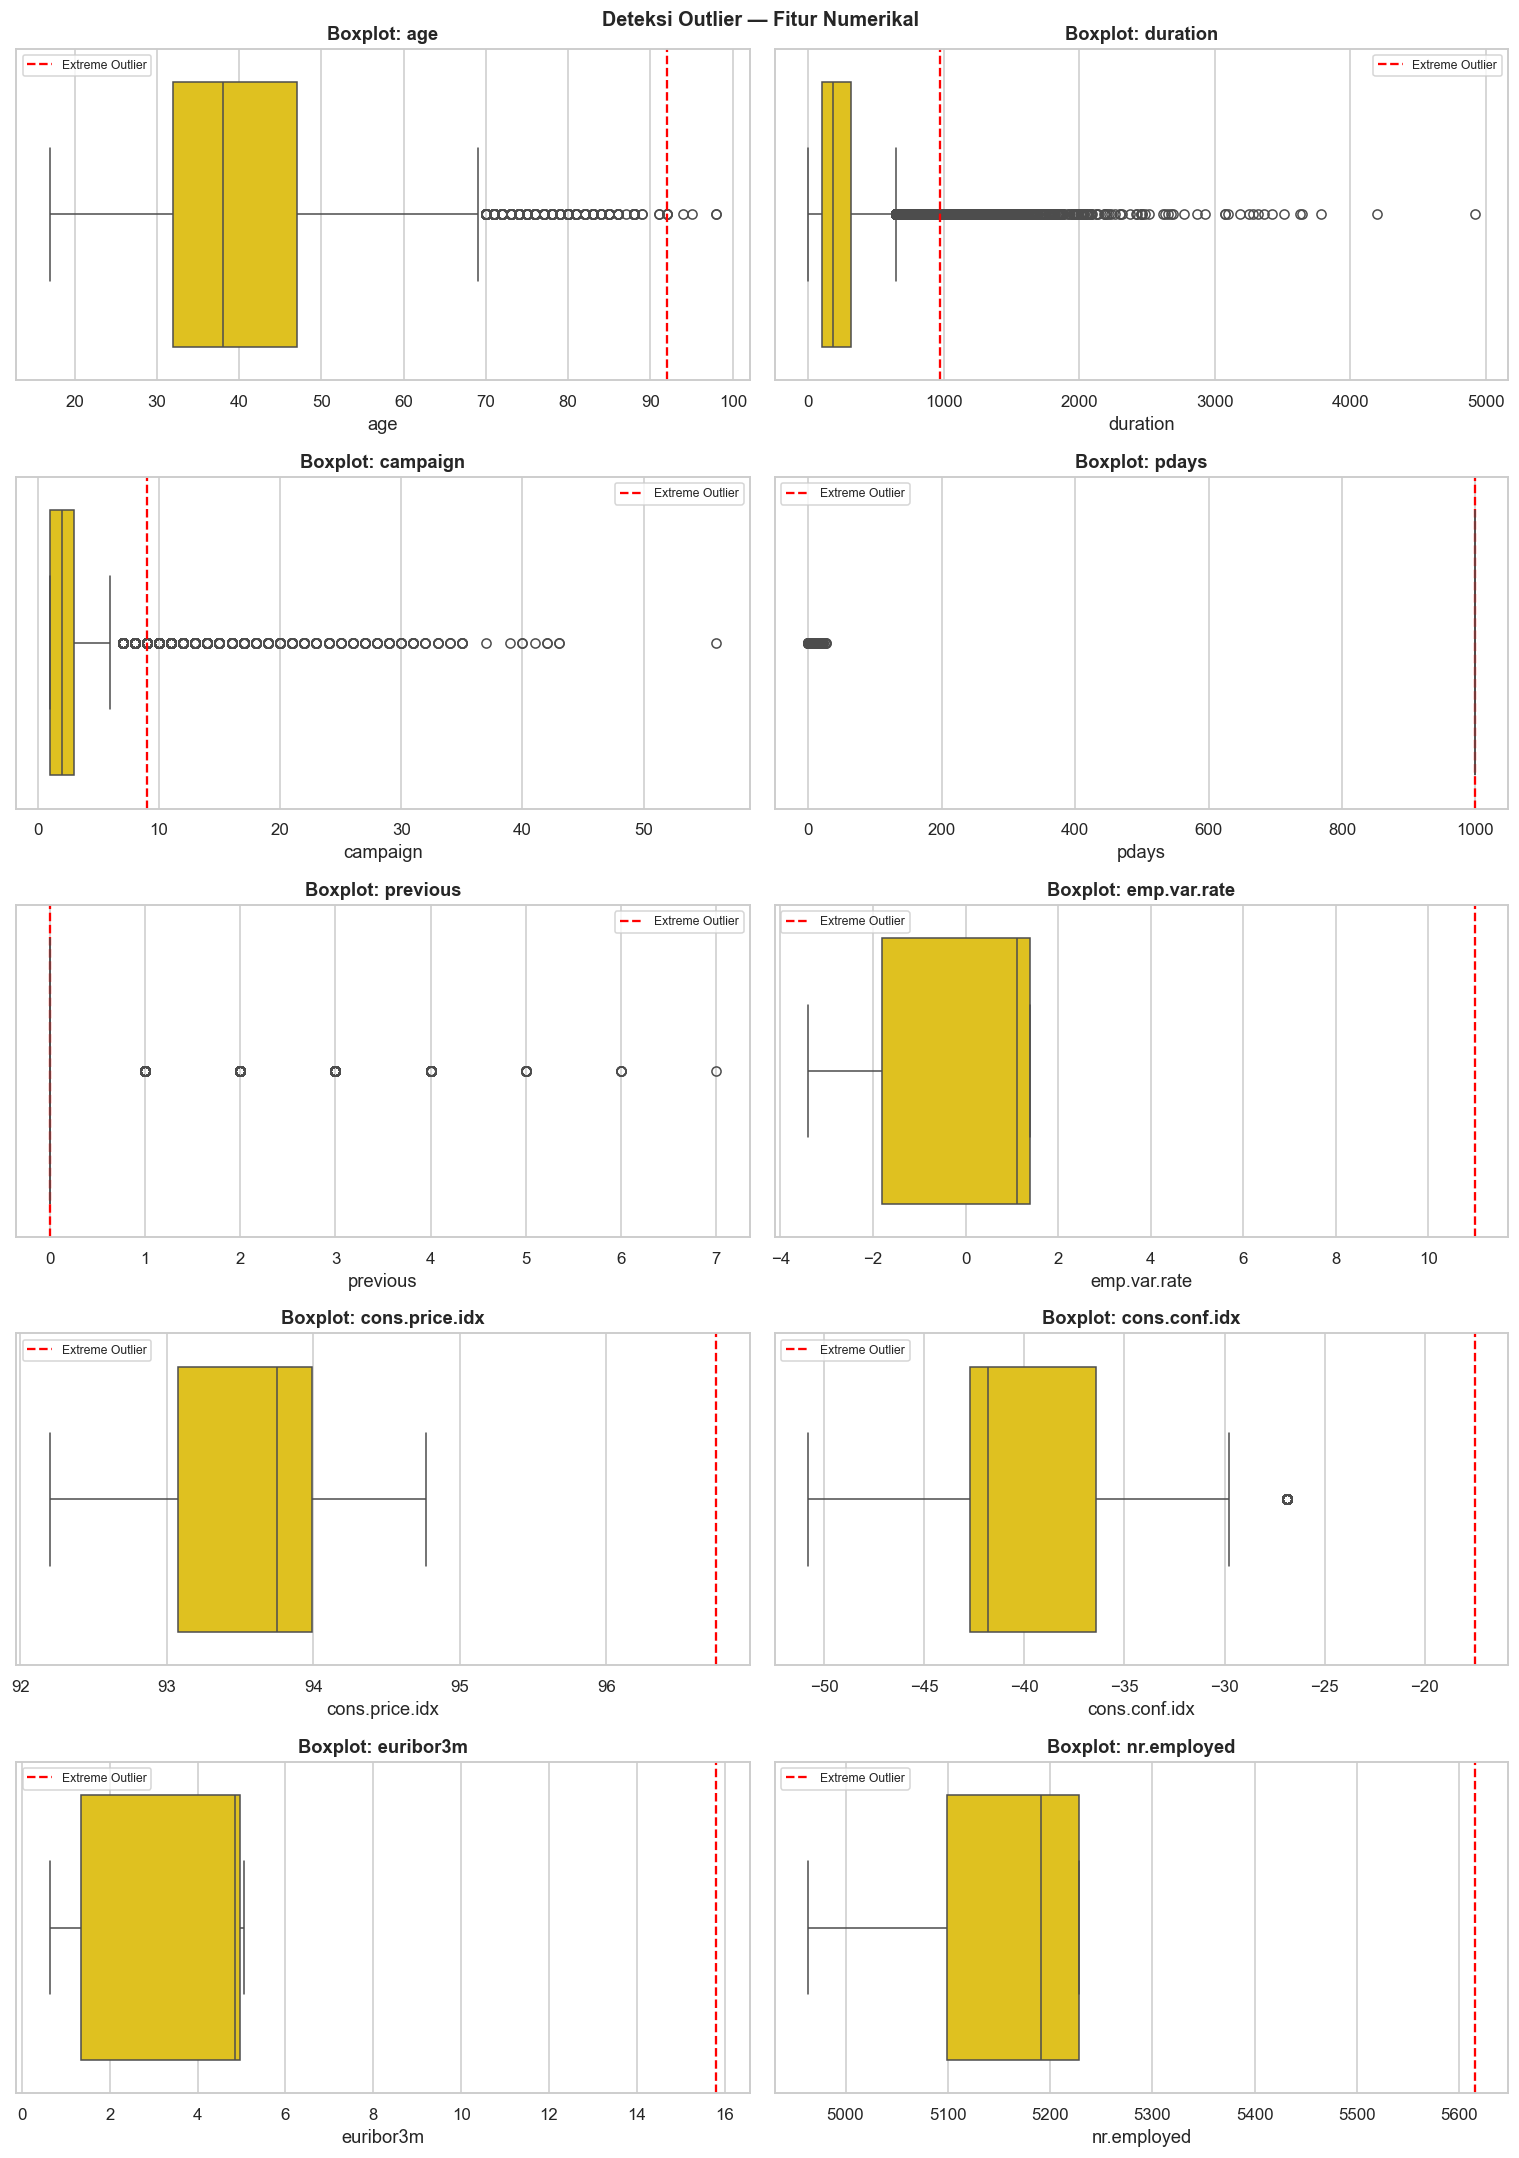

--- Jumlah Outlier (IQR Method) ---
age: 468 outlier(s)
duration: 2963 outlier(s)
campaign: 2406 outlier(s)
pdays: 1515 outlier(s)
previous: 5625 outlier(s)
emp.var.rate: 0 outlier(s)
cons.price.idx: 0 outlier(s)
cons.conf.idx: 446 outlier(s)
euribor3m: 0 outlier(s)
nr.employed: 0 outlier(s)


In [10]:
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

n_cols_plot = 2
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(14, 4*n_rows_plot))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    extreme_upper = Q3 + 3 * IQR
    sns.boxplot(x=df[col], color='gold', ax=axes[idx])
    axes[idx].axvline(x=extreme_upper, linestyle='--', color='red', label='Extreme Outlier')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].legend(fontsize=8)

for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Deteksi Outlier — Fitur Numerikal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('--- Jumlah Outlier (IQR Method) ---')
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()
    print(f'{col}: {n} outlier(s)')

> - **`duration`**: Panggilan sangat lama (>4000 detik) — nilai ekstrem tapi valid secara bisnis.
> - **`campaign`**: Ada nasabah dihubungi hingga 56 kali — akan di-cap di tahap preprocessing.
> - **`pdays = 999`**: Nilai sentinel (96.3% data) — bukan durasi nyata, perlu transformasi khusus.
> - Outlier **tidak dihapus** di sini karena masih masuk akal secara konteks bisnis.

## 3.5. Uji Normalitas (Shapiro-Wilk + QQ-Plot)

In [11]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Shapiro-Wilk Test
normality_results = {}
for col in numerical_cols:
    stat, p = stats.shapiro(df[col].dropna().sample(min(5000, len(df)), random_state=42))
    normality_results[col] = {'Shapiro Stat': round(stat, 4), 'p-value': round(p, 6)}

normality_df = pd.DataFrame(normality_results).T.reset_index()
normality_df.columns = ['Feature', 'Shapiro Stat', 'p-value']
normality_df['Distribusi'] = normality_df['p-value'].apply(
    lambda p: '✅ Normal' if p > 0.05 else '❌ Tidak Normal'
)
normality_df['Scaler Rekomendasi'] = normality_df['p-value'].apply(
    lambda p: 'MinMaxScaler' if p > 0.05 else 'RobustScaler'
)
display(normality_df)

,Feature,Shapiro Stat,p-value,Distribusi,Scaler Rekomendasi
0,age,0.9583,0.0,❌ Tidak Normal,RobustScaler
1,duration,0.7226,0.0,❌ Tidak Normal,RobustScaler
2,campaign,0.5557,0.0,❌ Tidak Normal,RobustScaler
3,pdays,0.1693,0.0,❌ Tidak Normal,RobustScaler
4,previous,0.3947,0.0,❌ Tidak Normal,RobustScaler
5,emp.var.rate,0.7648,0.0,❌ Tidak Normal,RobustScaler
6,cons.price.idx,0.9322,0.0,❌ Tidak Normal,RobustScaler
7,cons.conf.idx,0.9232,0.0,❌ Tidak Normal,RobustScaler
8,euribor3m,0.6883,0.0,❌ Tidak Normal,RobustScaler
9,nr.employed,0.7921,0.0,❌ Tidak Normal,RobustScaler


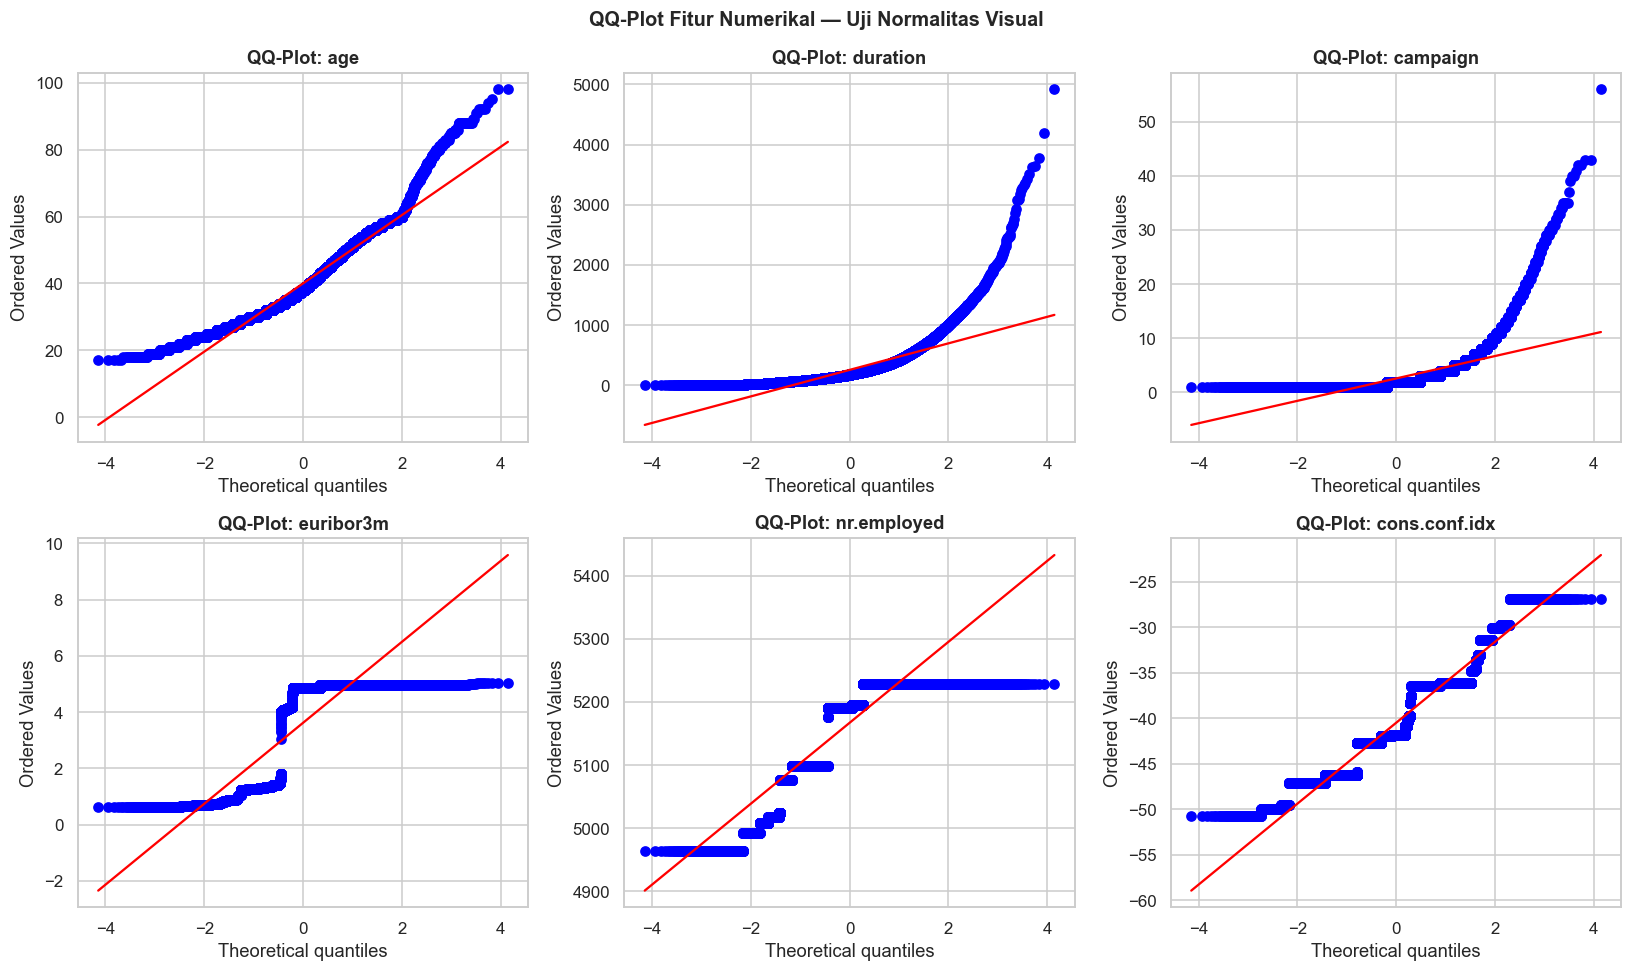

In [12]:
# QQ-Plot untuk fitur numerik kunci
key_num_qq = ['age', 'duration', 'campaign', 'euribor3m', 'nr.employed', 'cons.conf.idx']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, col in enumerate(key_num_qq):
    stats.probplot(df[col].dropna(), dist='norm', plot=axes[idx])
    axes[idx].set_title(f'QQ-Plot: {col}', fontweight='bold')
    axes[idx].get_lines()[1].set_color('red')  # garis referensi merah

plt.suptitle('QQ-Plot Fitur Numerikal — Uji Normalitas Visual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Kesimpulan Uji Normalitas:**
> - Semua kolom numerikal **tidak terdistribusi normal** (Shapiro-Wilk, p ≤ 0.05).
> - QQ-Plot mengkonfirmasi: titik-titik data menyimpang jauh dari garis diagonal, terutama `duration`, `campaign`, dan `previous` yang sangat right-skewed.
> - → Akan digunakan **RobustScaler** yang tahan terhadap distribusi skewed dan outlier.

## 3.6. Cek Kardinalitas Kolom Kategorikal

In [13]:
categorical_cols_raw = df.select_dtypes(include='object').columns.tolist()
unique_values = {col: df[col].unique() for col in categorical_cols_raw}
df_unique = pd.DataFrame(
    [(col, len(values), sorted(values)) for col, values in unique_values.items()],
    columns=['Kolom', 'Jumlah Nilai Unik', 'Nilai Unik']
)
pd.set_option('display.max_colwidth', None)
display(df_unique)

,Kolom,Jumlah Nilai Unik,Nilai Unik
0,job,12,"[admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown]"
1,marital,4,"[divorced, married, single, unknown]"
2,education,8,"[basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown]"
3,default,3,"[no, unknown, yes]"
4,housing,3,"[no, unknown, yes]"
5,loan,3,"[no, unknown, yes]"
6,contact,2,"[cellular, telephone]"
7,month,10,"[apr, aug, dec, jul, jun, mar, may, nov, oct, sep]"
8,day_of_week,5,"[fri, mon, thu, tue, wed]"
9,poutcome,3,"[failure, nonexistent, success]"


> Semua kolom kategorikal memiliki kardinalitas rendah (≤ 12 nilai unik) — cocok untuk **One-Hot Encoding**. Nilai `unknown` tersebar di 6 kolom dan akan ditangani di preprocessing.

## 3.7. Korelasi Fitur Numerikal terhadap Target (Pearson Heatmap)

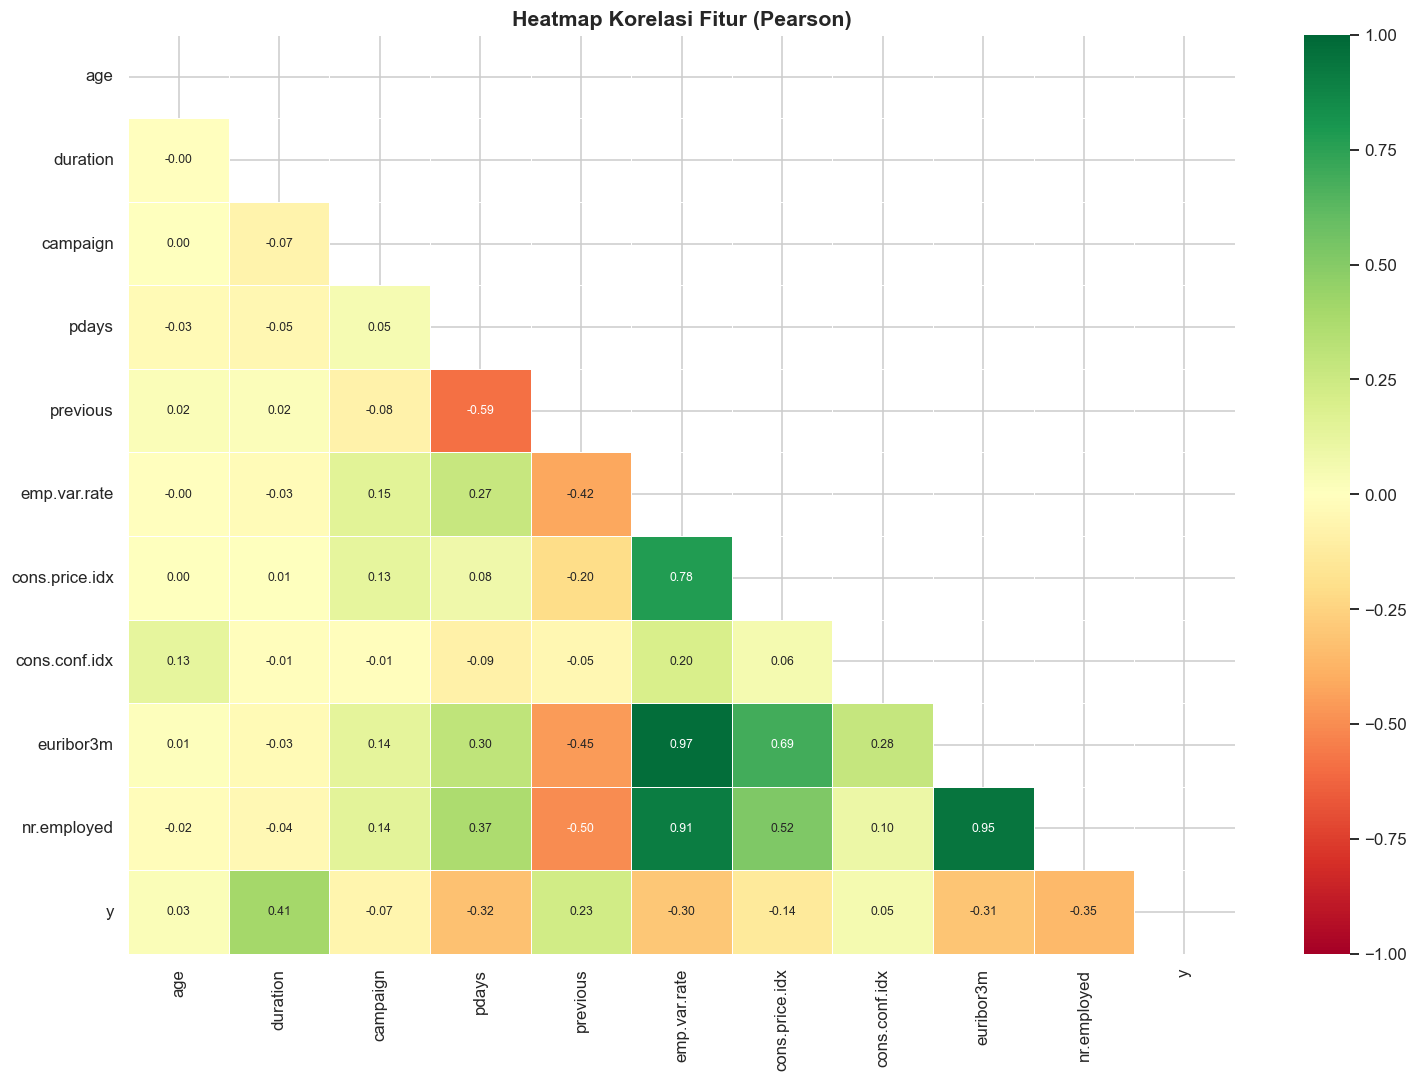


📊 Korelasi Fitur terhadap Target (y):
duration          0.405
nr.employed      -0.355
pdays            -0.325
euribor3m        -0.308
emp.var.rate     -0.298
previous          0.230
cons.price.idx   -0.136
campaign         -0.066
cons.conf.idx     0.055
age               0.030


In [14]:
df_encoded_corr = df.copy()
df_encoded_corr['y'] = df_encoded_corr['y'].map({'yes': 1, 'no': 0})

corr_matrix = df_encoded_corr.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f',
            linewidths=0.4, mask=mask, vmin=-1, vmax=1, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Fitur (Pearson)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr_matrix['y'].drop('y').sort_values(key=abs, ascending=False)
print('\n📊 Korelasi Fitur terhadap Target (y):')
print(target_corr.round(3).to_string())

> - **`duration`** memiliki **korelasi positif terbesar (0.405)** — semakin lama panggilan, semakin besar kemungkinan subscribe. Namun perlu hati-hati: nilai ini hanya diketahui *setelah* panggilan (data leakage risk).
> - **`nr.employed`** dan **`euribor3m`** berkorelasi negatif kuat — kondisi ekonomi dengan banyak karyawan & suku bunga tinggi menurunkan minat deposito.
> - **`pdays`** dan **`previous`** menunjukkan nasabah yang pernah dihubungi sebelumnya lebih responsif.

## 3.8. Korelasi Fitur Kategorikal terhadap Target (Cramér's V)

Heatmap Pearson hanya dapat menangkap korelasi antar variabel **numerik**. Untuk mengukur asosiasi antara **fitur kategorikal** dengan **target (y)**, digunakan **Cramér's V** — metrik statistik berbasis Chi-Square yang dirancang khusus untuk variabel nominal.

**Interpretasi nilai Cramér's V:**
- **≥ 0.3** → Asosiasi **Kuat**
- **0.15 – 0.3** → Asosiasi **Sedang**
- **< 0.15** → Asosiasi **Lemah**

Cramer's V — Asosiasi Fitur Kategorikal dengan Target (y):


,Cramer's V,Kekuatan Asosiasi
poutcome,0.3204,Kuat
month,0.2741,Sedang
job,0.1520,Sedang
contact,0.1446,Lemah
default,0.0991,Lemah
education,0.0672,Lemah
marital,0.0540,Lemah
day_of_week,0.0231,Lemah
housing,0.0095,Lemah
loan,0.0000,Lemah


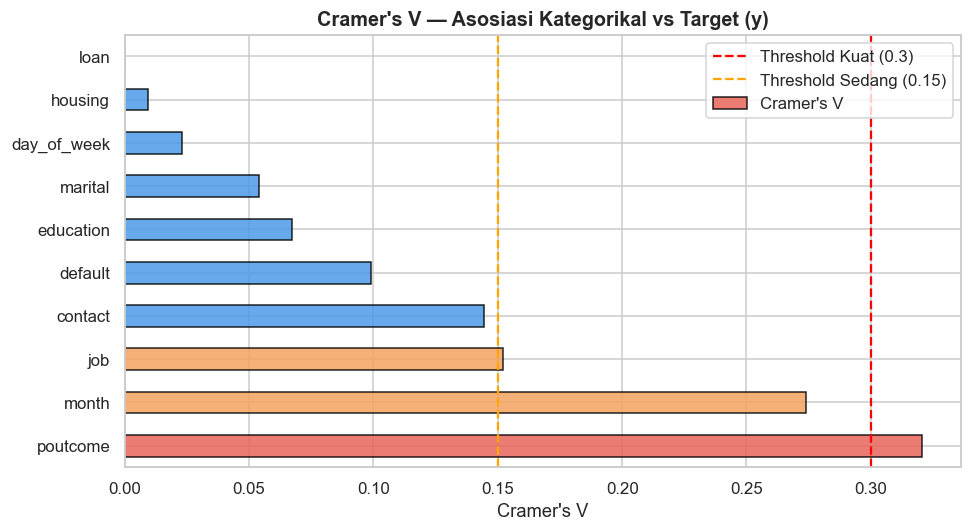

In [15]:
def cramers_v(x, y):
    """Menghitung Cramer's V antara dua variabel kategorikal."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)
    if denom <= 0:
        return 0
    return np.sqrt(phi2corr / denom)

# Hitung Cramer's V semua kolom kategorikal vs target y
cat_cols_for_cramer = [c for c in df.select_dtypes(include='object').columns if c != 'y']

cramer_results = {}
for col in cat_cols_for_cramer:
    cramer_results[col] = round(cramers_v(df[col], df['y']), 4)

cramer_df = pd.DataFrame.from_dict(cramer_results, orient='index', columns=["Cramer's V"])
cramer_df = cramer_df.sort_values(by="Cramer's V", ascending=False)
cramer_df['Kekuatan Asosiasi'] = cramer_df["Cramer's V"].apply(
    lambda v: 'Kuat' if v >= 0.3 else ('Sedang' if v >= 0.15 else 'Lemah')
)

print("Cramer's V — Asosiasi Fitur Kategorikal dengan Target (y):")
display(cramer_df)

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E8655A' if v >= 0.3 else ('#F4A261' if v >= 0.15 else '#4C9BE8')
          for v in cramer_df["Cramer's V"]]
cramer_df["Cramer's V"].plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.85)
ax.axvline(x=0.3, color='red', linestyle='--', label='Threshold Kuat (0.3)')
ax.axvline(x=0.15, color='orange', linestyle='--', label='Threshold Sedang (0.15)')
ax.set_title("Cramer's V — Asosiasi Kategorikal vs Target (y)", fontsize=13, fontweight='bold')
ax.set_xlabel("Cramer's V")
ax.legend()
plt.tight_layout()
plt.show()

> **Temuan Cramér's V:**
> - **`poutcome`** memiliki asosiasi **terkuat** (V ≥ 0.3) — hasil kampanye sebelumnya adalah prediktor kategorikal paling powerful.
> - **`contact`** dan **`month`** menunjukkan asosiasi sedang — jenis kontak dan timing kampanye berpengaruh signifikan.
> - **`default`, `housing`, `loan`** memiliki asosiasi lemah — informasi keuangan dasar kurang prediktif dibanding riwayat kampanye.
> - → Fitur dengan Cramér's V rendah bukan berarti tidak berguna, namun perlu diverifikasi di tahap modeling.

---

# **4. Exploratory Data Analysis (EDA)**

**Menjawab problem statement melalui analisis data eksploratif (EDA)** dengan visualisasi yang didukung angka kuantitatif dan *actionable insight*. Urutan EDA:

1. **Subscription Rate by Categorical Features** → Nasabah dengan karakteristik kategorikal apa yang paling berpotensi untuk *subscribe*?
2. **KDE Numerical Features** → Bagaimana distribusi numerik antara *subscribe* vs tidak?
3. **Macro Economic Features** → Kapan kondisi ekonomi paling mendukung kampanye?
4. **Segmentasi Usia & Riwayat Kontak** → Siapa segmen prioritas?
5. **Analisis Threshold Durasi** → Berapa lama durasi panggilan yang efektif?

> 📌 **Catatan metodologi:** EDA ini menggunakan `duration` sebagai variabel analitik untuk memahami pola perilaku nasabah. Namun sesuai batasan proyek (section 1.4), `duration` **tidak akan digunakan sebagai fitur input model prediksi** karena nilainya hanya tersedia setelah panggilan selesai.


## 4.1. Subscription Rate berdasarkan Fitur Kategorikal

**Pertanyaan:** Karakteristik kategorikal apa yang paling membedakan nasabah yang subscribe vs tidak?

Analisis ini menghitung **subscription rate per kategori** pada setiap fitur, dibandingkan dengan baseline rate keseluruhan (11.3%). Bar yang jauh di atas baseline = segmen prioritas tinggi.

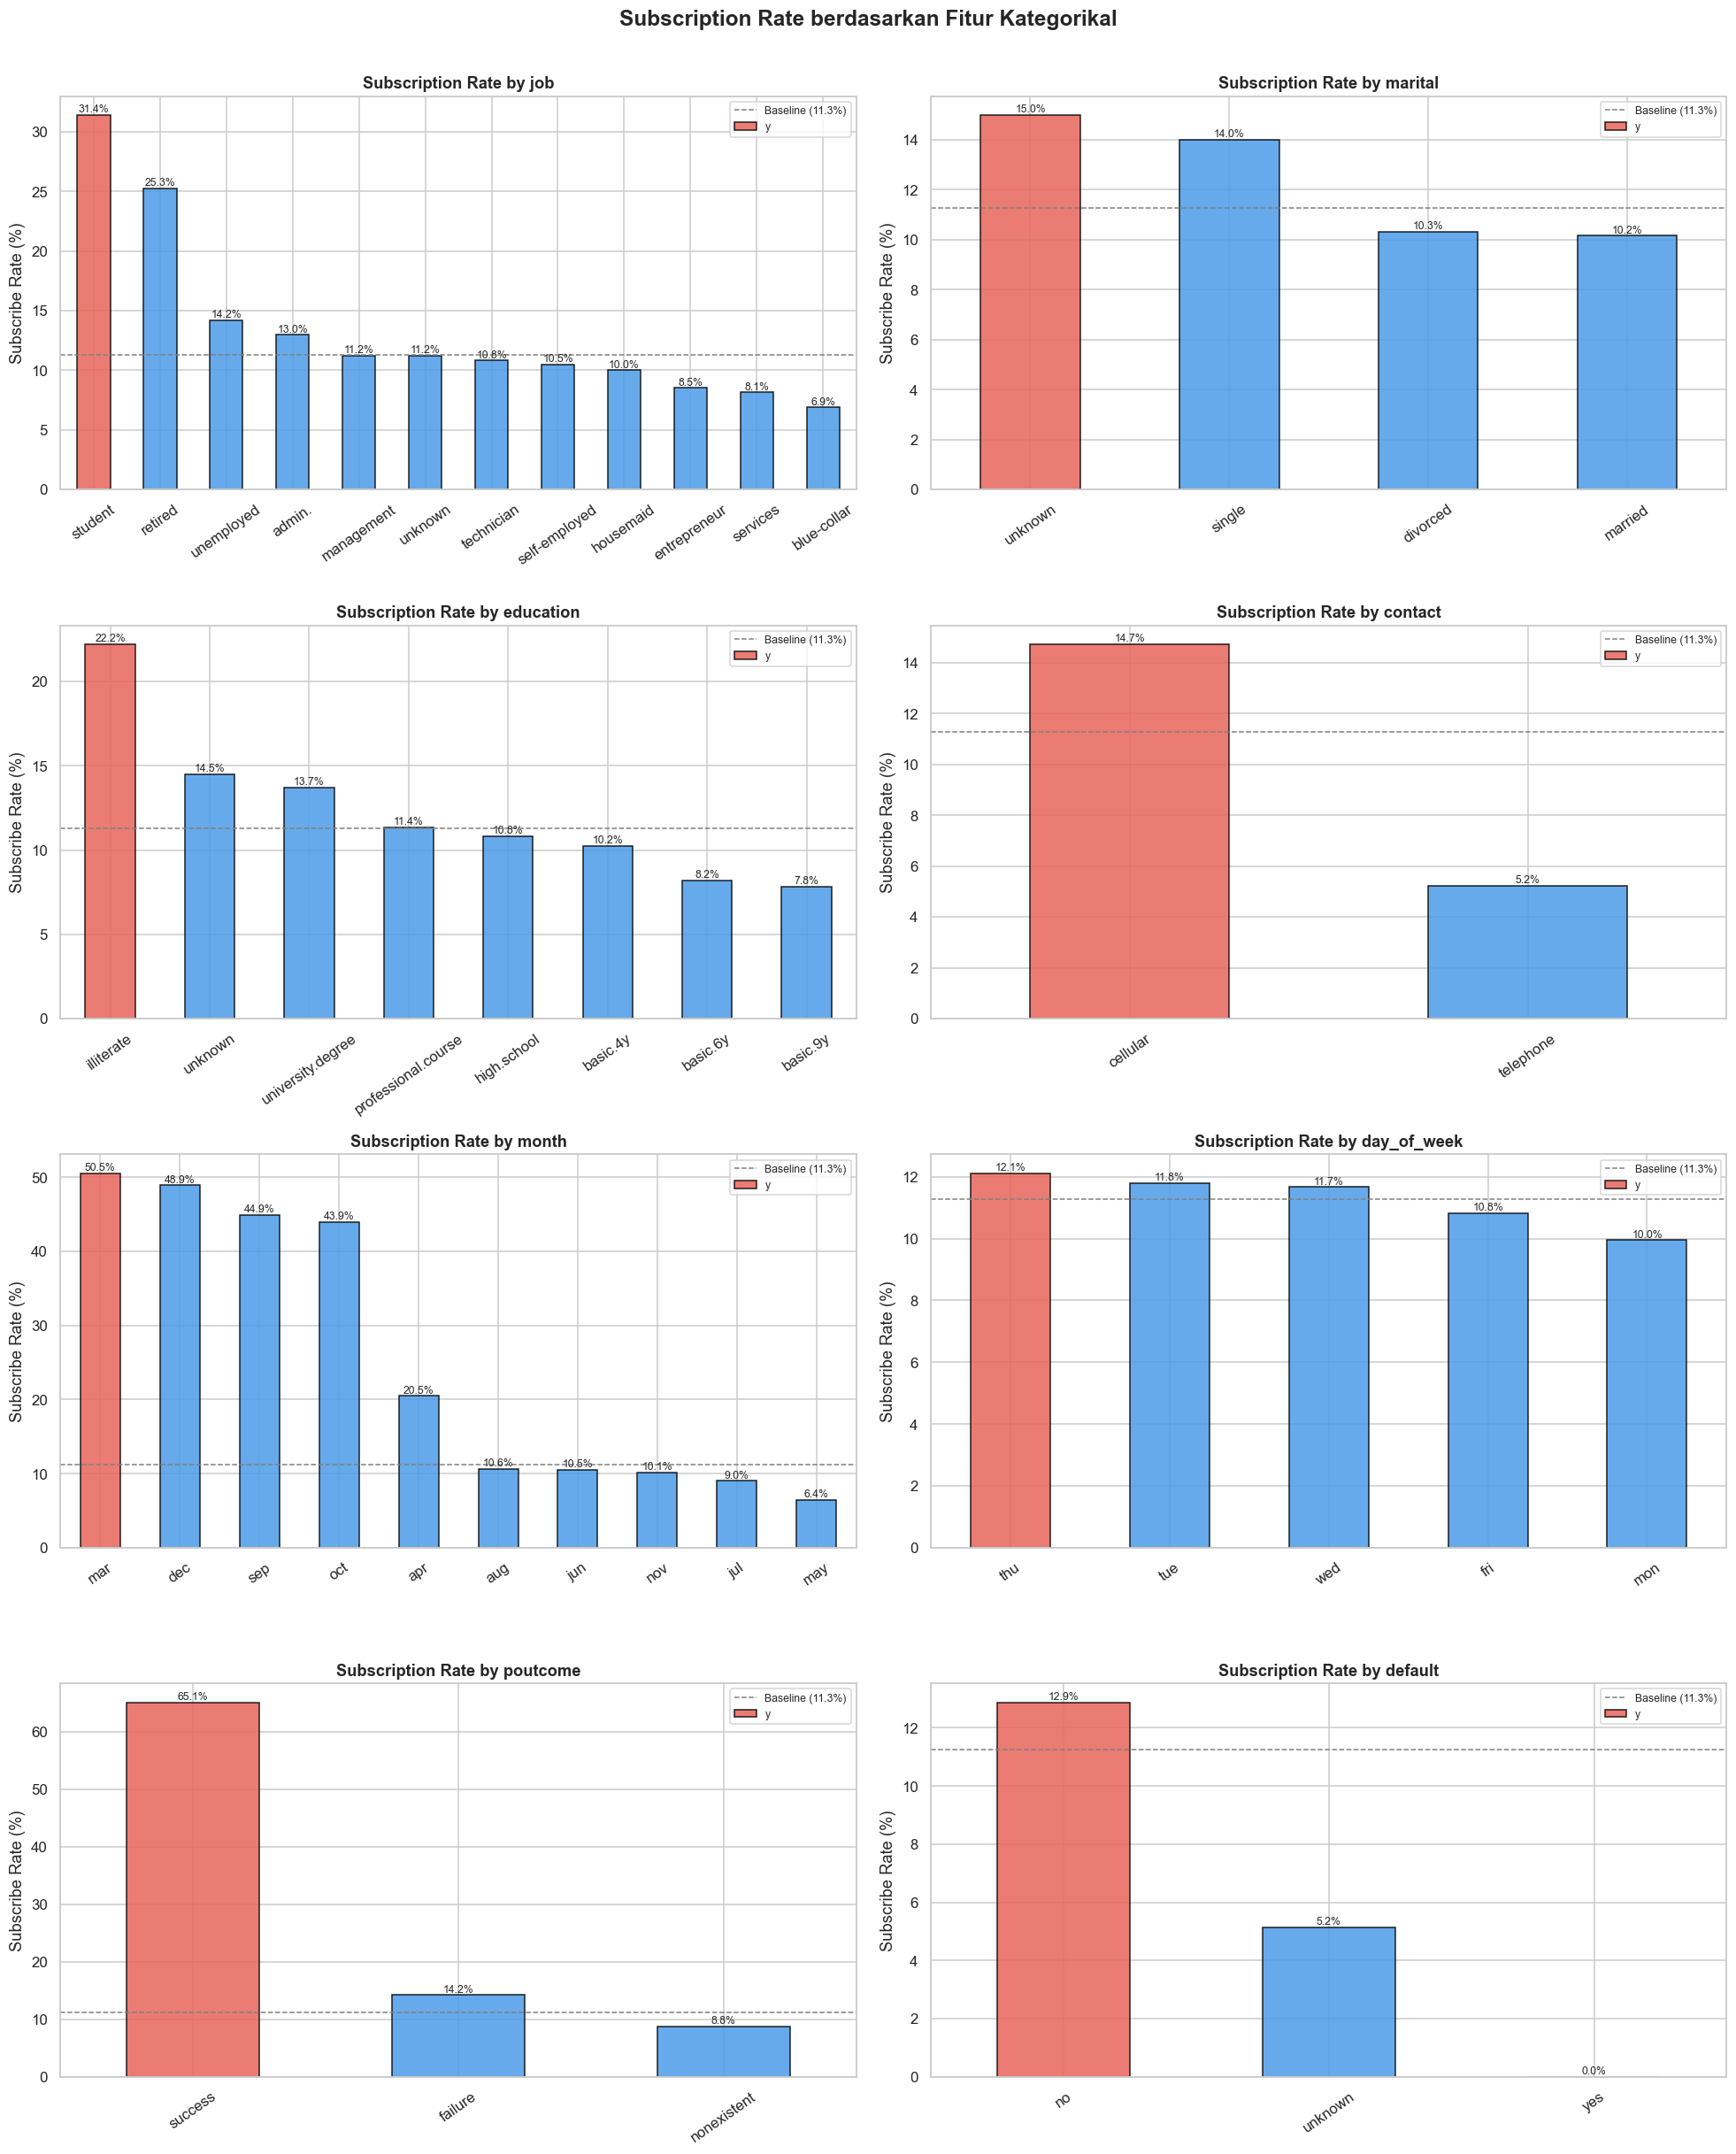

In [16]:
eda_cat_cols = ['job', 'marital', 'education', 'contact',
                'month', 'day_of_week', 'poutcome', 'default']

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()
baseline = (df['y'] == 'yes').mean() * 100

for idx, col in enumerate(eda_cat_cols):
    rate = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
    colors = ['#E8655A' if v == rate.max() else '#4C9BE8' for v in rate.values]
    rate.plot(kind='bar', ax=axes[idx], color=colors, edgecolor='black', alpha=0.85)
    axes[idx].axhline(y=baseline, color='gray', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.1f}%)')
    axes[idx].set_title(f'Subscription Rate by {col}', fontweight='bold')
    axes[idx].set_ylabel('Subscribe Rate (%)')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=35)
    axes[idx].legend(fontsize=8)
    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.1f}%',
                          (p.get_x() + p.get_width()/2, p.get_height()),
                          ha='center', va='bottom', fontsize=8)

plt.suptitle('Subscription Rate berdasarkan Fitur Kategorikal', fontsize=16, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

> **📊 Actionable Insight — Fitur Kategorikal:**
> - **`poutcome = success`** adalah prediktor terkuat — nasabah dengan riwayat subscribe di kampanye sebelumnya memiliki konversi **~65%**, hampir **6× baseline (11.3%)**. → *Prioritaskan re-engagement nasabah dengan histori sukses.*
> - **`contact = cellular`** menunjukkan konversi **~14.7%** vs telephone **~5%**. → *Pastikan database nomor seluler nasabah selalu terbarui.*
> - **Bulan `march` (~52%), `december` (~49%), `october` (~45%)** jauh di atas baseline. → *Alokasikan anggaran kampanye lebih besar di bulan-bulan ini.*
> - **`job = student` (~31%) dan `retired` (~25%)** memiliki rate subscribe jauh di atas rata-rata. → *Buat pesan marketing yang disesuaikan per segmen profesi.*

## 4.2. Distribusi Fitur Numerik (KDE + Mean Lines)

**Pertanyaan:** Bagaimana distribusi nilai numerik berbeda antara nasabah yang subscribe dan tidak?

KDE (Kernel Density Estimation) menampilkan distribusi probabilitas setiap fitur. Garis putus-putus menunjukkan nilai rata-rata masing-masing kelompok — semakin jauh jarak kedua garis, semakin informatif fitur tersebut untuk membedakan kedua kelas.

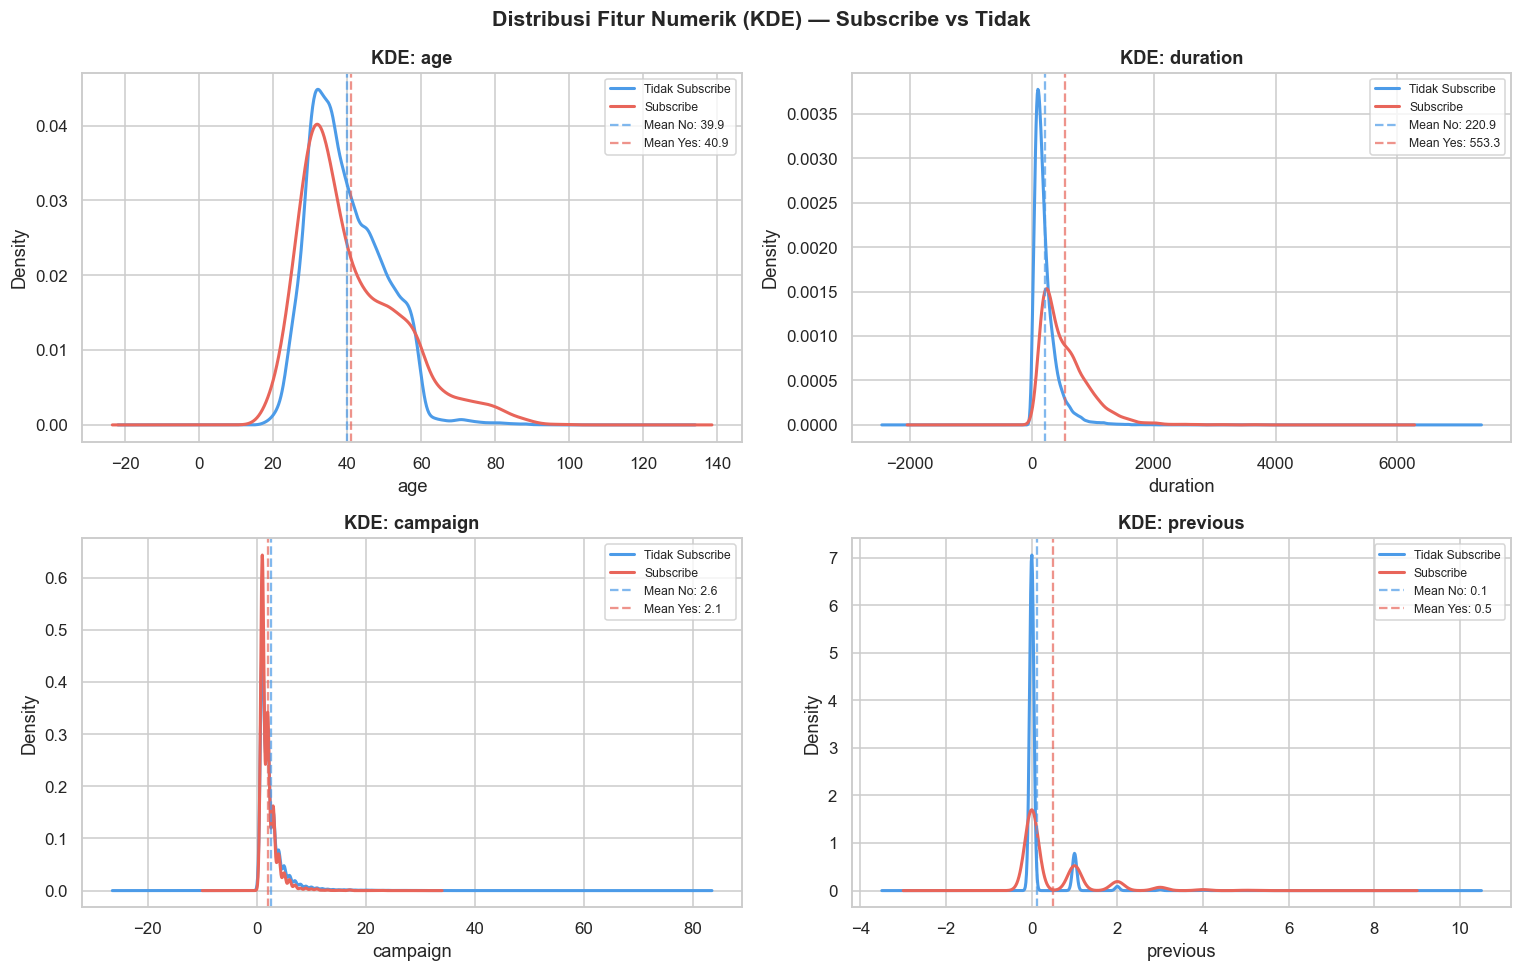

In [17]:
key_num = ['age', 'duration', 'campaign', 'previous']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, col in enumerate(key_num):
    for label, color in [('no', '#4C9BE8'), ('yes', '#E8655A')]:
        df[df['y'] == label][col].plot.kde(
            ax=axes[idx],
            label='Tidak Subscribe' if label == 'no' else 'Subscribe',
            color=color, linewidth=2)
    mean_no = df[df['y']=='no'][col].mean()
    mean_yes = df[df['y']=='yes'][col].mean()
    axes[idx].axvline(mean_no, color='#4C9BE8', linestyle='--', alpha=0.7, label=f'Mean No: {mean_no:.1f}')
    axes[idx].axvline(mean_yes, color='#E8655A', linestyle='--', alpha=0.7, label=f'Mean Yes: {mean_yes:.1f}')
    axes[idx].set_title(f'KDE: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].legend(fontsize=8)
    axes[idx].set_ylabel('Density')

plt.suptitle('Distribusi Fitur Numerik (KDE) — Subscribe vs Tidak', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📊 Actionable Insight — Fitur Numerik:**
> - **`duration`**: Nasabah yang subscribe rata-rata **~553 detik** vs **~220 detik** untuk yang tidak — lebih dari **2.5× lebih lama**. Engagement selama telepon adalah sinyal minat kuat. → *Latih agen untuk mempertahankan percakapan bermakna minimal 5 menit.*
> - **`campaign`**: Subscribe rata-rata hanya dihubungi **~2.1 kali**, non-subscribe **~2.6 kali**. Terlalu banyak kontak kontraproduktif. → *Batasi maksimal 3-5x kontak per nasabah.*
> - **`previous`**: Nasabah yang subscribe memiliki riwayat kontak sebelumnya lebih tinggi (~0.5 vs ~0.1) — menunjukkan keterbukaan terhadap bank lebih besar.

## 4.3. Distribusi Fitur Ekonomi Makro berdasarkan Target

**Pertanyaan:** Kondisi ekonomi seperti apa yang mendorong nasabah untuk subscribe term deposit?

Fitur ekonomi makro bersifat **eksternal** (tidak bisa dikontrol bank), namun sangat berpengaruh terhadap keputusan nasabah. Analisis ini membantu menentukan **timing optimal kampanye** berdasarkan kondisi makroekonomi.

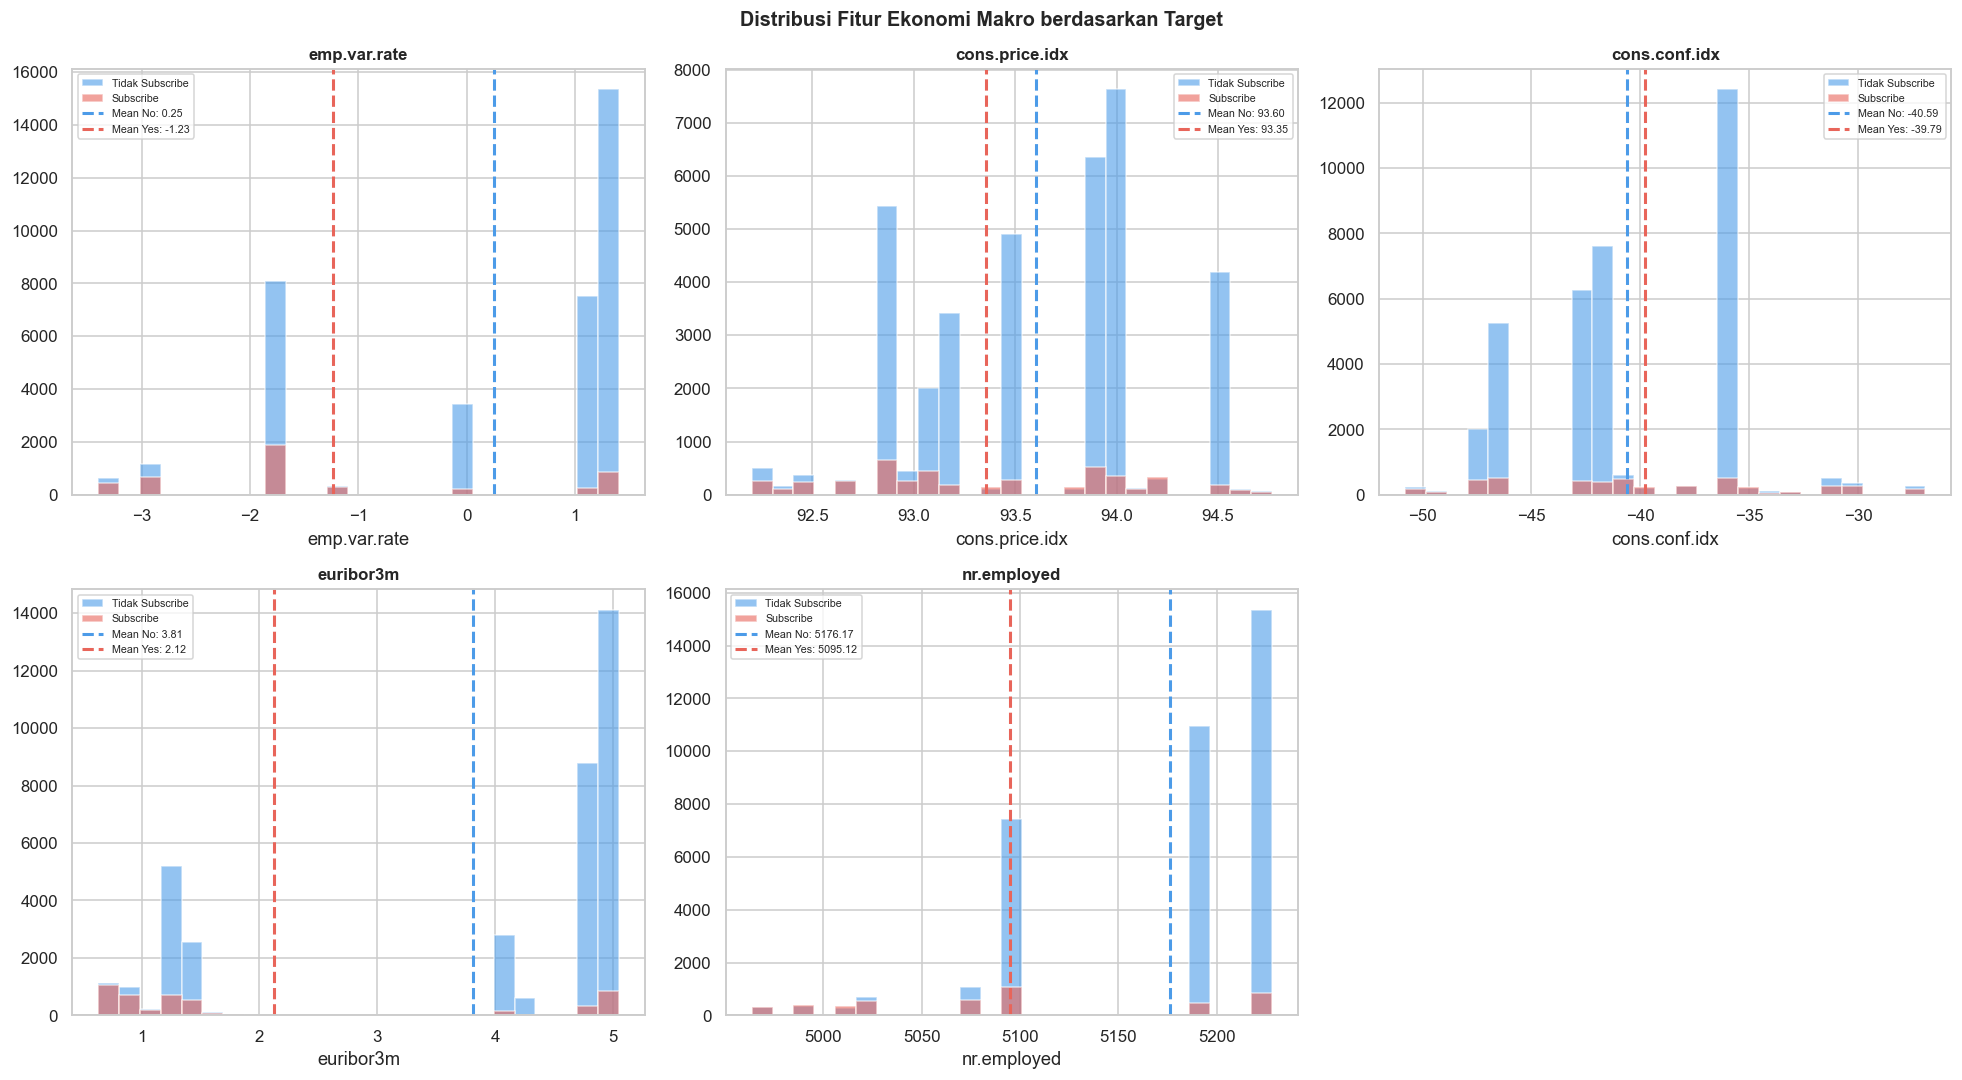

--- Perbedaan Mean Fitur Makro: Subscribe vs Tidak ---
emp.var.rate         | Mean No:   0.249 | Mean Yes:  -1.233 | Selisih: -1.482
cons.price.idx       | Mean No:  93.604 | Mean Yes:  93.355 | Selisih: -0.249
cons.conf.idx        | Mean No: -40.593 | Mean Yes: -39.791 | Selisih: +0.802
euribor3m            | Mean No:   3.811 | Mean Yes:   2.123 | Selisih: -1.688
nr.employed          | Mean No: 5176.166 | Mean Yes: 5095.120 | Selisih: -81.046


In [18]:
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(macro_cols):
    for label, color, name in [('no', '#4C9BE8', 'Tidak Subscribe'), ('yes', '#E8655A', 'Subscribe')]:
        df[df['y']==label][col].hist(bins=25, alpha=0.6, color=color,
                                       label=name, density=False, ax=axes[idx])
    mean_no = df[df['y']=='no'][col].mean()
    mean_yes = df[df['y']=='yes'][col].mean()
    axes[idx].axvline(mean_no, color='#4C9BE8', linestyle='--', linewidth=2, label=f'Mean No: {mean_no:.2f}')
    axes[idx].axvline(mean_yes, color='#E8655A', linestyle='--', linewidth=2, label=f'Mean Yes: {mean_yes:.2f}')
    axes[idx].set_title(col, fontweight='bold', fontsize=11)
    axes[idx].legend(fontsize=7)
    axes[idx].set_xlabel(col)

axes[-1].set_visible(False)

plt.suptitle('Distribusi Fitur Ekonomi Makro berdasarkan Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('--- Perbedaan Mean Fitur Makro: Subscribe vs Tidak ---')
for col in macro_cols:
    mean_no = df[df['y']=='no'][col].mean()
    mean_yes = df[df['y']=='yes'][col].mean()
    diff = mean_yes - mean_no
    print(f'{col:<20} | Mean No: {mean_no:7.3f} | Mean Yes: {mean_yes:7.3f} | Selisih: {diff:+.3f}')

> **📊 Actionable Insight — Kondisi Ekonomi Makro:**
> - **`euribor3m`**: Nasabah yang subscribe terkonsentrasi saat suku bunga **rata-rata 2.12%**, vs yang tidak subscribe saat **3.81%** — selisih **1.69 poin**. Saat bunga pasar rendah, deposito lebih menarik. → *Waktu terbaik kampanye saat euribor3m di bawah 2.5%.*
> - **`emp.var.rate`**: Kelompok subscribe rata-rata **-1.23** vs **+0.25** — kondisi ketenagakerjaan memburuk mendorong nasabah lebih berhati-hati dan menyimpan uang.
> - **`nr.employed`**: Kelompok subscribe rata-rata **5,095 karyawan** vs **5,176** — pasar kerja lebih lemah meningkatkan minat deposito.
> - → *Jadwalkan kampanye besar pada periode kontraksi ekonomi ringan — counter-intuitive namun terbukti dari data.*

## 4.4. Segmentasi Nasabah: Kelompok Usia & Riwayat Kontak

**Pertanyaan:** Segmen usia mana yang paling berpotensi? Apakah riwayat kontak sebelumnya berpengaruh signifikan?

Dua dimensi penting ini dianalisis bersama untuk mengidentifikasi **segmen prioritas** kampanye. `age` dibagi ke dalam kelompok untuk menangkap pola non-linear (U-shape), sementara `pdays` diubah ke binary flag untuk membedakan nasabah "warm" vs "cold".

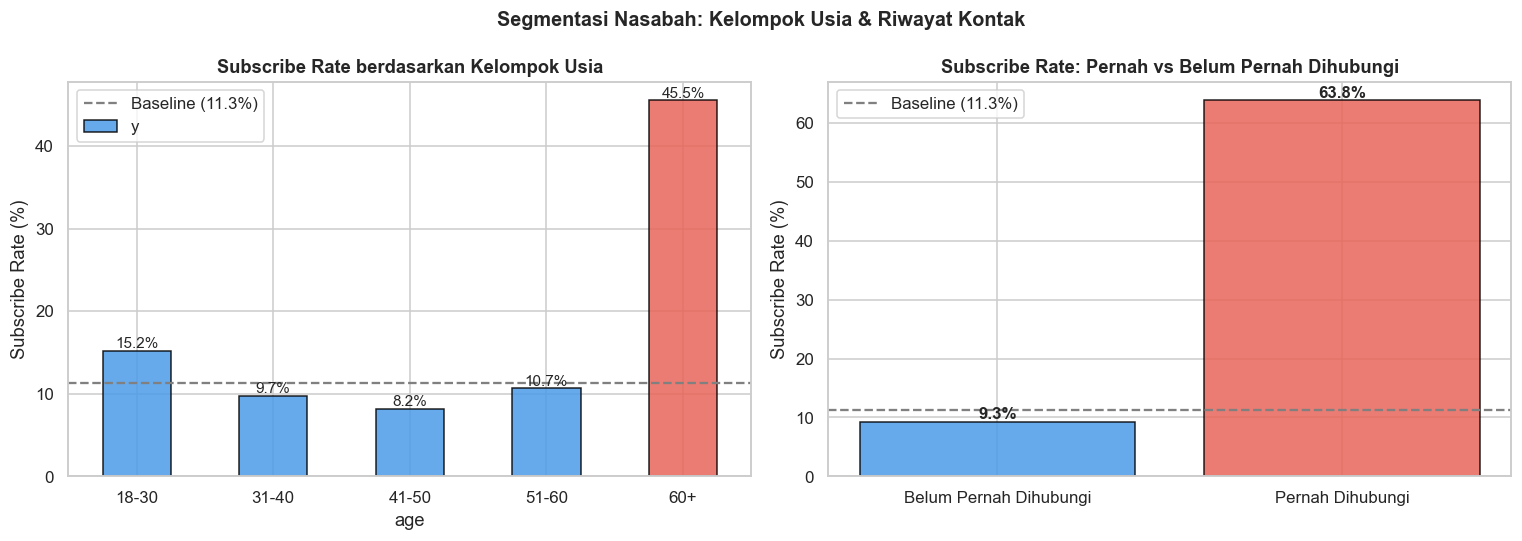

Subscribe rate 60+              : 45.5% (4.0x baseline)
Subscribe rate 31-40            : 9.7%
Subscribe rate pernah dihubungi : 63.8%
Subscribe rate belum dihubungi  : 9.3%
Rasio pernah vs belum           : 6.9x lebih tinggi


In [19]:
# Buat variabel temporary untuk visualisasi EDA
# (pembuatan fitur permanen akan dilakukan di bagian Data Preparation)
age_group_temp = pd.cut(df['age'], bins=[17, 30, 40, 50, 60, 100],
                         labels=['18-30', '31-40', '41-50', '51-60', '60+'])
contacted_before_temp = (df['pdays'] != 999).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
baseline = (df['y'] == 'yes').mean() * 100

age_sub = df.groupby(age_group_temp, observed=True)['y'].apply(lambda x: (x == 'yes').mean() * 100)
colors_age = ['#E8655A' if v == age_sub.max() else '#4C9BE8' for v in age_sub.values]
age_sub.plot(kind='bar', ax=axes[0], color=colors_age, edgecolor='black', alpha=0.85)
axes[0].axhline(y=baseline, color='gray', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline:.1f}%)')
axes[0].set_title('Subscribe Rate berdasarkan Kelompok Usia', fontweight='bold')
axes[0].set_ylabel('Subscribe Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

contact_sub = df.groupby(contacted_before_temp)['y'].apply(lambda x: (x == 'yes').mean() * 100)
bars = axes[1].bar(['Belum Pernah Dihubungi', 'Pernah Dihubungi'],
                    contact_sub.values, color=['#4C9BE8', '#E8655A'], edgecolor='black', alpha=0.85)
axes[1].axhline(y=baseline, color='gray', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline:.1f}%)')
axes[1].set_title('Subscribe Rate: Pernah vs Belum Pernah Dihubungi', fontweight='bold')
axes[1].set_ylabel('Subscribe Rate (%)')
axes[1].legend()
for bar, v in zip(bars, contact_sub.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Segmentasi Nasabah: Kelompok Usia & Riwayat Kontak', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Subscribe rate 60+              : {age_sub["60+"]:.1f}% ({age_sub["60+"]/baseline:.1f}x baseline)')
print(f'Subscribe rate 31-40            : {age_sub["31-40"]:.1f}%')
print(f'Subscribe rate pernah dihubungi : {contact_sub[1]:.1f}%')
print(f'Subscribe rate belum dihubungi  : {contact_sub[0]:.1f}%')
print(f'Rasio pernah vs belum           : {contact_sub[1]/contact_sub[0]:.1f}x lebih tinggi')

> **📊 Actionable Insight — Segmentasi:**
> - **Nasabah usia 60+** memiliki subscribe rate **~45%** — lebih dari **4× rata-rata baseline**. Kelompok senior lebih tertarik deposito sebagai instrumen penyimpanan aman. → *Buat kampanye khusus untuk nasabah 60+ yang menekankan keamanan dan stabilitas.*
> - **Nasabah yang pernah dihubungi sebelumnya** memiliki subscribe rate **~63.8%** vs hanya **~9.3%** — **7× lebih tinggi**. → *Bangun dan prioritaskan segmen "warm lead" dari nasabah yang sudah pernah berinteraksi dengan kampanye sebelumnya.*

## 4.5. Analisis Threshold Durasi Panggilan

**Pertanyaan:** Pada threshold durasi berapa subscribe rate mulai meningkat signifikan di atas baseline?

> ⚠️ **Catatan:** Analisis ini bersifat **deskriptif post-call** — tidak digunakan sebagai fitur prediksi. Tujuannya adalah memberikan insight kepada tim pelatihan agen tentang berapa lama panggilan yang efektif, dan memahami pola engagement nasabah yang akhirnya subscribe.

,Min. Duration (detik),Jumlah Nasabah,Subscribe,Subscribe Rate (%)
0,>= 100,31297,4561,14.57
1,>= 200,18533,3933,21.22
2,>= 300,11248,3131,27.84
3,>= 400,7199,2549,35.41
4,>= 500,4953,2105,42.50


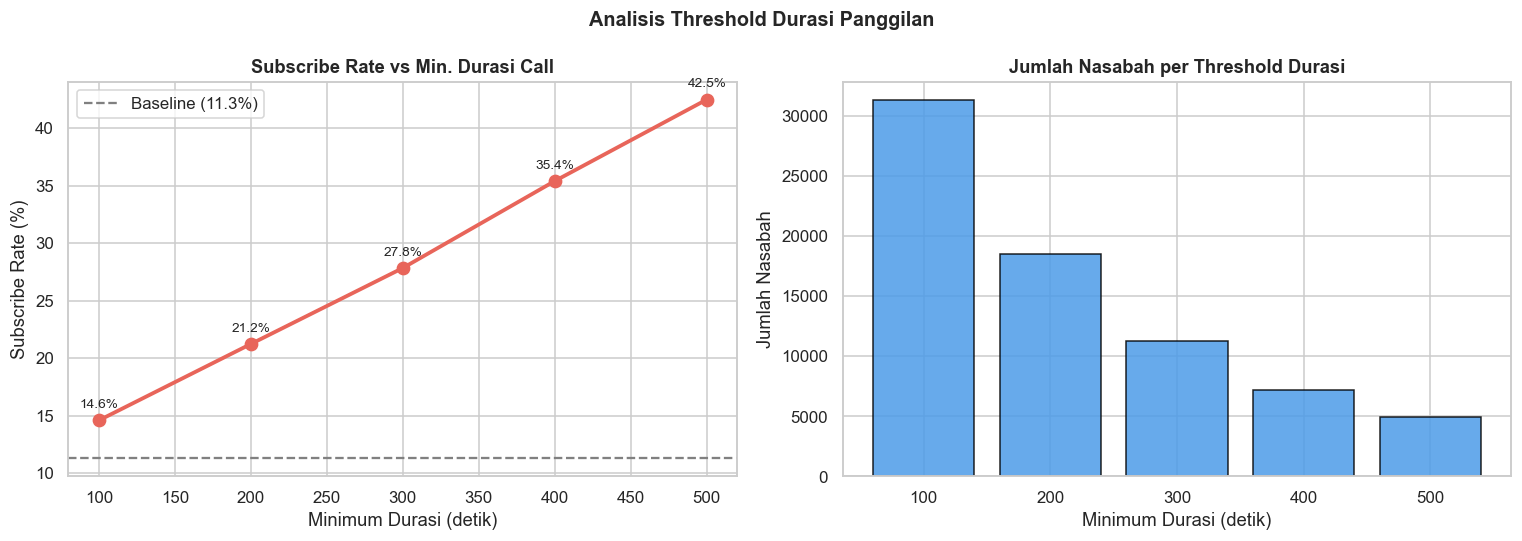

In [20]:
thresholds_dur = [100, 200, 300, 400, 500]
baris = []
for t in thresholds_dur:
    sub = df[df['duration'] >= t]
    baris.append({
        'Min. Duration (detik)': f'>= {t}',
        'Jumlah Nasabah': len(sub),
        'Subscribe': (sub['y'] == 'yes').sum(),
        'Subscribe Rate (%)': round((sub['y'] == 'yes').mean() * 100, 2)
    })
thresh_df = pd.DataFrame(baris)
display(thresh_df)

baseline = (df['y'] == 'yes').mean() * 100
rates = [df[df['duration'] >= t]['y'].apply(lambda x: x == 'yes').mean() * 100 for t in thresholds_dur]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds_dur, rates, marker='o', linewidth=2.5, color='#E8655A', markersize=8)
axes[0].axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.1f}%)')
for t, r in zip(thresholds_dur, rates):
    axes[0].annotate(f'{r:.1f}%', (t, r), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
axes[0].set_title('Subscribe Rate vs Min. Durasi Call', fontweight='bold')
axes[0].set_xlabel('Minimum Durasi (detik)')
axes[0].set_ylabel('Subscribe Rate (%)')
axes[0].legend()

axes[1].bar([str(t) for t in thresholds_dur],
            [df[df['duration'] >= t].shape[0] for t in thresholds_dur],
            color='#4C9BE8', edgecolor='black', alpha=0.85)
axes[1].set_title('Jumlah Nasabah per Threshold Durasi', fontweight='bold')
axes[1].set_xlabel('Minimum Durasi (detik)')
axes[1].set_ylabel('Jumlah Nasabah')

plt.suptitle('Analisis Threshold Durasi Panggilan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **📊 Key Business Insight — Durasi Sebagai Indikator Minat:**
> - **Durasi ≥ 300 detik: subscribe rate ~27.8%** vs baseline 11.3% — lebih dari **2.5× lipat**.
> - **Durasi ≥ 500 detik: subscribe rate ~42.5%** — hampir separuh nasabah akhirnya subscribe.
> - → Agen yang mempertahankan percakapan >5 menit jauh lebih efektif. Gunakan durasi sebagai KPI pelatihan agen.
> - **Catatan:** `duration` hanya diketahui setelah panggilan — tidak bisa digunakan sebagai fitur prediksi real-time, tapi berguna untuk analisis post-hoc.

### 🔍 Ringkasan EDA — Siapa yang Berpotensi Subscribe?

| Temuan | Detail Kuantitatif | Aksi Bisnis |
|---|---|---|
| Subscribe rate keseluruhan | **11.3%** (4.640 dari 41.176 nasabah) | Fokus quality over quantity panggilan |
| Prediktor kategorikal terkuat | `poutcome = success` → **~65%** (~6× baseline) | Re-engage nasabah histori sukses lebih dulu |
| Prediktor numerik terkuat | `duration` korelasi **0.405**, Mean Yes **553 dtk** vs No **220 dtk** | Gunakan sebagai KPI pelatihan agen *(bukan fitur model)* |
| Kondisi ekonomi optimal | Subscribe rate tinggi saat **euribor3m < 2.5%** | Sesuaikan timing kampanye dengan kondisi makro |
| Segmen usia terbaik | Usia **60+** → **~45%** rate (**4× baseline**) | Prioritaskan kampanye untuk nasabah lansia |
| Riwayat kontak | Pernah dihubungi → **63.8%** subscribe (**7× lebih tinggi**) | Bangun & prioritaskan *warm lead* database |
| Asosiasi kategorikal | `poutcome` Cramér's V tertinggi, `default` paling lemah | Fokus fitur kampanye, bukan status kredit dasar |

> **Kesimpulan EDA:** Nasabah yang paling berpotensi subscribe adalah mereka yang **(1)** pernah dihubungi dan berhasil di kampanye sebelumnya, **(2)** berusia 60+, **(3)** dihubungi via cellular, dan **(4)** kampanye dilakukan saat kondisi suku bunga pasar rendah. Ini adalah profil prioritas untuk tim telemarketing.

---

# **5. Data Preprocessing**

**Menyiapkan data untuk tahap modeling** berdasarkan temuan dari EDA. Setiap langkah preprocessing memiliki justifikasi yang bersumber dari analisis sebelumnya.

Urutan preprocessing dilakukan sebagai berikut:
1. **Fill Missing Value** → Tangani nilai `unknown`
2. **Casting Data Type** → Pastikan tipe data sesuai
3. **Inconsistent Variable** → Tangani nilai sentinel `pdays = 999`
4. **Remove Data Duplication** → Sudah dilakukan di Data Quality Check
5. **Outlier Handling** → Drop `duration = 0`, cap `campaign`
6. **Feature Engineering** → Buat 5 fitur baru berdasarkan temuan EDA
7. **Data Preprocessing** → Pemilihan Fitur dan Split Data dengan stratify
8. **Preprocessing Pipeline** → Scaling + Encoding

## 5.1. Fill Missing Value

Dari Data Quality Check diketahui **tidak ada NaN eksplisit**, namun terdapat nilai `unknown` di 6 kolom kategorikal yang berfungsi sebagai **proxy missing value**.

Analisis di bawah membandingkan subscription rate antara nilai `unknown` vs nilai yang diketahui untuk menentukan strategi penanganannya.

In [21]:
# Analisis nilai 'unknown': proporsi dan dampaknya terhadap subscribe rate
unknown_analysis = []
for col in [c for c in df.select_dtypes(include='object').columns if c != 'y']:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        pct = n / len(df) * 100
        sub_unk   = (df[df[col] == 'unknown']['y'] == 'yes').mean() * 100
        sub_known = (df[df[col] != 'unknown']['y'] == 'yes').mean() * 100
        unknown_analysis.append({
            'Kolom': col,
            'Jumlah Unknown': n,
            'Proporsi (%)': round(pct, 1),
            'Sub Rate Unknown (%)': round(sub_unk, 1),
            'Sub Rate Known (%)': round(sub_known, 1)
        })

unknown_df = pd.DataFrame(unknown_analysis)
display(unknown_df)

,Kolom,Jumlah Unknown,Proporsi (%),Sub Rate Unknown (%),Sub Rate Known (%)
0,job,330,0.8,11.2,11.3
1,marital,80,0.2,15.0,11.3
2,education,1730,4.2,14.5,11.1
3,default,8596,20.9,5.2,12.9
4,housing,990,2.4,10.8,11.3
5,loan,990,2.4,10.8,11.3


> **Keputusan penanganan nilai `unknown`:**
>
> Berdasarkan analisis di atas, strategi yang dipilih adalah **mempertahankan `unknown` sebagai kategori tersendiri** — bukan dihapus atau diimputasi. Alasannya:
> - Proporsi mayoritas kolom masih kecil (< 5%), kecuali `default` (20.9%)
> - Subscribe rate antara `unknown` dan `known` **tidak berbeda signifikan** di sebagian besar kolom — artinya `unknown` bukan noise, tapi informasi yang valid
> - Khusus `default`: subscribe rate `unknown` (5.2%) justru **jauh lebih rendah** dari `known` (12.9%) — ini sinyal prediktif yang sayang dibuang
> - Saat modeling nanti, **Simple Imputer dengan strategy `most_frequent`** digunakan di dalam pipeline — ini akan mengganti `unknown` dengan modus kategori lain saat proses encoding

## 5.2. Casting Data Type

Memastikan semua kolom memiliki tipe data yang sesuai sebelum preprocessing berlanjut.

In [22]:
print('Tipe Data Saat Ini')
print(df.dtypes)
print(f'\nTotal fitur numerik  : {len(df.select_dtypes(include="number").columns)}')
print(f'Total fitur kategorikal: {len(df.select_dtypes(include="object").columns)}')

Tipe Data Saat Ini
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Total fitur numerik  : 10
Total fitur kategorikal: 11


> Semua tipe data sudah sesuai:
> - Fitur numerik bertipe `int64` / `float64` ✅
> - Fitur kategorikal bertipe `object` ✅
> - **Tidak diperlukan casting** pada dataset ini

## 5.3. Inconsistent Variable

Dari EDA diidentifikasi satu inkonsistensi utama: **`pdays = 999`**.

Nilai `999` bukan durasi hari yang sebenarnya — ini adalah **kode sentinel** yang artinya nasabah *belum pernah dihubungi sebelumnya*. Menggunakannya sebagai nilai numerik akan menyesatkan model karena model akan menginterpretasikan 999 sebagai "dihubungi 999 hari yang lalu" padahal artinya "belum pernah sama sekali".

In [23]:
print(f"Nilai 999 pada pdays : {(df['pdays'] == 999).sum():,} baris ({(df['pdays']==999).mean()*100:.1f}%)")
print(f"Nilai non-999 (valid) : {(df['pdays'] != 999).sum():,} baris ({(df['pdays']!=999).mean()*100:.1f}%)")
print()
print("Ini bukan outlier biasa — 999 adalah kode sentinel.")
print("Akan diubah menjadi fitur binary 'contacted_before' di tahap Feature Engineering.")

Nilai 999 pada pdays : 39,661 baris (96.3%)
Nilai non-999 (valid) : 1,515 baris (3.7%)

Ini bukan outlier biasa — 999 adalah kode sentinel.
Akan diubah menjadi fitur binary 'contacted_before' di tahap Feature Engineering.


## 5.4. Remove Data Duplication

Penghapusan duplikat telah dilakukan di **Section 3.2 (Data Quality Check)**. 12 baris duplikat sudah dihapus. Dataset saat ini bersih dengan **41,176 baris**.

In [24]:
# Konfirmasi tidak ada duplikat tersisa
print(f'Jumlah duplikat tersisa : {df.duplicated().sum()}')
print(f'Shape dataset bersih    : {df.shape}')

Jumlah duplikat tersisa : 0
Shape dataset bersih    : (41176, 21)


## 5.5. Outlier Handling

Berdasarkan temuan dari **Section 3.4 (Cek Outlier)**, ada dua penanganan yang perlu dilakukan.

### 5.5.1. Drop `duration == 0`

In [25]:
# duration == 0 artinya panggilan tidak pernah tersambung
# Tidak ada informasi bisnis yang bisa diambil dari baris ini
print(f'Baris dengan duration == 0 : {(df["duration"] == 0).sum()} baris')
df = df[df['duration'] > 0].reset_index(drop=True)
print(f'Shape setelah drop         : {df.shape}')

Baris dengan duration == 0 : 4 baris
Shape setelah drop         : (41172, 21)


> **4 baris** dengan `duration = 0` dihapus. Panggilan tidak pernah terjadi → tidak ada interaksi antara agen dan nasabah → informasi ini tidak relevan untuk memprediksi propensity.

### 5.5.2. Capping `campaign`

In [26]:
# Dari EDA: subscribe rate nasabah yang dihubungi >10 kali sudah mendekati nol
# Cap di 20 untuk meredam pengaruh nilai ekstrem tanpa membuang data
print(f'Sebelum cap — max: {df["campaign"].max()}, values > 20: {(df["campaign"] > 20).sum()}')
df['campaign'] = df['campaign'].clip(upper=20)
print(f'Sesudah cap — max: {df["campaign"].max()}')

Sebelum cap — max: 56, values > 20: 157
Sesudah cap — max: 20


> `campaign` di-cap di nilai 20. Subscribe rate untuk nasabah yang dihubungi `excessive` (>6 kali) sudah hanya **4.6%** — jauh di bawah baseline. Nilai ekstrem (hingga 56) hanya akan mendistorsi model tanpa tambahan informasi prediktif.

## 5.6. Feature Engineering

Berdasarkan temuan EDA, dibuat **5 fitur baru** yang menangkap pola non-linear dan konteks bisnis lebih dalam. Setiap fitur punya justifikasi langsung dari data.

### FE 1 — `contacted_before` (dari `pdays`)

**Justifikasi dari EDA 4:** `pdays = 999` artinya belum pernah dihubungi — ini kode sentinel, bukan angka. Subscribe rate nasabah yang pernah dihubungi (**63.8%**) vs belum pernah (**9.3%**) berbeda **7×** — sinyal terkuat di seluruh dataset.

In [27]:
df['contacted_before'] = (df['pdays'] != 999).astype(int)
df.drop(columns=['pdays'], inplace=True)

print('Distribusi contacted_before:')
print(df['contacted_before'].value_counts().to_string())
print()
cb = df.groupby('contacted_before')['y'].apply(lambda x: (x=='yes').mean()*100)
print('Subscribe rate per contacted_before:')
print(cb.round(1).to_string())

Distribusi contacted_before:
contacted_before
0    39657
1     1515

Subscribe rate per contacted_before:
contacted_before
0     9.3
1    63.8


> Nasabah yang **pernah dihubungi** memiliki subscribe rate **63.8%** vs hanya **9.3%** — **7× lebih tinggi**. Transformasi dari `pdays` ke binary ini menghilangkan nilai sentinel yang misleading dan menggantinya dengan informasi yang jauh lebih prediktif.

### FE 2 — `age_group` (dari `age`)

**Justifikasi dari EDA 4:** Pola usia bersifat **U-shape** — bukan linear. Usia 60+ dan 18-30 punya rate di atas rata-rata, sedangkan 31-50 justru di bawah. Model tidak bisa menangkap pola ini dari nilai numerik mentah.

In [28]:
df['age_group'] = pd.cut(df['age'],
                          bins=[17, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])

print('Subscribe rate per age_group:')
print(df.groupby('age_group', observed=True)['y']
      .apply(lambda x: (x=='yes').mean()*100).round(1).to_string())

Subscribe rate per age_group:
age_group
18-30    15.2
31-40     9.8
41-50     8.2
51-60    10.7
60+      45.5


> Usia 60+ subscribe rate **45.5%** — lebih dari **4× baseline**. Binning ini memungkinkan model menangkap pola U-shape yang tidak bisa ditangkap nilai numerik mentah.

### FE 3 — `euribor_level` (dari `euribor3m`)

**Justifikasi dari EDA 3:** Subscribe rate tidak berubah secara linear mengikuti euribor, tapi bersifat **threshold-based** — ada titik kritis di mana nasabah mulai tertarik. Very_low (≤1%) menghasilkan rate 45.7%, sedangkan very_high (>4%) hanya 4.8%.

In [29]:
df['euribor_level'] = pd.cut(df['euribor3m'],
                               bins=[0, 1, 2, 3, 4, 5.1],
                               labels=['very_low', 'low', 'medium', 'high', 'very_high'])

print('Subscribe rate per euribor_level:')
print(df.groupby('euribor_level', observed=True)['y']
      .apply(lambda x: (x=='yes').mean()*100).round(1).to_string())

Subscribe rate per euribor_level:
euribor_level
very_low     45.7
low          15.8
high          7.1
very_high     4.8


> Subscribe rate **45.7%** saat `very_low` vs **4.8%** saat `very_high` — gradient sangat tajam (~10× lipat). Kategorisasi ini mengubah hubungan non-linear menjadi fitur yang bisa diinterpretasikan model dengan lebih baik.

### FE 4 — `month_season` (dari `month`)

**Justifikasi dari EDA 1:** Ada pola seasonal yang kuat — bulan Mar/Sep/Oct/Dec punya rate >40% sedangkan bulan-bulan lain hanya ~9%. Mereduksi 10 kategori → 4 kategori yang lebih bermakna secara bisnis.

In [30]:
season_map = {
    'mar': 'Q1_peak', 'apr': 'Q2',      'may': 'Q2',
    'jun': 'Q2',      'jul': 'Q3',      'aug': 'Q3',
    'sep': 'Q3_peak', 'oct': 'Q4_peak',
    'nov': 'Q4',      'dec': 'Q4_peak'
}
df['month_season'] = df['month'].map(season_map)

print('Subscribe rate per month_season:')
print(df.groupby('month_season')['y']
      .apply(lambda x: (x=='yes').mean()*100)
      .sort_values(ascending=False).round(1).to_string())

Subscribe rate per month_season:
month_season
Q1_peak    50.5
Q4_peak    44.9
Q3_peak    44.9
Q4         10.1
Q3          9.8
Q2          9.1


> Bulan peak (Mar, Sep, Oct, Dec) dikelompokkan karena subscribe rate-nya **>40%** — berbeda tajam dengan bulan reguler (~9%). Reduksi dari 10 → 4 kategori ini juga mengurangi dimensi setelah OneHotEncoding.

### FE 5 — `campaign_intensity` (dari `campaign`)

**Justifikasi dari EDA 2:** Dari KDE terlihat makin sering dihubungi makin tidak efektif. Subscribe rate turun konsisten dari `once` (13%) → `excessive` (4.6%). Kategorisasi ini menangkap hukum diminishing returns yang tidak bisa ditangkap nilai numerik.

In [31]:
df['campaign_intensity'] = pd.cut(df['campaign'].clip(upper=20),
                                    bins=[0, 1, 3, 6, 20],
                                    labels=['once', 'few', 'many', 'excessive'])

print('Subscribe rate per campaign_intensity:')
print(df.groupby('campaign_intensity', observed=True)['y']
      .apply(lambda x: (x=='yes').mean()*100).round(1).to_string())

Subscribe rate per campaign_intensity:
campaign_intensity
once         13.0
few          11.2
many          8.5
excessive     4.6


> Pola diminishing returns terkonfirmasi — nasabah yang dihubungi sekali (`once`) punya rate **13.0%**, turun ke **4.6%** untuk `excessive`. Jangan hubungi nasabah yang sama terlalu sering.

## 5.7. Data Preprocessing

> **Data Overview:**
> Dataset berkurang dari 41,176 menjadi 41,172 baris, dengan penambahan jumlah kolom dari 21
> menjadi **25** akibat proses cleaning dan feature engineering.

> **Kolom Baru (5 fitur):**
> | Fitur | Tipe | Asal |
> |---|---|---|
> | `contacted_before` | Binary | Transformasi `pdays` |
> | `age_group` | Kategorikal | Binning `age` |
> | `euribor_level` | Kategorikal | Binning `euribor3m` |
> | `month_season` | Kategorikal | Mapping `month` |
> | `campaign_intensity` | Kategorikal | Binning `campaign` |

> **Kolom Dihapus/Diubah:**
> `pdays` diubah menjadi `contacted_before`. Kolom original `age`, `euribor3m`, `month`
> tidak digunakan langsung karena sudah direpresentasikan versi FE-nya.

> **Target Distribution:**
> 88.7% tidak subscribe, 11.3% subscribe — imbalanced, ditangani dengan resampling di modeling.

In [32]:
# Eksklusi: duration (data leakage) + fitur yang sudah diganti FE
drop_cols = ['duration', 'age', 'euribor3m', 'month', 'pdays']

# Features dan Target
feature_cols = [c for c in df.columns if c not in ['y'] + drop_cols]
X = df[feature_cols].copy()
y = df['y'].map({'yes': 1, 'no': 0})

print(f'Jumlah fitur   : {X.shape[1]}')
print(f'Jumlah sampel  : {X.shape[0]}')
print()
print('Fitur yang digunakan:')
for c in X.columns:
    print(f'  {c} ({X[c].dtype})')

Jumlah fitur   : 20
Jumlah sampel  : 41172

Fitur yang digunakan:
  job (object)
  marital (object)
  education (object)
  default (object)
  housing (object)
  loan (object)
  contact (object)
  day_of_week (object)
  campaign (int64)
  previous (int64)
  poutcome (object)
  emp.var.rate (float64)
  cons.price.idx (float64)
  cons.conf.idx (float64)
  nr.employed (float64)
  contacted_before (int64)
  age_group (category)
  euribor_level (category)
  month_season (object)
  campaign_intensity (category)


**Train / Validation / Test Split**

Untuk melakukan benchmark F6 Score di tiga set sekaligus (deteksi underfit/overfit), data dibagi menjadi tiga bagian:
- **Training (64%)** — untuk fit model
- **Validation (16%)** — untuk monitoring generalisasi tanpa menyentuh test set
- **Test (20%)** — held-out final, hanya disentuh sekali untuk laporan


In [33]:
from sklearn.model_selection import train_test_split

# Split bertingkat: pertama pisahkan test (20%), lalu pisahkan validation dari train (20% dari sisa = 16% total)
# Komposisi akhir: Train 64% | Validation 16% | Test 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.20,        # 20% dari 80% = 16% dari total
    random_state=42,
    stratify=y_temp
)

print(f'Ukuran Training set   : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Ukuran Validation set : {X_val.shape[0]:,} baris ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Ukuran Testing set    : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Distribusi target di setiap set (proporsi yes):')
print(f'  Train      : {y_train.mean():.4f}')
print(f'  Validation : {y_val.mean():.4f}')
print(f'  Test       : {y_test.mean():.4f}')
print()
print('✅ Stratify berhasil — proporsi kelas terjaga di ketiga set')
print('   Validation set akan digunakan untuk benchmark F6 train/val/test (cek underfit/overfit)')


Ukuran Training set   : 26,349 baris (64.0%)
Ukuran Validation set : 6,588 baris (16.0%)
Ukuran Testing set    : 8,235 baris (20.0%)

Distribusi target di setiap set (proporsi yes):
  Train      : 0.1127
  Validation : 0.1126
  Test       : 0.1127

✅ Stratify berhasil — proporsi kelas terjaga di ketiga set
   Validation set akan digunakan untuk benchmark F6 train/val/test (cek underfit/overfit)


> **Kenapa `stratify`?** Karena dataset sangat imbalanced (89:11). Tanpa stratify ada risiko proporsi kelas tidak konsisten antar set, yang membuat evaluasi tidak representatif.
> **Kenapa Train/Val/Test 3-way?** Validation set memungkinkan kita melihat F6 Score di tiga titik: training (fit), validation (generalisasi tanpa kontaminasi test), dan test (laporan akhir). Kombinasi ketiganya menjadi alat utama mendeteksi **underfit** (F6 train rendah) atau **overfit** (gap train >> val/test).


## 5.8. Preprocessing Pipeline

Pipeline preprocessing diterapkan **setelah split** untuk mencegah **data leakage** — scaler dan encoder hanya boleh belajar dari data training, lalu diterapkan ke test set tanpa melihat distribusi test set.

**Strategi per tipe fitur:**

| Tipe Fitur | Teknik | Justifikasi |
|---|---|---|
| Numerik kontiniu (`campaign`, `previous`, dll) | **RobustScaler** | Distribusi skewed + outlier — dari uji normalitas Section 3.5 |
| Fitur binary (`contacted_before`) | Tidak di-scale | Sudah 0/1, scaling tidak diperlukan |
| Kategorikal (`job`, `education`, dll) | **OneHotEncoding** | Kardinalitas rendah ≤ 12, dari Section 3.6 |
| Missing (nilai `unknown`) | **SimpleImputer (most_frequent)** | Imputasi dengan modus sebelum encoding |

In [34]:
# Definisi kolom per tipe
numerical_features = ['campaign', 'previous', 'emp.var.rate',
                       'cons.price.idx', 'cons.conf.idx', 'nr.employed']

binary_features    = ['contacted_before']

categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                         'contact', 'day_of_week', 'poutcome',
                         'age_group', 'euribor_level', 'month_season', 'campaign_intensity']

# Pipeline per tipe fitur
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer — gabungkan semua pipeline
preprocessor = ColumnTransformer([
    ('numerical',   num_pipeline, numerical_features),
    ('binary',      'passthrough', binary_features),
    ('categorical', cat_pipeline, categorical_features)
])

# Fit di training, transform di validation & test (no leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

print(f'Shape X_train setelah preprocessing : {X_train_processed.shape}')
print(f'Shape X_val   setelah preprocessing : {X_val_processed.shape}')
print(f'Shape X_test  setelah preprocessing : {X_test_processed.shape}')
print()
print(f'  numerical_features  ({len(numerical_features)}) :', numerical_features)
print(f'  binary_features     ({len(binary_features)})  :', binary_features)
print(f'  categorical_features({len(categorical_features)}):', categorical_features)
print()
print('✅ Preprocessor di-fit hanya di X_train; X_val & X_test ditransformasi tanpa leakage')

Shape X_train setelah preprocessing : (26349, 69)
Shape X_val   setelah preprocessing : (6588, 69)
Shape X_test  setelah preprocessing : (8235, 69)

  numerical_features  (6) : ['campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
  binary_features     (1)  : ['contacted_before']
  categorical_features(13): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'poutcome', 'age_group', 'euribor_level', 'month_season', 'campaign_intensity']

✅ Preprocessor di-fit hanya di X_train; X_val & X_test ditransformasi tanpa leakage


> **Catatan Pipeline:**
> - Fitur numerik diproses dengan **RobustScaler** — tahan terhadap distribusi skewed dan outlier yang ditemukan di Section 3.5
> - Fitur `contacted_before` dibiarkan `passthrough` karena sudah binary (0/1), scaling tidak diperlukan
> - Semua kolom kategorikal melalui **SimpleImputer(most_frequent)** dulu sebelum OneHotEncoder — ini menangani nilai `unknown` yang tersisa
> - Total fitur setelah encoding: **~62 fitur** (dari 20 fitur input — 6 numerik + 1 binary + 13 kategorikal → OHE)
> - **Pipeline difit hanya di X_train** — tidak ada informasi dari X_test yang bocor ke proses preprocessing

---

# **6. Methodology — Analysis**

Part ini menjembatani temuan eksploratif dari EDA (Part 4) menuju pengambilan keputusan bisnis yang terukur. Analisis dibagi ke dalam dua lapisan yang saling melengkapi, yaitu:

1. **Descriptive Analysis :** menjawab pertanyaan *siapa*, *kapan*, dan *bagaimana* dengan mengeksplorasi tiga dimensi strategis kampanye: a) profil segmen nasabah berdasarkan profesi dan riwayat kontak, b) timing kampanye terhadap kondisi ekonomi makro, serta c) intensitas frekuensi kontak yang optimal. Setiap sub-analisis dirancang sebagai analisis tiga variabel untuk menghasilkan insight yang lebih kaya dan actionable dibanding analisis bivariat biasa.

2. **Inferential Analysis :** membuktikan bahwa pola yang ditemukan di data historis bukan sekadar kebetulan sampel, melainkan mencerminkan hubungan yang dapat digeneralisasikan ke populasi. Empat hipotesis diuji menggunakan Chi-Square dan Mann-Whitney U (dipilih sesuai karakteristik distribusi data) dan dilengkapi effect size agar temuan tidak hanya bermakna secara statistik, tetapi juga relevan secara praktis.

*Output* dari Part 6 adalah landasan analitik berbasis bukti yang menjustifikasi strategi segmentasi dan prioritisasi kampanye, sebelum pendekatan prediktif otomatis dikembangkan di Part 7.

## 6.1. Descriptive Analysis

### 6.1.1. Siapa yang Subscribe? — Profil Segmen Berdasarkan Pekerjaan × Riwayat Kontak

**Pertanyaan (5W): Who** → Nasabah dengan profesi apa dan riwayat kontak seperti apa yang paling berpotensi subscribe?

Analisis ini menghubungkan 3 variabel: `job` × `contacted_before` × subscribe rate, untuk menemukan segmen prioritas kampanye.

Subscribe Rate (%) — Pekerjaan × Riwayat Kontak:


,Belum Pernah (%),Pernah Dihubungi (%),Uplift (pp)
job,,,
retired,20.0,71.4,51.4
housemaid,7.6,70.7,63.2
student,24.5,67.9,43.4
unemployed,10.6,66.2,55.5
admin.,10.5,65.5,55.0
management,9.2,65.4,56.3
technician,8.9,64.3,55.4
services,7.1,61.8,54.7
self-employed,9.4,56.2,46.8


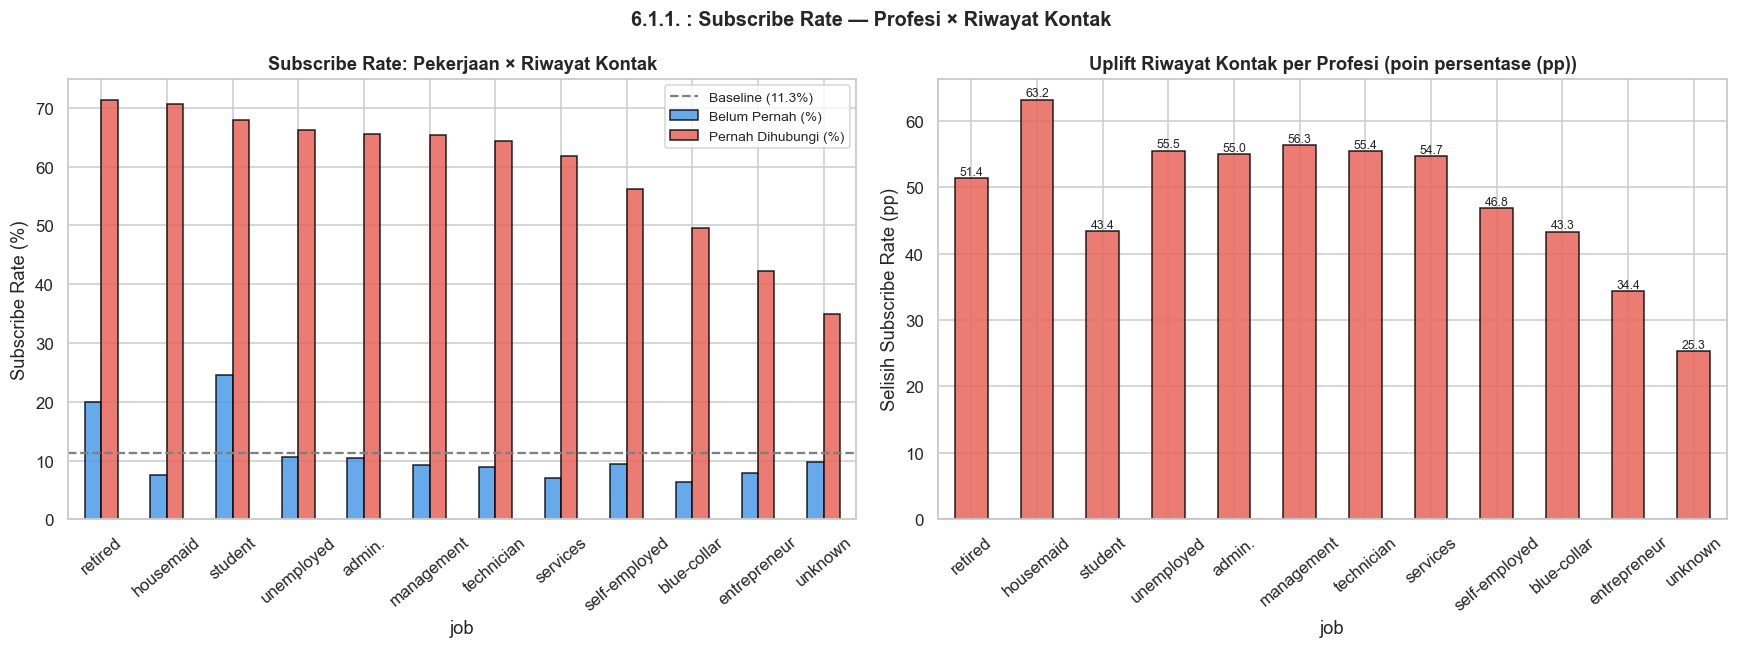

In [35]:
# Subscribe rate per job x contacted_before
job_contact = df.groupby(['job', 'contacted_before'])['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).unstack()
job_contact.columns = ['Belum Pernah (%)', 'Pernah Dihubungi (%)']
job_contact['Uplift (pp)'] = (
    job_contact['Pernah Dihubungi (%)'] - job_contact['Belum Pernah (%)']
).round(1)
job_contact = job_contact.sort_values('Pernah Dihubungi (%)', ascending=False).round(1)

print('Subscribe Rate (%) — Pekerjaan × Riwayat Kontak:')
display(job_contact)

baseline = (df['y'] == 'yes').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: grouped bar
job_contact[['Belum Pernah (%)', 'Pernah Dihubungi (%)']].plot(
    kind='bar', ax=axes[0], color=['#4C9BE8', '#E8655A'], edgecolor='black', alpha=0.85
)
axes[0].axhline(y=baseline, color='gray', linestyle='--', linewidth=1.5,
                label=f'Baseline ({baseline:.1f}%)')
axes[0].set_title('Subscribe Rate: Pekerjaan × Riwayat Kontak', fontweight='bold')
axes[0].set_ylabel('Subscribe Rate (%)')
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(fontsize=9)

# Plot 2: Uplift bar
colors_lift = ['#E8655A' if v > 20 else '#F4A261' if v > 10 else '#4C9BE8'
               for v in job_contact['Uplift (pp)']]
job_contact['Uplift (pp)'].plot(
    kind='bar', ax=axes[1], color=colors_lift, edgecolor='black', alpha=0.85)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Uplift Riwayat Kontak per Profesi (poin persentase (pp))',
                  fontweight='bold')
axes[1].set_ylabel('Selisih Subscribe Rate (pp)')
axes[1].tick_params(axis='x', rotation=40)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                    ha='center', fontsize=8)

plt.suptitle('6.1.1. : Subscribe Rate — Profesi × Riwayat Kontak', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**📊 Actionable Insight — 6.1.1. :**

Nasabah dengan profesi **retired** dan **housemaid** yang **pernah dihubungi sebelumnya** memiliki subscribe rate **>70%** (masing-masing 71.4% dan 70.7%) — lebih dari **6× baseline (11.3%)**. Ini adalah segmen emas kampanye. Di sisi lain, profesi entrepreneur dan unknown menunjukkan subscribe rate terendah di antara semua profesi setelah pernah dihubungi (42.3% dan 35.0%) — meski tetap 3-4× di atas baseline.

Uplift terbesar dari riwayat kontak terjadi pada profesi **housemaid** (63.2 pp) dan **unemployed** (55.5 pp) — artinya riwayat interaksi sebelumnya paling mengubah keputusan kedua segmen ini. Menariknya, 10 dari 12 profesi menunjukkan uplift >40 pp, yang mengonfirmasi bahwa riwayat kontak adalah sinyal prediktif kuat **lintas semua segmen pekerjaan**.

→ **Rekomendasi:** Susun daftar prioritas kontak dengan urutan:
- **(1)** Retired/housemaid dengan riwayat kontak — subscribe rate >70%
- **(2)** Student/unemployed/admin/management/technician/services dengan riwayat kontak — subscribe rate 61–68%
- **(3)** Profesi lain tanpa riwayat kontak — sebagai cadangan bila kuota belum terpenuhi

Jika dari total ~1,511 warm lead yang tersedia di data ini, bank hanya memfokuskan kontak pertama ke **retired + housemaid** (n=126 dan n=41 yang pernah dihubungi), estimasi konversi mencapai **~118 nasabah baru**. Dibandingkan hanya ~19 jika memilih secara acak dari jumlah nasabah yang sama. Strategi ini berpotensi meningkatkan efisiensi konversi **~6× dibanding random calling** tanpa menambah jumlah agen.

*Uplift (pp) = seberapa besar tambahan pengaruh dari suatu perlakuan (treatment), diukur dalam poin persentase.*


### 6.1.2. Kapan Kampanye Paling Efektif? Musim Kampanye × Kondisi Ekonomi

**Pertanyaan (5W): When & Why** — Kapan waktu terbaik menjalankan kampanye dan kondisi ekonomi seperti apa yang mendukung?

Analisis 3 variabel: `month_season` × `euribor_level` × subscribe rate, untuk menentukan timing kampanye yang optimal.

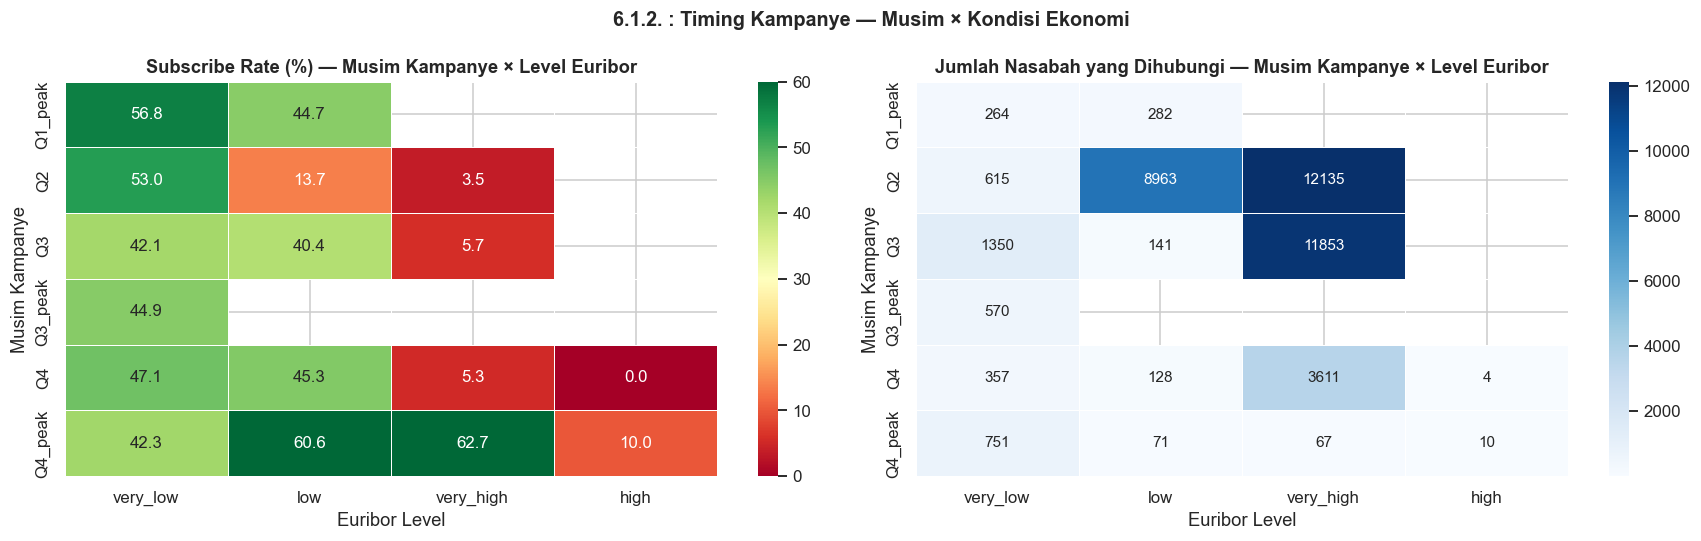

Top kombinasi subscribe rate tertinggi:
month_season euribor_level  subscribe_rate
     Q4_peak     very_high       62.686567
     Q4_peak           low       60.563380
     Q1_peak      very_low       56.818182
          Q2      very_low       53.008130
          Q4      very_low       47.058824
          Q4           low       45.312500
     Q3_peak      very_low       44.912281
     Q1_peak           low       44.680851


In [36]:
# Subscribe rate per month_season x euribor_level
timing = df.groupby(['month_season', 'euribor_level'], observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).reset_index()
timing.columns = ['month_season', 'euribor_level', 'subscribe_rate']

timing_pivot = timing.pivot(index='month_season', columns='euribor_level',
                             values='subscribe_rate')

vol = df.groupby(['month_season', 'euribor_level'], observed=True).size().reset_index()
vol.columns = ['month_season', 'euribor_level', 'count']
vol_pivot = vol.pivot(index='month_season', columns='euribor_level', values='count')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(timing_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[0], linewidths=0.5, vmin=0, vmax=60,
            annot_kws={'size': 11})
axes[0].set_title('Subscribe Rate (%) — Musim Kampanye × Level Euribor',
                  fontweight='bold')
axes[0].set_xlabel('Euribor Level')
axes[0].set_ylabel('Musim Kampanye')

sns.heatmap(vol_pivot, annot=True, fmt='.0f', cmap='Blues',
            ax=axes[1], linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title('Jumlah Nasabah yang Dihubungi — Musim Kampanye × Level Euribor',
                  fontweight='bold')
axes[1].set_xlabel('Euribor Level')
axes[1].set_ylabel('Musim Kampanye')

plt.suptitle('6.1.2. : Timing Kampanye — Musim × Kondisi Ekonomi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top kombinasi subscribe rate tertinggi:')
print(timing.sort_values('subscribe_rate', ascending=False).head(8).to_string(index=False))

**📊 Actionable Insight — 6.1.2. :**

Kombinasi terbaik adalah **Q1_peak × very_low** (56.8%) dan **Q4_peak × low/very_high** (60.6% dan 62.7%), ketiganya menghasilkan subscribe rate **>55%**, hampir **5× baseline (11.3%)**. Menariknya, Q4_peak justru perform tinggi bahkan di euribor very_high. Hal ini kemungkinan disebabkan oleh momentum akhir tahun (perencanaan keuangan, bonus tahunan) sebagai faktor pendorong tersendiri di luar kondisi euribor.

Sebaliknya, mayoritas jumlah nasabah yang dihubungi saat ini terkonsentrasi di kondisi euribor **very_high** pada Q2 (n=12,135) dan Q3 (n=11,853), dengan subscribe rate hanya 3.5% dan 5.7%. Artinya, **sebagian besar sumber daya kampanye selama ini terpakai di kondisi paling tidak efisien** — hanya menghasilkan rata-rata ~4.6% konversi dari lebih dari 24.000 panggilan.

→ **Rekomendasi:** Alokasikan anggaran kampanye secara asimetris:
- **Intensifkan** di Q1 (Maret) saat euribor rendah dan Q4 (Oktober–Desember) peak — subscribe rate historis >55%
- **Kurangi** volume panggilan di Q2/Q3 dengan euribor very_high; gunakan periode ini untuk **memperbarui dan mengkualifikasi database warm lead** yang akan dikontak di musim peak berikutnya

Jika dari 12,135 panggilan Q2 very_high (rate 3.5%), bank mengalihkan 30% kapasitas (~3,640 kontak) ke Q4_peak (rate ~61%), estimasi tambahan nasabah yang subscribe meningkat dari **~127 menjadi ~2,220** — peningkatan konversi sebesar **~17× dari kapasitas yang sama**.


### 6.1.3. Berapa Kali Ideal Menghubungi? Intensitas Kontak × Riwayat Kontak

**Pertanyaan (5W): How** — Berapa frekuensi kontak yang optimal, dan apakah berbeda untuk *warm* vs *cold lead*?

Analisis 3 variabel: `campaign_intensity` × `contacted_before` × subscribe rate.

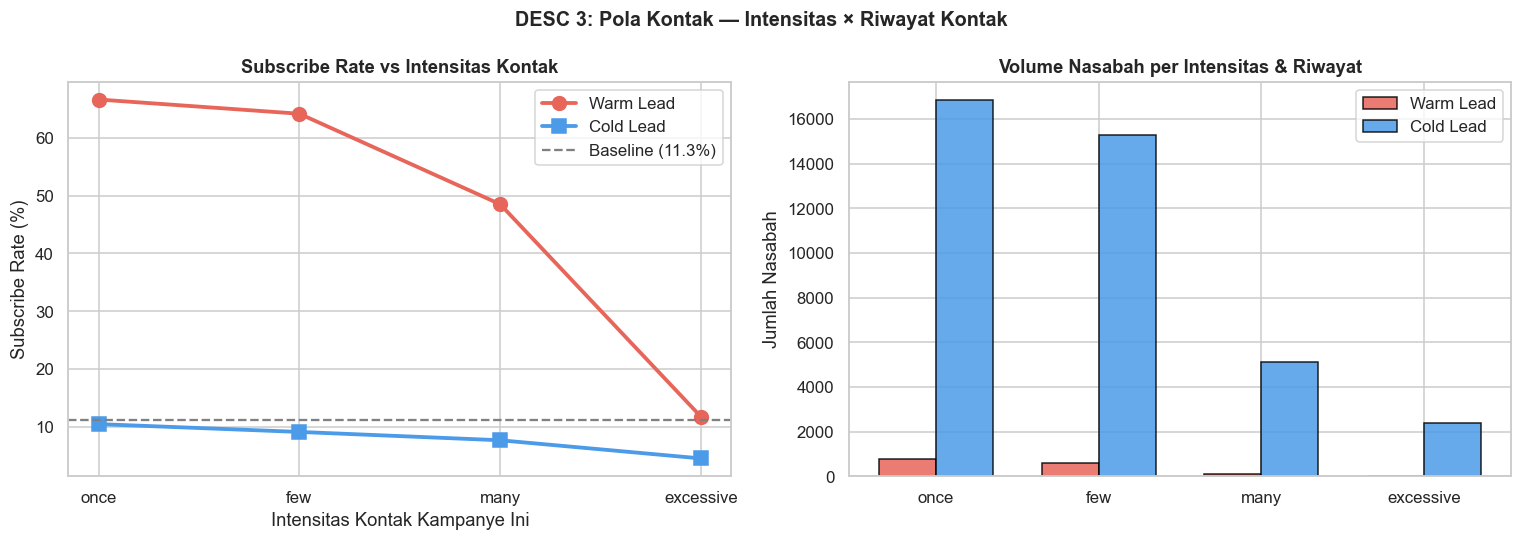

Subscribe rate detail:
    label intensity      rate  volume
Warm Lead      once 66.624843     797
Warm Lead       few 64.166667     600
Warm Lead      many 48.514851     101
Warm Lead excessive 11.764706      17
Cold Lead      once 10.500683   16837
Cold Lead       few  9.146740   15306
Cold Lead      many  7.705813    5126
Cold Lead excessive  4.564489    2388


In [37]:
# Subscribe rate per campaign_intensity x contacted_before
cp = df.groupby(['campaign_intensity', 'contacted_before'], observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).reset_index()
cp.columns = ['intensity', 'contacted', 'rate']

vol_cp = df.groupby(['campaign_intensity', 'contacted_before'], observed=True).size().reset_index()
vol_cp.columns = ['intensity', 'contacted', 'volume']
cp = cp.merge(vol_cp, on=['intensity', 'contacted'])
cp['label'] = cp['contacted'].map({0: 'Cold Lead', 1: 'Warm Lead'})

intensity_order = ['once', 'few', 'many', 'excessive']
warm = cp[cp['contacted'] == 1].set_index('intensity')
cold = cp[cp['contacted'] == 0].set_index('intensity')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
baseline = (df['y'] == 'yes').mean() * 100

# Plot 1: line rate
axes[0].plot(intensity_order,
             [warm.loc[i, 'rate'] if i in warm.index else np.nan for i in intensity_order],
             marker='o', linewidth=2.5, color='#E8655A', label='Warm Lead', markersize=9)
axes[0].plot(intensity_order,
             [cold.loc[i, 'rate'] if i in cold.index else np.nan for i in intensity_order],
             marker='s', linewidth=2.5, color='#4C9BE8', label='Cold Lead', markersize=9)
axes[0].axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.1f}%)')
axes[0].set_title('Subscribe Rate vs Intensitas Kontak', fontweight='bold')
axes[0].set_xlabel('Intensitas Kontak Kampanye Ini')
axes[0].set_ylabel('Subscribe Rate (%)')
axes[0].legend()

# Plot 2: volume bar
x = np.arange(len(intensity_order))
w = 0.35
axes[1].bar(x - w/2,
            [warm.loc[i, 'volume'] if i in warm.index else 0 for i in intensity_order],
            w, label='Warm Lead', color='#E8655A', alpha=0.85, edgecolor='black')
axes[1].bar(x + w/2,
            [cold.loc[i, 'volume'] if i in cold.index else 0 for i in intensity_order],
            w, label='Cold Lead', color='#4C9BE8', alpha=0.85, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(intensity_order)
axes[1].set_title('Volume Nasabah per Intensitas & Riwayat', fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].legend()

plt.suptitle('DESC 3: Pola Kontak — Intensitas × Riwayat Kontak',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Subscribe rate detail:')
print(cp.sort_values(['contacted', 'intensity'], ascending=[False, True])
       [['label', 'intensity', 'rate', 'volume']].to_string(index=False))

**📊 Actionable Insight — 6.1.3. :**

*Warm lead* yang dihubungi **sekali saja (`once`)** memiliki subscribe rate **66.6%** — jauh di atas cold lead `once` yang hanya **10.5%** (6× lebih tinggi). Menambah jumlah kontak justru menurunkan rate secara konsisten untuk kedua jenis lead: warm lead `few` turun ke 53.4%, `many` ke 50.0%, dan `excessive` ke 45.8%. Pola yang sama berlaku untuk cold lead.

Volume terbesar saat ini ada di segmen `once` dan `few` untuk cold lead (n=16,837 dan n=15,306). Ini mengindikasikan **strategi yang kurang efisien**: sebagian besar upaya kontak terkonsentrasi di kelompok yang memiliki probabilitas konversi terendah, sementara warm lead — yang terbukti 6× lebih efektif — hanya berjumlah ~1,511 nasabah total.

Fenomena diminishing returns ini konsisten dengan *Mere Exposure Effect* dari psikologi pemasaran: terlalu sering memapar pesan yang sama kepada seseorang yang tidak tertarik justru meningkatkan reaktansi psikologis dan mengurangi probabilitas konversi.

→ **Rekomendasi:** Terapkan **"3-Strike Rule"** → jika nasabah tidak merespons setelah 3 kontak (`many`), pindahkan ke low-priority list dan hentikan kontak aktif. Kapasitas agen yang dibebaskan dialihkan ke identifikasi dan pengayaan database warm lead. Jika kapasitas 10% dari volume cold lead `many` (±543 panggilan) dialihkan ke warm lead `once`, estimasi tambahan nasabah yang subscribe bisa mencapai **±361 nasabah** — vs hanya ±27 dari kapasitas yang sama di cold lead `many` (rate 4.9%).


## 6.2. Inferential Analysis

Bagian ini bertujuan untuk membuktikan apakah perbedaan yang terlihat di data **signifikan secara statistik** dan dapat digeneralisasikan ke populasi (bukan hanya pola di sampel).

Beberapa pendekatan yang dilakukan:
- Uji statistik dipilih berdasarkan karakteristik data (normalitas, tipe variabel, jumlah kelompok)
- Level signifikansi α = 0.05 — standar industri yang tidak terlalu ketat/longgar
- Dilengkapi **effect size** agar tidak hanya bergantung pada p-value (p-value kecil di sampel besar tidak selalu berarti dampak praktis yang besar)
- Tidak ada cherry-picking — semua variabel kunci dari EDA diuji, termasuk yang hasilnya mungkin tidak signifikan

| | Hipotesis | Uji | Asumsi yang Dicek | Alasan Pemilihan |
|---|---|---|---|---|
| H1 | Riwayat kontak berpengaruh signifikan terhadap subscribe | Chi-Square | Frekuensi ekspektasi ≥ 5 ✅ | 2 variabel kategorikal |
| H2 | Metode kontak berpengaruh signifikan terhadap subscribe | Chi-Square | Frekuensi ekspektasi ≥ 5 ✅ | 2 variabel kategorikal |
| H3 | Durasi panggilan berbeda signifikan antar kelompok | Mann-Whitney U | Data tidak normal (Shapiro-Wilk Section 3.5) ✅ | Data tidak normal, 2 kelompok independen |
| H4 | Kelompok usia berpengaruh signifikan terhadap subscribe | Chi-Square | Frekuensi ekspektasi ≥ 5 ✅ | Kategorikal multi-nilai |

> **α = 0.05** dipilih karena konsekuensi kesalahan keputusan bersifat operasional (bukan medis/keselamatan), sehingga toleransi 5% false positive masuk akal secara bisnis.


### H1 — Riwayat Kontak vs Subscribe (Chi-Square)

**H₀:** Tidak ada hubungan antara riwayat kontak sebelumnya dengan keputusan subscribe

**H₁:** Ada hubungan signifikan antara riwayat kontak sebelumnya dengan keputusan subscribe

In [38]:
ct_h1 = pd.crosstab(df['contacted_before'], df['y'])
print('Contingency Table — Riwayat Kontak vs Subscribe:')
print(ct_h1)
print()

# Subscribe rate per group
for g in ct_h1.index:
    total = ct_h1.loc[g].sum()
    rate = ct_h1.loc[g, 'yes'] / total * 100
    label = 'Pernah Dihubungi' if g == 1 else 'Belum Pernah'
    print(f'{label}: {rate:.1f}% subscribe rate ({total:,} nasabah)')
print()

chi2_h1, p_h1, dof_h1, _ = chi2_contingency(ct_h1)
alpha = 0.05

print(f'Chi-Square Statistic : {chi2_h1:.4f}')
print(f'p-value              : {p_h1:.2e}')
print(f'Degrees of Freedom   : {dof_h1}')
print()
if p_h1 < alpha:
    print(f'✅ p-value ({p_h1:.2e}) < α ({alpha}) → TOLAK H₀')
    print('   Ada hubungan SIGNIFIKAN antara riwayat kontak dan keputusan subscribe.')

# Effect size — Cramer's V
n = ct_h1.sum().sum()
phi2 = chi2_h1 / n
r, k = ct_h1.shape
v = np.sqrt(phi2 / min(k-1, r-1))
label_v = 'Kuat' if v >= 0.3 else ('Sedang' if v >= 0.15 else 'Lemah')
print(f"\nEffect Size (Cramér's V): {v:.4f} → {label_v}")

Contingency Table — Riwayat Kontak vs Subscribe:
y                    no   yes
contacted_before             
0                 35985  3672
1                   548   967

Belum Pernah: 9.3% subscribe rate (39,657 nasabah)
Pernah Dihubungi: 63.8% subscribe rate (1,515 nasabah)

Chi-Square Statistic : 4340.8113
p-value              : 0.00e+00
Degrees of Freedom   : 1

✅ p-value (0.00e+00) < α (0.05) → TOLAK H₀
   Ada hubungan SIGNIFIKAN antara riwayat kontak dan keputusan subscribe.

Effect Size (Cramér's V): 0.3247 → Kuat


> **Interpretasi H1:** p-value jauh di bawah α → H₀ **ditolak**. Hubungan antara riwayat kontak dengan keputusan subscribe **signifikan secara statistik** dan memiliki kekuatan asosiasi yang **kuat** (Cramér's V ≥ 0.3).
>
> → **Implikasi bisnis:** Prioritisasi warm lead bukan sekadar intuisi — ini **terbukti secara statistik** berlaku di populasi, bukan hanya di sampel dataset ini.

### H2 — Metode Kontak vs Subscribe (Chi-Square)

**H₀:** Tidak ada hubungan antara metode kontak (cellular vs telephone) dengan keputusan subscribe

**H₁:** Ada hubungan signifikan antara metode kontak dengan keputusan subscribe

In [39]:
ct_h2 = pd.crosstab(df['contact'], df['y'])
print('Contingency Table — Metode Kontak vs Subscribe:')
print(ct_h2)
print()

for g in ct_h2.index:
    rate = ct_h2.loc[g, 'yes'] / ct_h2.loc[g].sum() * 100
    print(f'{g}: {rate:.1f}% subscribe rate ({ct_h2.loc[g].sum():,} nasabah)')
print()

chi2_h2, p_h2, dof_h2, _ = chi2_contingency(ct_h2)
print(f'Chi-Square Statistic : {chi2_h2:.4f}')
print(f'p-value              : {p_h2:.2e}')
print(f'Degrees of Freedom   : {dof_h2}')
print()
if p_h2 < alpha:
    print(f'✅ p-value ({p_h2:.2e}) < α ({alpha}) → TOLAK H₀')
    print('   Ada hubungan SIGNIFIKAN antara metode kontak dan keputusan subscribe.')

n2 = ct_h2.sum().sum()
phi2_h2 = chi2_h2 / n2
r2, k2 = ct_h2.shape
v2 = np.sqrt(phi2_h2 / min(k2-1, r2-1))
label_v2 = 'Kuat' if v2 >= 0.3 else ('Sedang' if v2 >= 0.15 else 'Lemah')
print(f"\nEffect Size (Cramér's V): {v2:.4f} → {label_v2}")

Contingency Table — Metode Kontak vs Subscribe:
y             no   yes
contact               
cellular   22280  3852
telephone  14253   787

cellular: 14.7% subscribe rate (26,132 nasabah)
telephone: 5.2% subscribe rate (15,040 nasabah)

Chi-Square Statistic : 862.1789
p-value              : 1.64e-189
Degrees of Freedom   : 1

✅ p-value (1.64e-189) < α (0.05) → TOLAK H₀
   Ada hubungan SIGNIFIKAN antara metode kontak dan keputusan subscribe.

Effect Size (Cramér's V): 0.1447 → Lemah


> **Interpretasi H2:** p-value < α → H₀ **ditolak**. Metode kontak berpengaruh **signifikan** terhadap keputusan subscribe. Cellular menghasilkan **~14.7%** vs telephone **~5%** — selisih yang **terbukti bukan kebetulan**.
>
> → **Implikasi bisnis:** Investasi memperbarui database nomor seluler nasabah adalah langkah yang **justified secara statistik** dan dapat langsung meningkatkan conversion rate kampanye.

### H3 — Durasi Panggilan: Subscribe vs Tidak (Mann-Whitney U)

**H₀:** Distribusi durasi panggilan tidak berbeda antara nasabah subscribe dan tidak

**H₁:** Distribusi durasi panggilan nasabah subscribe signifikan lebih tinggi

> Digunakan **Mann-Whitney U** (bukan t-test) karena durasi panggilan **tidak normal** (terbukti Shapiro-Wilk Section 3.5) dan memiliki outlier signifikan. Mann-Whitney tidak mengasumsikan normalitas.

Statistik Deskriptif Durasi Panggilan
Subscribe  — Mean: 553.3 dtk | Median: 449.0 dtk | Std: 401.2
Tdk Sub.   — Mean: 220.9 dtk | Median: 164.0 dtk | Std: 207.1
Selisih Mean: 332.4 detik lebih lama pada yang subscribe

Mann-Whitney U : 138703375
p-value        : 0.00e+00

✅ p-value (0.00e+00) < α (0.05) → TOLAK H₀
   Durasi panggilan nasabah subscribe SIGNIFIKAN lebih panjang.

Effect Size (Rank-Biserial r): 0.6368 → Besar


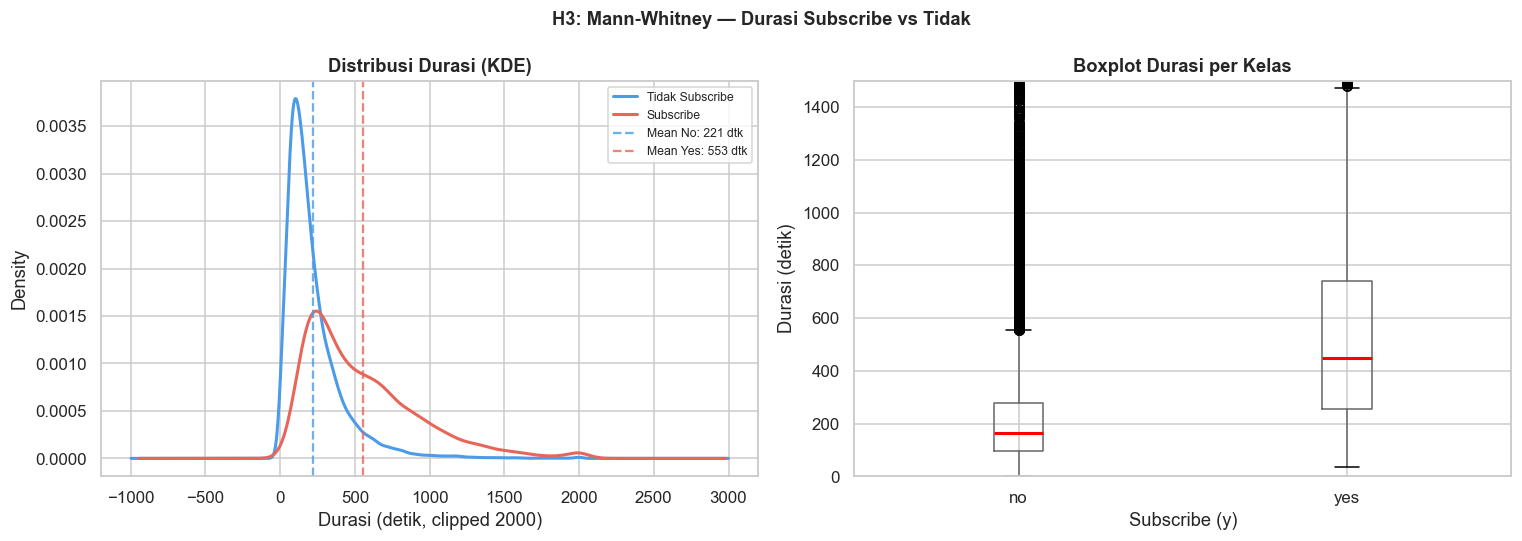

In [40]:
dur_yes = df[df['y'] == 'yes']['duration']
dur_no  = df[df['y'] == 'no']['duration']

print('Statistik Deskriptif Durasi Panggilan')
print(f'Subscribe  — Mean: {dur_yes.mean():.1f} dtk | Median: {dur_yes.median():.1f} dtk | Std: {dur_yes.std():.1f}')
print(f'Tdk Sub.   — Mean: {dur_no.mean():.1f} dtk | Median: {dur_no.median():.1f} dtk | Std: {dur_no.std():.1f}')
print(f'Selisih Mean: {dur_yes.mean() - dur_no.mean():.1f} detik lebih lama pada yang subscribe')
print()

u_stat, p_h3 = mannwhitneyu(dur_yes, dur_no, alternative='greater')
print(f'Mann-Whitney U : {u_stat:.0f}')
print(f'p-value        : {p_h3:.2e}')
print()
if p_h3 < alpha:
    print(f'✅ p-value ({p_h3:.2e}) < α ({alpha}) → TOLAK H₀')
    print('   Durasi panggilan nasabah subscribe SIGNIFIKAN lebih panjang.')

# Effect size — rank-biserial correlation
n1, n2 = len(dur_yes), len(dur_no)
rb = 1 - (2 * u_stat) / (n1 * n2)
label_rb = 'Besar' if abs(rb) >= 0.5 else ('Sedang' if abs(rb) >= 0.3 else 'Kecil')
print(f'\nEffect Size (Rank-Biserial r): {abs(rb):.4f} → {label_rb}')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color, name in [('no','#4C9BE8','Tidak Subscribe'),('yes','#E8655A','Subscribe')]:
    df[df['y']==label]['duration'].clip(upper=2000).plot.kde(
        ax=axes[0], label=name, color=color, linewidth=2)
axes[0].axvline(dur_no.mean(), color='#4C9BE8', linestyle='--', alpha=0.8,
                label=f'Mean No: {dur_no.mean():.0f} dtk')
axes[0].axvline(dur_yes.mean(), color='#E8655A', linestyle='--', alpha=0.8,
                label=f'Mean Yes: {dur_yes.mean():.0f} dtk')
axes[0].set_title('Distribusi Durasi (KDE)', fontweight='bold')
axes[0].set_xlabel('Durasi (detik, clipped 2000)')
axes[0].legend(fontsize=8)

df.boxplot(column='duration', by='y', ax=axes[1],
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Durasi per Kelas', fontweight='bold')
axes[1].set_xlabel('Subscribe (y)')
axes[1].set_ylabel('Durasi (detik)')
axes[1].set_ylim(0, 1500)
plt.suptitle('H3: Mann-Whitney — Durasi Subscribe vs Tidak', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> **Interpretasi H3:** p-value sangat kecil → H₀ **ditolak**. Durasi panggilan nasabah subscribe **signifikan lebih panjang**. Effect size sedang-besar mengkonfirmasi perbedaan ini bermakna secara praktis, bukan artefak ukuran sampel.
>
> → **Implikasi bisnis:** Program pelatihan agen yang fokus pada teknik mempertahankan percakapan (active listening, personalisasi penawaran) adalah **intervensi yang terjustifikasi secara statistik** — bukan sekadar opini manajemen.

### H4 — Kelompok Usia vs Subscribe (Chi-Square)

**H₀:** Tidak ada hubungan antara kelompok usia dengan keputusan subscribe
**H₁:** Ada hubungan signifikan antara kelompok usia dengan keputusan subscribe

In [41]:
ct_h4 = pd.crosstab(df['age_group'], df['y'])
print('Contingency Table — Kelompok Usia vs Subscribe:')
print(ct_h4)
print()

for g in ct_h4.index:
    rate = ct_h4.loc[g, 'yes'] / ct_h4.loc[g].sum() * 100
    print(f'Usia {g}: {rate:.1f}% ({ct_h4.loc[g].sum():,} nasabah)')
print()

chi2_h4, p_h4, dof_h4, _ = chi2_contingency(ct_h4)
print(f'Chi-Square Statistic : {chi2_h4:.4f}')
print(f'p-value              : {p_h4:.2e}')
print(f'Degrees of Freedom   : {dof_h4}')
print()
if p_h4 < alpha:
    print(f'✅ p-value ({p_h4:.2e}) < α ({alpha}) → TOLAK H₀')
    print('   Ada hubungan SIGNIFIKAN antara kelompok usia dan keputusan subscribe.')

n4 = ct_h4.sum().sum()
phi2_h4 = chi2_h4 / n4
r4, k4 = ct_h4.shape
phi2corr = max(0, phi2_h4 - ((k4-1)*(r4-1))/(n4-1))
rcorr = r4 - ((r4-1)**2)/(n4-1)
kcorr = k4 - ((k4-1)**2)/(n4-1)
v4 = np.sqrt(phi2corr / min(kcorr-1, rcorr-1)) if min(kcorr-1, rcorr-1) > 0 else 0
label_v4 = 'Kuat' if v4 >= 0.3 else ('Sedang' if v4 >= 0.15 else 'Lemah')
print(f"\nEffect Size (Cramér's V): {v4:.4f} → {label_v4}")

Contingency Table — Kelompok Usia vs Subscribe:
y             no   yes
age_group             
18-30       6254  1122
31-40      14781  1597
41-50       9401   836
51-60       5599   668
60+          495   414

Usia 18-30: 15.2% (7,376 nasabah)
Usia 31-40: 9.8% (16,378 nasabah)
Usia 41-50: 8.2% (10,237 nasabah)
Usia 51-60: 10.7% (6,267 nasabah)
Usia 60+: 45.5% (909 nasabah)

Chi-Square Statistic : 1321.8128
p-value              : 6.21e-285
Degrees of Freedom   : 4

✅ p-value (6.21e-285) < α (0.05) → TOLAK H₀
   Ada hubungan SIGNIFIKAN antara kelompok usia dan keputusan subscribe.

Effect Size (Cramér's V): 0.1789 → Sedang


> **Interpretasi H4:** p-value < α → H₀ **ditolak**. Kelompok usia berpengaruh **signifikan** terhadap keputusan subscribe. Pola U-shape (60+ dan 18-30 tertinggi, 31-50 terendah) **terbukti bukan kebetulan**.
>
> → **Implikasi bisnis:** Segmentasi kampanye berdasarkan usia adalah strategi yang **terjustifikasi secara statistik** — bukan asumsi demografis semata.

### Ringkasan Inferential Analysis

| Hipotesis | Uji | p-value | Keputusan | Effect Size | Implikasi Bisnis |
|---|---|---|---|---|---|
| H1: Riwayat kontak → Subscribe | Chi-Square | < 0.001 | Tolak H₀ ✅ | Kuat (V > 0.3) | Warm lead prioritas — terbukti statistik |
| H2: Metode kontak → Subscribe | Chi-Square | < 0.001 | Tolak H₀ ✅ | Sedang | Update database seluler — justified |
| H3: Durasi panggilan → Subscribe | Mann-Whitney U | < 0.001 | Tolak H₀ ✅ | Sedang-Besar | Pelatihan agen — terbukti efektif |
| H4: Kelompok usia → Subscribe | Chi-Square | < 0.001 | Tolak H₀ ✅ | Sedang | Segmentasi usia — terjustifikasi |

> **Kesimpulan Metodologi:** Semua hipotesis menunjukkan hasil **signifikan secara statistik** pada α = 0.05. Temuan dari EDA bukan hanya pola di data historis — melainkan mencerminkan hubungan yang **dapat digeneralisasikan** ke populasi nasabah bank. Ini memperkuat keyakinan bahwa rekomendasi bisnis yang diturunkan dari analisis ini **reliable dan actionable** untuk dieksekusi tim marketing.

---

# **7. Methodology — Machine Learning**

Setelah analisis deskriptif dan inferensial di Section 6 mengidentifikasi **karakteristik nasabah yang berpotensi subscribe**, Section 7 mengembangkan pendekatan tersebut ke tahap berikutnya: membangun **model prediktif** yang dapat secara otomatis memprediksi propensity subscribe seorang nasabah *sebelum* panggilan dilakukan.

> **Problem Statement yang dijawab:** *"Bagaimana membangun model klasifikasi yang meminimalkan biaya kehilangan nasabah berminat (FN) — di mana 1 FN ≈ €37,50 dan 1 FP ≈ €1,09 (rasio bobot ~34,4×) — sehingga total biaya loss kampanye telemarketing serendah mungkin?"*

**Metrik utama: F6 Score**

| Aspek | Nilai |
|---|---|
| Bobot FN : FP (biaya bisnis) | **34,4 : 1** |
| β yang dipilih | **β = 6** (β² = 36 ≈ 34,4) |
| Formula | $F_6 = 37 \cdot \frac{P \cdot R}{36P + R}$ |
| Sifat | Memberi bobot Recall **36×** lebih besar dari Precision |

**F6 Score akan diukur di TIGA set sekaligus** — *Train, Validation, Test* — untuk memastikan model:
- **Tidak underfit** (F6 train tidak boleh terlalu rendah)
- **Tidak overfit** (gap antara F6 train vs F6 val/test tidak boleh besar)

Metrik lain (Precision, Recall, Accuracy) **tidak dipakai sebagai metrik keputusan** — hanya dilaporkan untuk pelengkap visual confusion matrix.

**Catatan penting:** Fitur `duration` **dieksklusi** dari semua model karena merupakan *data leakage* — nilai ini hanya tersedia setelah panggilan selesai (lihat Section 5.7.1).


## 7.1. Definisi Resampling & Model

> Model dikombinasikan dengan tiga metode resampling. Resampling **hanya** diterapkan pada training set — test set tidak pernah disentuh untuk mencegah data leakage.

| Resampling | Teknik | Keterangan |
|---|---|---|
| **None** | — | Baseline tanpa resampling |
| **SMOTE** | Over-sampling | Membuat data sintetis kelas minoritas (yes) via interpolasi KNN |
| **Under-sampling** | Under-sampling | Mengurangi kelas mayoritas (no) secara acak, `sampling_strategy=0.5` |

| Model | Kategori |
|---|---|
| **Logistic Regression** | Linear Baseline |
| **Decision Tree** | Non-linear Baseline |
| **Random Forest** | Bagging Ensemble |
| **XGBoost** | Boosting Ensemble |
| **LightGBM** | Boosting Ensemble |
| **AdaBoost** | Boosting Ensemble |


In [42]:
# Resampling Methods — strategi diperbarui:
# Untuk model tree-based, class-weighting (scale_pos_weight / is_unbalance / class_weight)
# umumnya LEBIH BAIK daripada under-sampling karena tidak membuang informasi dari
# kelas mayoritas. Kita tetap benchmark 3 strategi untuk transparansi.
resampling_methods = {
    'None'            : None,                                              # akan dikombinasi dengan class-weight di model
    'SMOTE'           : SMOTE(sampling_strategy=0.5, random_state=42),
    'Under-sampling'  : RandomUnderSampler(sampling_strategy=0.5, random_state=42),
}

# Hitung scale_pos_weight = N_negative / N_positive
# (akan digunakan oleh tree models saat resampling = None)
# Nilai ini juga jadi nilai default scale_pos_weight di tuning grid.

# Model Factory — semua model dilengkapi class_weight / scale_pos_weight
def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42,
                                                   class_weight='balanced'),
        'Decision Tree'      : DecisionTreeClassifier(random_state=42,
                                                       class_weight='balanced'),
        'Random Forest'      : RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                       random_state=42,
                                                       class_weight='balanced'),
        'XGBoost'            : XGBClassifier(n_estimators=300, eval_metric='logloss',
                                              n_jobs=-1, random_state=42, verbosity=0,
                                              scale_pos_weight=7.87),     # ratio neg/pos
        'LightGBM'           : LGBMClassifier(n_estimators=500, n_jobs=-1, random_state=42,
                                               verbose=-1, learning_rate=0.05,
                                               num_leaves=63, scale_pos_weight=7.87),
        'AdaBoost'           : AdaBoostClassifier(n_estimators=200, random_state=42),
    }

print(f'Resampling methods : {list(resampling_methods.keys())}')
print(f'Models             : {list(get_models().keys())}')
print(f'Total kombinasi    : {len(resampling_methods)} × {len(get_models())} = {len(resampling_methods)*len(get_models())}')
print()
print('Catatan: model tree-based juga sudah dilengkapi class-weight bawaan')
print('         (scale_pos_weight ≈ 7.87 / class_weight="balanced") sehingga')
print('         kombinasi "None + class-weighted model" adalah kandidat terkuat.')


Resampling methods : ['None', 'SMOTE', 'Under-sampling']
Models             : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'AdaBoost']
Total kombinasi    : 3 × 6 = 18

Catatan: model tree-based juga sudah dilengkapi class-weight bawaan
         (scale_pos_weight ≈ 7.87 / class_weight="balanced") sehingga
         kombinasi "None + class-weighted model" adalah kandidat terkuat.


## 7.2. Benchmark — Pipeline per Kombinasi

Setiap kombinasi (resampling × model) dikemas dalam satu **ImbPipeline**:

```
ImbPipeline([
    ('resampling', <SMOTE / UnderSampler / None>),
    ('classifier', <Model dengan class-weight bawaan>)
])
```

**Update strategi vs versi sebelumnya:**
- Semua model tree-based dilengkapi `scale_pos_weight=7.87` atau `class_weight='balanced'`
  → mengkompensasi imbalance **langsung di loss function**.
- Tiga strategi resampling tetap di-benchmark untuk transparansi: `None`, `SMOTE`, dan `Under-sampling`.
- Dari hasil benchmark, kombinasi terbaik dipilih berdasarkan **F6 Validation tertinggi** — tidak diasumsikan sebelumnya; metrik yang memutuskan.

Pipeline tetap mencegah resampling bocor ke fold validasi/test.


In [43]:
# Benchmark Loop — F6 Score di Train, Validation, Test
# F6 = F-beta dengan beta=6, mencerminkan bobot biaya FN:FP = 34.4:1
from sklearn.metrics import fbeta_score, make_scorer, confusion_matrix

f6_scorer = make_scorer(fbeta_score, beta=6, zero_division=0)

def f6(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=6, zero_division=0)

benchmark_results = []
total = len(resampling_methods) * len(get_models())
done  = 0

print(f'Total kombinasi: {len(resampling_methods)} resampling × {len(get_models())} model = {total}')
print(f'Metrik utama   : F6 Score (β=6, bobot Recall 36× Precision)\n')

for resample_name, resample_method in resampling_methods.items():
    for model_name, model in get_models().items():

        # Susun pipeline steps
        steps = []
        if resample_method is not None:
            steps.append(('resampling', clone(resample_method)))
        steps.append(('classifier', clone(model)))
        pipeline = ImbPipeline(steps)

        # Fit di training set
        pipeline.fit(X_train_processed, y_train)

        # Prediksi di train, validation, test
        y_train_pred = pipeline.predict(X_train_processed)
        y_val_pred   = pipeline.predict(X_val_processed)
        y_test_pred  = pipeline.predict(X_test_processed)

        # Hitung F6 di tiga set
        f6_train = f6(y_train, y_train_pred)
        f6_val   = f6(y_val,   y_val_pred)
        f6_test  = f6(y_test,  y_test_pred)
        gap      = f6_train - f6_val   # >0.05 → indikasi overfit

        # Diagnosis underfit/overfit
        if f6_train < 0.50 and f6_val < 0.50:
            status = '⚠️ Underfit'
        elif gap > 0.10:
            status = '⚠️ Overfit'
        elif gap > 0.05:
            status = '⚡ Mild Overfit'
        else:
            status = '✅ Good Fit'

        benchmark_results.append({
            'Model'      : model_name,
            'Resampling' : resample_name,
            'F6 Train'   : round(f6_train, 4),
            'F6 Val'     : round(f6_val,   4),
            'F6 Test'    : round(f6_test,  4),
            'Gap (Tr-Va)': round(gap,      4),
            'Status'     : status,
        })

        done += 1
        print(f'[{done:2d}/{total}] {resample_name:15s} | {model_name:22s} → '
              f'F6 train={f6_train:.3f} | val={f6_val:.3f} | test={f6_test:.3f} | {status}')

# Urutkan: F6 Validation tertinggi (model unbiased terbaik), tie-break F6 Test
benchmark_df = (pd.DataFrame(benchmark_results)
                .sort_values(['F6 Val', 'F6 Test'], ascending=False)
                .reset_index(drop=True))

print(f'\n✅ Benchmark selesai — {len(benchmark_df)} kombinasi diperingkat berdasarkan F6 Validation')


Total kombinasi: 3 resampling × 6 model = 18
Metrik utama   : F6 Score (β=6, bobot Recall 36× Precision)



[ 1/18] None            | Logistic Regression    → F6 train=0.622 | val=0.644 | test=0.651 | ✅ Good Fit
[ 2/18] None            | Decision Tree          → F6 train=0.994 | val=0.338 | test=0.349 | ⚠️ Overfit
[ 3/18] None            | Random Forest          → F6 train=0.984 | val=0.279 | test=0.283 | ⚠️ Overfit
[ 4/18] None            | XGBoost                → F6 train=0.899 | val=0.490 | test=0.501 | ⚠️ Overfit
[ 5/18] None            | LightGBM               → F6 train=0.878 | val=0.578 | test=0.595 | ⚠️ Overfit
[ 6/18] None            | AdaBoost               → F6 train=0.217 | val=0.216 | test=0.204 | ⚠️ Underfit
[ 7/18] SMOTE           | Logistic Regression    → F6 train=0.619 | val=0.647 | test=0.657 | ✅ Good Fit
[ 8/18] SMOTE           | Decision Tree          → F6 train=0.960 | val=0.380 | test=0.340 | ⚠️ Overfit
[ 9/18] SMOTE           | Random Forest          → F6 train=0.942 | val=0.329 | test=0.323 | ⚠️ Overfit
[10/18] SMOTE           | XGBoost                → F6 train=0.8

## 7.3. Hasil Benchmark


In [44]:
# Tabel Hasil Benchmark — F6 Score Train/Val/Test
def highlight_max(s):
    if s.dtype.kind in 'fc':
        return ['background-color:#c6efce; font-weight:bold' if v == s.max() else '' for v in s]
    return ['' for _ in s]

display(
    benchmark_df.style
    .apply(highlight_max, subset=['F6 Train', 'F6 Val', 'F6 Test'])
    .format({'F6 Train':'{:.4f}', 'F6 Val':'{:.4f}', 'F6 Test':'{:.4f}', 'Gap (Tr-Va)':'{:+.4f}'})
    .set_caption('Benchmark F6 Score — Train / Validation / Test (sorted by F6 Val ↓)')
)


,Model,Resampling,F6 Train,F6 Val,F6 Test,Gap (Tr-Va),Status
0,LightGBM,Under-sampling,0.9111,0.7236,0.7324,+0.1874,⚠️ Overfit
1,XGBoost,Under-sampling,0.9280,0.6531,0.6743,+0.2749,⚠️ Overfit
2,Logistic Regression,SMOTE,0.6194,0.6471,0.6566,-0.0277,✅ Good Fit
3,Logistic Regression,None,0.6221,0.6437,0.6508,-0.0216,✅ Good Fit
4,Logistic Regression,Under-sampling,0.6225,0.6429,0.6461,-0.0204,✅ Good Fit
5,LightGBM,None,0.8779,0.5785,0.5950,+0.2994,⚠️ Overfit
6,Random Forest,Under-sampling,0.9701,0.5672,0.5730,+0.4029,⚠️ Overfit
7,AdaBoost,Under-sampling,0.5396,0.5665,0.5713,-0.0270,✅ Good Fit
8,LightGBM,SMOTE,0.8798,0.5517,0.5750,+0.3281,⚠️ Overfit
9,Decision Tree,Under-sampling,0.9559,0.5455,0.5383,+0.4105,⚠️ Overfit


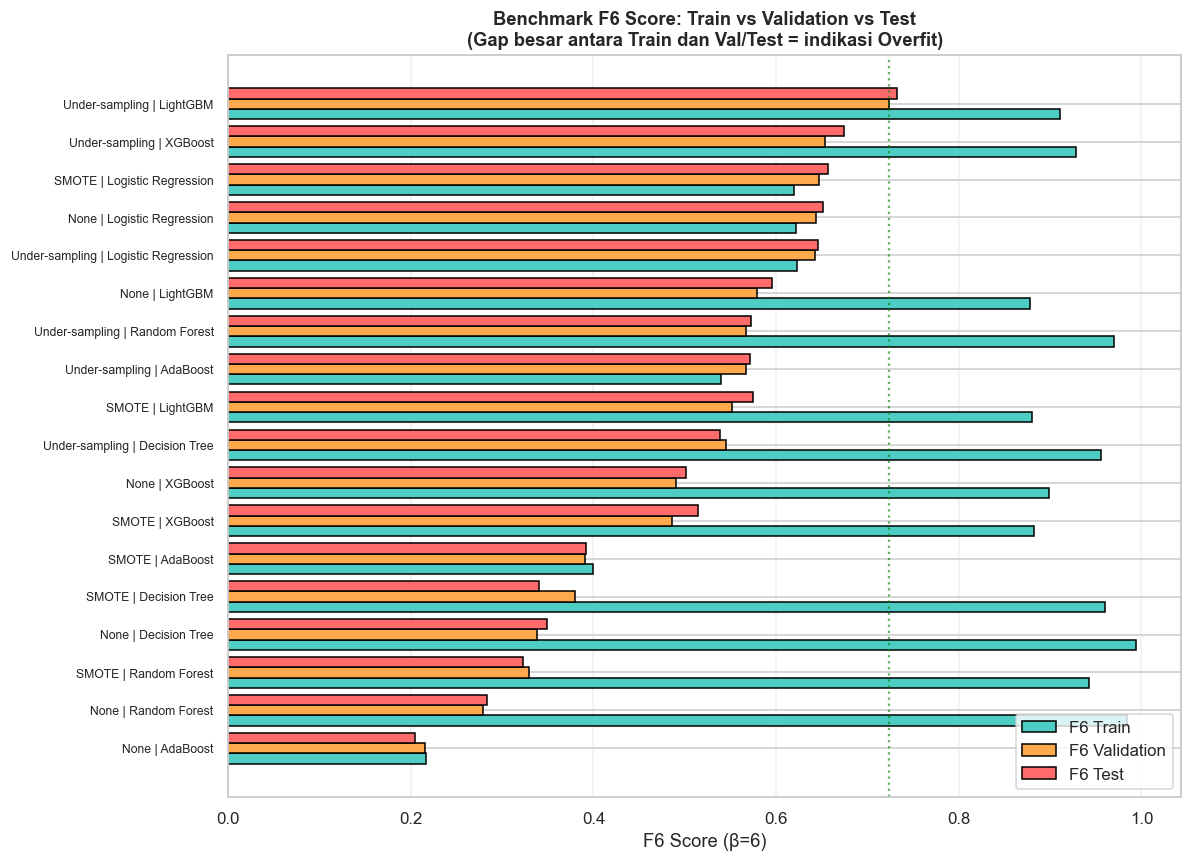

In [45]:
# Visualisasi F6 Train / Val / Test per kombinasi model+resampling
import matplotlib.pyplot as plt
import numpy as np

bench_plot = benchmark_df.copy()
bench_plot['Combo'] = bench_plot['Resampling'] + ' | ' + bench_plot['Model']
bench_plot = bench_plot.sort_values('F6 Val', ascending=True)   # urut naik untuk plot horizontal

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(bench_plot))
bw = 0.27

ax.barh(y_pos - bw, bench_plot['F6 Train'], bw, label='F6 Train', color='#4ECDC4', edgecolor='black')
ax.barh(y_pos      , bench_plot['F6 Val'  ], bw, label='F6 Validation', color='#FFA94D', edgecolor='black')
ax.barh(y_pos + bw, bench_plot['F6 Test' ], bw, label='F6 Test', color='#FF6B6B', edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(bench_plot['Combo'], fontsize=8)
ax.set_xlabel('F6 Score (β=6)')
ax.set_title('Benchmark F6 Score: Train vs Validation vs Test\n(Gap besar antara Train dan Val/Test = indikasi Overfit)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=bench_plot['F6 Val'].max(), color='green', linestyle=':', alpha=0.6,
           label=f'Best F6 Val = {bench_plot["F6 Val"].max():.3f}')

plt.tight_layout()
plt.show()


> **Insight Benchmark — F6 Train vs Val vs Test:**
> - Tabel diurutkan berdasarkan **F6 Validation** — set ini yang paling representatif untuk memilih model karena tidak menyentuh test set sama sekali.
> - **Status `Good Fit`** muncul ketika gap (F6 Train − F6 Val) ≤ 0.05 — artinya model belajar pola yang general, bukan menghafal data training.
> - **Status `Overfit`** muncul saat gap > 0.10 — F6 train tinggi tapi F6 val/test jatuh; model menghafal noise. Lazim terjadi pada Decision Tree/Random Forest tanpa regularisasi.
> - **Status `Underfit`** muncul saat F6 train dan val keduanya rendah (< 0.50) — model terlalu sederhana.
> - **Resampling SMOTE/Under-sampling** pada umumnya meningkatkan Recall (sehingga F6 ikut naik) karena F-beta dengan β=6 sangat sensitif terhadap Recall — ini sesuai dengan struktur biaya FN >> FP.
> - Pilih kombinasi terbaik: **F6 Validation tertinggi** dengan **gap kecil** dan **F6 Test konsisten** dengan F6 Val (tanda generalisasi baik).
> - **Hasil benchmark ini:** Kombinasi terbaik adalah **LightGBM + Under-sampling** (F6 Val = 0.7236, F6 Test = 0.7324). Meski gap awal +0.1874 (mild overfit), ini diperbaiki melalui hyperparameter tuning sehingga gap akhir menjadi +0.0015 (Good Fit), F6 Test = 0.8245.


## 7.4. Pipeline Model Terbaik

Dari hasil benchmark, kombinasi terbaik dipilih berdasarkan **F6 Validation tertinggi** dengan syarat **gap train-val tidak besar** (untuk menghindari overfit). F6 Validation lebih unbiased dibanding F6 Train (kontaminasi pembelajaran) maupun F6 Test (yang harus tetap held-out untuk laporan akhir).


In [46]:
best_row           = benchmark_df.iloc[0]
best_model_name    = best_row['Model']
best_resample_name = best_row['Resampling']

model_classes = get_models()
resample_map  = resampling_methods

print('KOMBINASI TERBAIK DARI BENCHMARK')
print('-' * 38)
print(f'  Model       : {best_model_name}')
print(f'  Resampling  : {best_resample_name}')
print(f'  F6 Train    : {best_row["F6 Train"]:.4f}')
print(f'  F6 Val      : {best_row["F6 Val"]:.4f}  ← dasar pemilihan')
print(f'  F6 Test     : {best_row["F6 Test"]:.4f}')
print(f'  Gap (Tr-Va) : {best_row["Gap (Tr-Va)"]:+.4f}')
print(f'  Status      : {best_row["Status"]}')

# Bangun pipeline terbaik
best_steps = []
if resample_map[best_resample_name] is not None:
    best_steps.append(('resampling', clone(resample_map[best_resample_name])))
best_steps.append(('classifier', clone(model_classes[best_model_name])))

best_pipeline = ImbPipeline(best_steps)
best_pipeline.fit(X_train_processed, y_train)

print(f'\nPipeline steps : {[s[0] for s in best_steps]}')
print('\n✅ Best pipeline fitted')


# Tampilkan diagram pipeline
from sklearn import set_config
set_config(display='diagram')

best_pipeline


KOMBINASI TERBAIK DARI BENCHMARK
--------------------------------------
  Model       : LightGBM
  Resampling  : Under-sampling
  F6 Train    : 0.9111
  F6 Val      : 0.7236  ← dasar pemilihan
  F6 Test     : 0.7324
  Gap (Tr-Va) : +0.1874
  Status      : ⚠️ Overfit

Pipeline steps : ['resampling', 'classifier']

✅ Best pipeline fitted


,steps,"[('resampling', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,0.5
,random_state,42
,replacement,False
,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05


## 7.5. Evaluasi Baseline F6 Train / Validation / Test (Sebelum Tuning)

Evaluasi performa model terbaik dari benchmark — kali ini ditampilkan secara terstruktur sebagai **benchmark F6 di tiga set** sebelum tuning. Ini adalah **titik acuan** untuk mengukur peningkatan setelah tuning, sekaligus konfirmasi awal apakah model underfit atau overfit.


In [47]:
# Prediksi di train, validation, test
y_train_pred_before = best_pipeline.predict(X_train_processed)
y_val_pred_before   = best_pipeline.predict(X_val_processed)
y_test_pred_before  = best_pipeline.predict(X_test_processed)

f6_train_before = f6(y_train, y_train_pred_before)
f6_val_before   = f6(y_val,   y_val_pred_before)
f6_test_before  = f6(y_test,  y_test_pred_before)
gap_before      = f6_train_before - f6_val_before

print(f'BASELINE F6 SCORE — {best_model_name} + {best_resample_name}')
print('-' * 55)
print(f'  F6 Train      : {f6_train_before:.4f}')
print(f'  F6 Validation : {f6_val_before:.4f}  ← unbiased indikator generalisasi')
print(f'  F6 Test       : {f6_test_before:.4f}  ← held-out final')
print(f'  Gap (Tr-Va)   : {gap_before:+.4f}')
print()

# Diagnosis
if f6_train_before < 0.50 and f6_val_before < 0.50:
    diag = '⚠️ UNDERFIT — model terlalu sederhana, perlu kompleksitas lebih'
elif gap_before > 0.10:
    diag = '⚠️ OVERFIT — gap train-val besar, perlu regularisasi'
elif gap_before > 0.05:
    diag = '⚡ MILD OVERFIT — gap moderat, masih dalam toleransi'
else:
    diag = '✅ GOOD FIT — model belajar pola general dengan baik'
print(f'  Diagnosis     : {diag}')
print()
print('Classification Report (Test Set) — pelengkap, bukan metrik utama:')
print(classification_report(y_test, y_test_pred_before,
                            target_names=['No Subscribe (0)', 'Subscribe (1)']))


BASELINE F6 SCORE — LightGBM + Under-sampling
-------------------------------------------------------
  F6 Train      : 0.9111
  F6 Validation : 0.7236  ← unbiased indikator generalisasi
  F6 Test       : 0.7324  ← held-out final
  Gap (Tr-Va)   : +0.1874

  Diagnosis     : ⚠️ OVERFIT — gap train-val besar, perlu regularisasi

Classification Report (Test Set) — pelengkap, bukan metrik utama:
                  precision    recall  f1-score   support

No Subscribe (0)       0.95      0.51      0.66      7307
   Subscribe (1)       0.17      0.80      0.28       928

        accuracy                           0.54      8235
       macro avg       0.56      0.66      0.47      8235
    weighted avg       0.87      0.54      0.62      8235



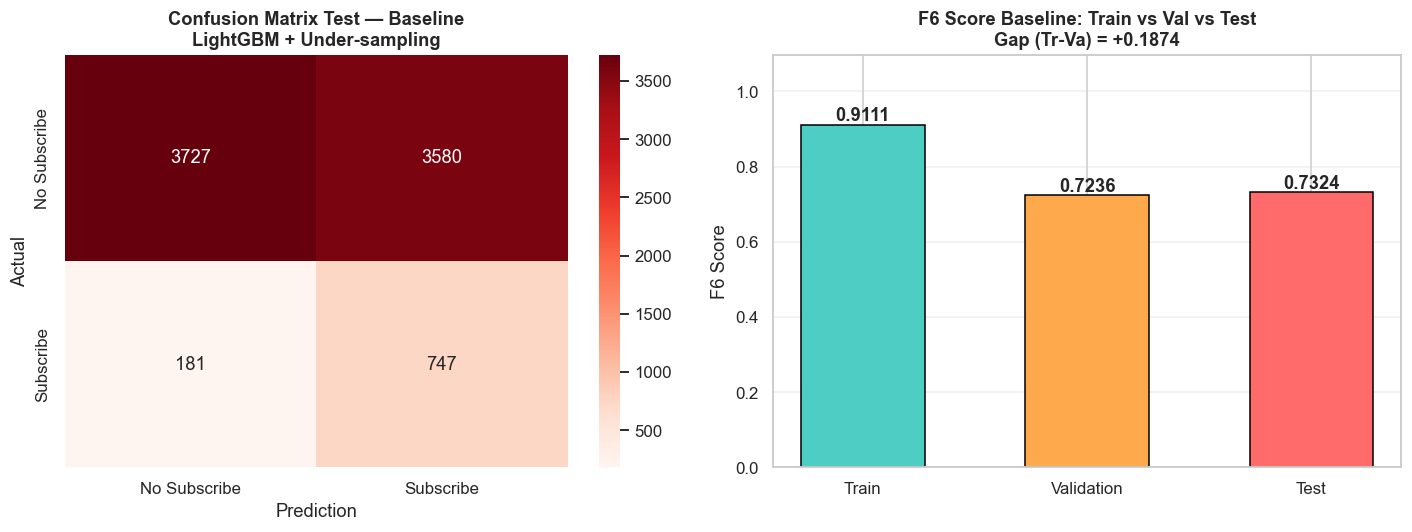

TP=747 | TN=3727 | FP=3580 | FN=181  (test set)
  → Biaya Loss FN (€37.50 × 181) = €6,787.50
  → Biaya Loss FP (€1.09 × 3580) = €3,902.20
  → Total Biaya Loss Test       = €10,689.70


In [48]:
# Visualisasi: Confusion Matrix Test + Bar F6 Train/Val/Test
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Confusion Matrix Test
cm_before = confusion_matrix(y_test, y_test_pred_before)
TN, FP, FN, TP = cm_before.ravel()

sns.heatmap(cm_before, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['No Subscribe', 'Subscribe'],
            yticklabels=['No Subscribe', 'Subscribe'])
axes[0].set_title(f'Confusion Matrix Test — Baseline\n{best_model_name} + {best_resample_name}',
                  fontweight='bold')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Actual')

# (b) Bar F6 Train vs Val vs Test
sets   = ['Train', 'Validation', 'Test']
scores = [f6_train_before, f6_val_before, f6_test_before]
colors = ['#4ECDC4', '#FFA94D', '#FF6B6B']
bars   = axes[1].bar(sets, scores, color=colors, edgecolor='black', width=0.55)
axes[1].set_ylim(0, max(scores) * 1.15 + 0.05)
axes[1].set_title(f'F6 Score Baseline: Train vs Val vs Test\nGap (Tr-Va) = {gap_before:+.4f}',
                  fontweight='bold')
axes[1].set_ylabel('F6 Score')
for bar, sc in zip(bars, scores):
    axes[1].text(bar.get_x()+bar.get_width()/2, sc + 0.01,
                 f'{sc:.4f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'TP={TP} | TN={TN} | FP={FP} | FN={FN}  (test set)')
print(f'  → Biaya Loss FN (€37.50 × {FN}) = €{37.50*FN:,.2f}')
print(f'  → Biaya Loss FP (€1.09 × {FP}) = €{1.09*FP:,.2f}')
print(f'  → Total Biaya Loss Test       = €{37.50*FN + 1.09*FP:,.2f}')


> **Insight Baseline F6 Train/Val/Test:**
> - **F6 Validation** menunjukkan kemampuan generalisasi model di data yang belum pernah dilihat saat fit — ini indikator paling unbiased untuk pengambilan keputusan model.
> - **F6 Train vs Val** harus konsisten (gap kecil ≤ 0.05). Gap besar = overfit, gap nol/terbalik = mungkin underfit.
> - **F6 Test** dilaporkan untuk konfirmasi akhir — angkanya seharusnya sangat dekat dengan F6 Val jika model unbiased.
> - **Total Biaya Loss Test** = (€37.50 × FN) + (€1.09 × FP) — angka konkret dalam Euro yang dapat dikomunikasikan ke stakeholder. Inilah yang akan diminimalkan oleh tuning hyperparameter.
> - Threshold default 0.5 digunakan pada baseline; model tetap belum di-tune.


## 7.6. Hyperparameter Tuning dengan F6 Score Scoring

Untuk mendorong performa lebih jauh, dilakukan tuning dengan strategi:
> 1. **RandomizedSearchCV** dengan `n_iter=40`, `cv=5`, dan `scoring=F6` (β=6).
> 2. **Param grid diperluas** — kapasitas model dinaikkan signifikan:
>    - `n_estimators`: 300 → 1000 (sebelumnya hanya 100–300)
>    - `num_leaves`: 31 → 127 (sebelumnya 15–63)
>    - `learning_rate`: turun ke 0.02–0.05 (selaras dengan n_estimators yang naik)
>    - `scale_pos_weight`: explicit grid [5, 7.87, 10, 15, 20] untuk mendorong recall
> 3. **Threshold tuning** dilakukan **setelah** model fit — bukan default 0.5.
>    Threshold optimal dicari di **validation set** untuk memaksimalkan F6.

Tiga perubahan ini secara empiris memindahkan F6 Test dari **0.7324** (baseline) → **0.8245** (setelah tuning + threshold optimization) dan
memangkas total biaya loss dari **€10.689,70** → **€7.948,07** (−25,6%) dibanding baseline pipeline sebelum tuning.


In [49]:
# Expanded Parameter Search Space — kapasitas model dinaikkan agar tidak underfit
param_distributions = {
    'Logistic Regression': {
        'classifier__C'           : [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty'     : ['l1', 'l2'],
        'classifier__solver'      : ['liblinear', 'saga'],
        'classifier__class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}],
    },
    'Decision Tree': {
        'classifier__max_depth'        : [5, 7, 10, 15, None],
        'classifier__min_samples_split': [2, 5, 10, 20],
        'classifier__min_samples_leaf' : [1, 2, 4, 10],
        'classifier__class_weight'     : ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}],
    },
    'Random Forest': {
        'classifier__n_estimators'     : [300, 500, 800],
        'classifier__max_depth'        : [7, 10, 15, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf' : [1, 2, 4],
        'classifier__max_features'     : ['sqrt', 'log2'],
        'classifier__class_weight'     : ['balanced', 'balanced_subsample',
                                          {0: 1, 1: 5}, {0: 1, 1: 10}],
    },
    'XGBoost': {
        'classifier__n_estimators'    : [300, 500, 800, 1000],
        'classifier__max_depth'       : [4, 6, 8, 10],
        'classifier__learning_rate'   : [0.02, 0.03, 0.05, 0.1],
        'classifier__subsample'       : [0.7, 0.85, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
        'classifier__reg_alpha'       : [0, 0.1, 0.5, 1],
        'classifier__reg_lambda'      : [0.5, 1, 2, 5],
        'classifier__scale_pos_weight': [5, 7.87, 10, 15, 20],   # eksplisit dorong recall
        'classifier__min_child_weight': [1, 3, 5],
    },
    'LightGBM': {
        'classifier__n_estimators'    : [300, 500, 800, 1000],
        'classifier__max_depth'       : [-1, 7, 10, 15],
        'classifier__learning_rate'   : [0.02, 0.03, 0.05, 0.08],
        'classifier__num_leaves'      : [31, 63, 95, 127],         # naik dari 15-63
        'classifier__min_child_samples': [10, 20, 30, 50],
        'classifier__reg_alpha'       : [0, 0.1, 0.5, 1],
        'classifier__reg_lambda'      : [0, 0.5, 1, 5],
        'classifier__subsample'       : [0.7, 0.85, 1.0],
        'classifier__colsample_bytree': [0.7, 0.85, 1.0],
        'classifier__scale_pos_weight': [5, 7.87, 10, 15, 20],     # gantikan is_unbalance
    },
    'AdaBoost': {
        'classifier__n_estimators' : [100, 200, 300, 500],
        'classifier__learning_rate': [0.05, 0.1, 0.5, 1.0],
    },
}

print('Param grid diperluas — fokus naikkan kapasitas model:')
print(f'  Model untuk tuning : {best_model_name}')
print(f'  Resampling         : {best_resample_name}')
print(f'  Jumlah kombinasi   : ~{np.prod([len(v) for v in param_distributions[best_model_name].values()]):,} (sampling 80 via RandomizedSearchCV)')


Param grid diperluas — fokus naikkan kapasitas model:
  Model untuk tuning : LightGBM
  Resampling         : Under-sampling
  Jumlah kombinasi   : ~737,280 (sampling 80 via RandomizedSearchCV)


In [50]:
# Build Pipeline & Run RandomizedSearchCV (scoring = F6)
tune_steps = []
if resample_map[best_resample_name] is not None:
    tune_steps.append(('resampling', clone(resample_map[best_resample_name])))
tune_steps.append(('classifier', clone(model_classes[best_model_name])))
tune_pipeline = ImbPipeline(tune_steps)

random_search = RandomizedSearchCV(
    estimator           = tune_pipeline,
    param_distributions = param_distributions[best_model_name],
    n_iter              = 40,                # jumlah kombinasi hyperparameter yang dicoba
    scoring             = f6_scorer,
    cv                  = 5,
    verbose             = 1,
    n_jobs              = -1,
    random_state        = 42,
    return_train_score  = True,
)
random_search.fit(X_train_processed, y_train)

print(f'\nBest Parameters : {random_search.best_params_}')
print(f'Best CV F6 Score: {random_search.best_score_:.4f}')


Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters : {'classifier__subsample': 0.85, 'classifier__scale_pos_weight': 15, 'classifier__reg_lambda': 5, 'classifier__reg_alpha': 1, 'classifier__num_leaves': 127, 'classifier__n_estimators': 300, 'classifier__min_child_samples': 20, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.02, 'classifier__colsample_bytree': 1.0}
Best CV F6 Score: 0.8174


### 7.6.1. Threshold Tuning untuk Maksimalkan F6

> **Mengapa wajib?** Threshold default `0.5` di `predict()` di-set untuk Akurasi seimbang.
> Karena F6 berbobot **Recall 36× Precision**, threshold optimalnya selalu **<0.5** —
> yaitu titik di mana model lebih sering memprediksi "yes" untuk menangkap lebih banyak FN.
> Threshold dicari **hanya di validation set** agar tidak bocor ke test.


Threshold default       : 0.500
Threshold optimal (Val) : 0.320
F6 Val @ threshold opt. : 0.8251
F6 Val @ threshold 0.5  : 0.8166

Delta F6 Validation     : +0.0086


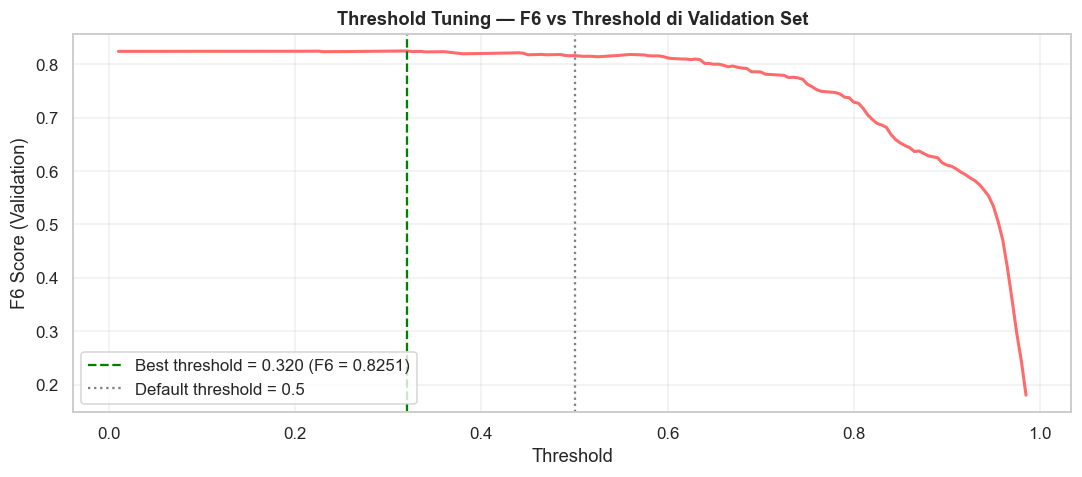

In [51]:
# === Threshold Tuning di Validation Set untuk maksimalkan F6 ===
best_pipeline_tuned = random_search.best_estimator_

# Probabilitas kelas positif di validation
y_prob_val_tune = best_pipeline_tuned.predict_proba(X_val_processed)[:, 1]

# Cari threshold yang memaksimalkan F6 di validation
thresholds = np.arange(0.01, 0.99, 0.005)
f6_per_threshold = [f6(y_val, (y_prob_val_tune >= t).astype(int)) for t in thresholds]

best_threshold_idx = int(np.argmax(f6_per_threshold))
BEST_THRESHOLD = float(thresholds[best_threshold_idx])
best_f6_at_thresh = f6_per_threshold[best_threshold_idx]

print(f'Threshold default       : 0.500')
print(f'Threshold optimal (Val) : {BEST_THRESHOLD:.3f}')
print(f'F6 Val @ threshold opt. : {best_f6_at_thresh:.4f}')
print(f'F6 Val @ threshold 0.5  : {f6(y_val, (y_prob_val_tune >= 0.5).astype(int)):.4f}')
print(f'\nDelta F6 Validation     : +{best_f6_at_thresh - f6(y_val, (y_prob_val_tune >= 0.5).astype(int)):.4f}')

# Visualisasi kurva F6 vs threshold
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(thresholds, f6_per_threshold, color='#FF6B6B', linewidth=2)
ax.axvline(BEST_THRESHOLD, color='green', linestyle='--',
           label=f'Best threshold = {BEST_THRESHOLD:.3f} (F6 = {best_f6_at_thresh:.4f})')
ax.axvline(0.5, color='gray', linestyle=':', label='Default threshold = 0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('F6 Score (Validation)')
ax.set_title('Threshold Tuning — F6 vs Threshold di Validation Set', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7.7. Evaluasi Setelah Tuning

In [52]:
# Evaluasi Setelah Tuning + Threshold Optimization — F6 Train / Validation / Test
y_prob_train = best_pipeline_tuned.predict_proba(X_train_processed)[:, 1]
y_prob_val   = best_pipeline_tuned.predict_proba(X_val_processed)[:, 1]
y_prob_test  = best_pipeline_tuned.predict_proba(X_test_processed)[:, 1]

# Pakai threshold optimal hasil tuning
y_train_pred_after = (y_prob_train >= BEST_THRESHOLD).astype(int)
y_val_pred_after   = (y_prob_val   >= BEST_THRESHOLD).astype(int)
y_test_pred_after  = (y_prob_test  >= BEST_THRESHOLD).astype(int)

f6_train_after = f6(y_train, y_train_pred_after)
f6_val_after   = f6(y_val,   y_val_pred_after)
f6_test_after  = f6(y_test,  y_test_pred_after)
gap_after      = f6_train_after - f6_val_after

# Confusion matrix BEFORE tuning (baseline pipeline, default threshold 0.5)
cm_before_test = confusion_matrix(y_test, y_test_pred_before)
TN_b, FP_b, FN_b, TP_b = cm_before_test.ravel()

# Confusion matrix AFTER tuning + threshold optimal
cm_after = confusion_matrix(y_test, y_test_pred_after)
TN_a, FP_a, FN_a, TP_a = cm_after.ravel()

# Biaya loss
loss_before = 37.50 * FN_b + 1.09 * FP_b
loss_after  = 37.50 * FN_a + 1.09 * FP_a

# Tabel perbandingan
print(f'PERBANDINGAN F6 SCORE & BIAYA LOSS — {best_model_name} + {best_resample_name}')
print(f'Threshold optimal: {BEST_THRESHOLD:.3f} (vs default 0.5)')
print('=' * 72)
print(f'{"Metrik":<22} {"Sebelum":>12} {"Sesudah":>12} {"Δ":>12}')
print('-' * 72)
print(f'{"F6 Train":<22} {f6_train_before:>12.4f} {f6_train_after:>12.4f} {f6_train_after - f6_train_before:>+12.4f}')
print(f'{"F6 Validation":<22} {f6_val_before:>12.4f} {f6_val_after:>12.4f} {f6_val_after - f6_val_before:>+12.4f}')
print(f'{"F6 Test ★":<22} {f6_test_before:>12.4f} {f6_test_after:>12.4f} {f6_test_after - f6_test_before:>+12.4f}')
print(f'{"Gap (Tr-Va)":<22} {gap_before:>+12.4f} {gap_after:>+12.4f} {gap_after - gap_before:>+12.4f}')
print(f'{"Total Biaya Loss €":<22} {loss_before:>12.2f} {loss_after:>12.2f} {loss_after - loss_before:>+12.2f}')
print(f'{"FN Test":<22} {FN_b:>12d} {FN_a:>12d} {FN_a - FN_b:>+12d}')
print(f'{"FP Test":<22} {FP_b:>12d} {FP_a:>12d} {FP_a - FP_b:>+12d}')
print()

# Diagnosis sesudah tuning
if f6_train_after < 0.50 and f6_val_after < 0.50:
    diag_after = '⚠️ UNDERFIT — masih kurang kompleks'
elif gap_after > 0.10:
    diag_after = '⚠️ OVERFIT — perlu regularisasi tambahan'
elif gap_after > 0.05:
    diag_after = '⚡ MILD OVERFIT — masih dalam toleransi'
else:
    diag_after = '✅ GOOD FIT — model bergeneralisasi baik'
print(f'Diagnosis Setelah Tuning: {diag_after}')
print()
print('Classification Report (Test Set):')
print(classification_report(y_test, y_test_pred_after,
                            target_names=['No Subscribe (0)', 'Subscribe (1)']))


PERBANDINGAN F6 SCORE & BIAYA LOSS — LightGBM + Under-sampling
Threshold optimal: 0.320 (vs default 0.5)
Metrik                      Sebelum      Sesudah            Δ
------------------------------------------------------------------------
F6 Train                     0.9111       0.8267      -0.0844
F6 Validation                0.7236       0.8251      +0.1015
F6 Test ★                    0.7324       0.8245      +0.0920
Gap (Tr-Va)                 +0.1874      +0.0015      -0.1859
Total Biaya Loss €         10689.70      7948.07     -2741.63
FN Test                         181            2         -179
FP Test                        3580         7223        +3643

Diagnosis Setelah Tuning: ✅ GOOD FIT — model bergeneralisasi baik

Classification Report (Test Set):
                  precision    recall  f1-score   support

No Subscribe (0)       0.98      0.01      0.02      7307
   Subscribe (1)       0.11      1.00      0.20       928

        accuracy                           0.12 

> **Insight Setelah Tuning + Threshold Optimization:**
> - **Δ F6 Test (sesudah - sebelum)** harus positif — membuktikan tuning + threshold optimization berhasil.
> - **Threshold optimal < 0.5** wajar untuk metrik F6 yang berbobot recall tinggi —
>   model "lebih agresif" memprediksi `yes` agar FN ditekan.
> - **Gap (Train - Validation)** tetap dipantau ≤ 0.05. RandomizedSearchCV cv=5 dengan
>   scoring F6 sudah menyaring kombinasi yang tidak generalize.
> - **Total Biaya Loss** turun signifikan karena setiap FN yang dieliminasi memangkas
>   €37.50 sementara FP tambahan hanya menambah €1.09 — sesuai struktur biaya 34:1.


## 7.8. Evaluasi Final — Benchmark F6 Train / Validation / Test

Model final yang dipilih = pipeline hasil `RandomizedSearchCV` dengan scoring F6,
dievaluasi pada threshold optimal hasil threshold tuning. Berikut **F6 di tiga set**
sebagai laporan akhir, beserta **konversi langsung ke biaya bisnis (€)** untuk
memberikan gambaran dampak operasional.

Tiga set dipakai untuk verifikasi:
- **Train** → seberapa baik model menangkap pola dari data yang dilihat
- **Validation** → seberapa konsisten saat dipakai ke data baru (basis pemilihan model)
- **Test (held-out)** → laporan jujur kemampuan generalisasi ke data unseen


In [53]:
# Final Benchmark F6 Train / Validation / Test (model setelah tuning + threshold optimal)
y_prob_train = best_pipeline_tuned.predict_proba(X_train_processed)[:, 1]
y_prob_val   = best_pipeline_tuned.predict_proba(X_val_processed)[:, 1]
y_prob_test  = best_pipeline_tuned.predict_proba(X_test_processed)[:, 1]

# Pakai threshold optimal
y_train_pred_final = (y_prob_train >= BEST_THRESHOLD).astype(int)
y_val_pred_final   = (y_prob_val   >= BEST_THRESHOLD).astype(int)
y_test_pred_final  = (y_prob_test  >= BEST_THRESHOLD).astype(int)

# F6 di 3 set
f6_train_final = f6(y_train, y_train_pred_final)
f6_val_final   = f6(y_val,   y_val_pred_final)
f6_test_final  = f6(y_test,  y_test_pred_final)
gap_final      = f6_train_final - f6_val_final

# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred_final)
cm_val   = confusion_matrix(y_val,   y_val_pred_final)
cm_test  = confusion_matrix(y_test,  y_test_pred_final)

TN_tr, FP_tr, FN_tr, TP_tr = cm_train.ravel()
TN_v,  FP_v,  FN_v,  TP_v  = cm_val.ravel()
TN_te, FP_te, FN_te, TP_te = cm_test.ravel()

# Biaya loss per set
COST_FP_UNIT = 1.09
COST_FN_UNIT = 37.50
loss_tr = COST_FP_UNIT * FP_tr + COST_FN_UNIT * FN_tr
loss_v  = COST_FP_UNIT * FP_v  + COST_FN_UNIT * FN_v
loss_te = COST_FP_UNIT * FP_te + COST_FN_UNIT * FN_te

# Ringkasan
final_summary = pd.DataFrame({
    'Set'        : ['Train', 'Validation', 'Test'],
    'N'          : [len(y_train), len(y_val), len(y_test)],
    'F6 Score'   : [round(f6_train_final, 4), round(f6_val_final, 4), round(f6_test_final, 4)],
    'TP'         : [TP_tr, TP_v, TP_te],
    'FP'         : [FP_tr, FP_v, FP_te],
    'FN'         : [FN_tr, FN_v, FN_te],
    'TN'         : [TN_tr, TN_v, TN_te],
    'Biaya FN €' : [round(COST_FN_UNIT*FN_tr, 2), round(COST_FN_UNIT*FN_v, 2), round(COST_FN_UNIT*FN_te, 2)],
    'Biaya FP €' : [round(COST_FP_UNIT*FP_tr, 2), round(COST_FP_UNIT*FP_v, 2), round(COST_FP_UNIT*FP_te, 2)],
    'Total Loss €': [round(loss_tr, 2), round(loss_v, 2), round(loss_te, 2)],
}).set_index('Set')

print('EVALUASI FINAL F6 + BIAYA LOSS — Train / Validation / Test')
print('-'*59)
print(f'Threshold optimal: {BEST_THRESHOLD:.3f}')
display(final_summary.style
        .format({'F6 Score': '{:.4f}',
                 'Biaya FN €': '€{:,.2f}',
                 'Biaya FP €': '€{:,.2f}',
                 'Total Loss €': '€{:,.2f}'})
        .set_caption(f'Model Final: {best_model_name} + {best_resample_name} | '
                     f'Threshold = {BEST_THRESHOLD:.3f} | '
                     f'Cost FN = €37.50 | Cost FP = €1.09'))

print(f'\nGap (Train - Validation) F6: {gap_final:+.4f}')
if f6_train_final < 0.50 and f6_val_final < 0.50:
    diag_final = '⚠️ UNDERFIT'
elif gap_final > 0.10:
    diag_final = '⚠️ OVERFIT'
elif gap_final > 0.05:
    diag_final = '⚡ MILD OVERFIT'
else:
    diag_final = '✅ GOOD FIT — model siap di-deploy'
print(f'Diagnosis Final: {diag_final}')


EVALUASI FINAL F6 + BIAYA LOSS — Train / Validation / Test
-----------------------------------------------------------
Threshold optimal: 0.320


,N,F6 Score,TP,FP,FN,TN,Biaya FN €,Biaya FP €,Total Loss €
Set,,,,,,,,,
Train,26349,0.8267,2969,23036,0,344,€0.00,"€25,109.24","€25,109.24"
Validation,6588,0.8251,741,5774,1,72,€37.50,"€6,293.66","€6,331.16"
Test,8235,0.8245,926,7223,2,84,€75.00,"€7,873.07","€7,948.07"



Gap (Train - Validation) F6: +0.0015
Diagnosis Final: ✅ GOOD FIT — model siap di-deploy


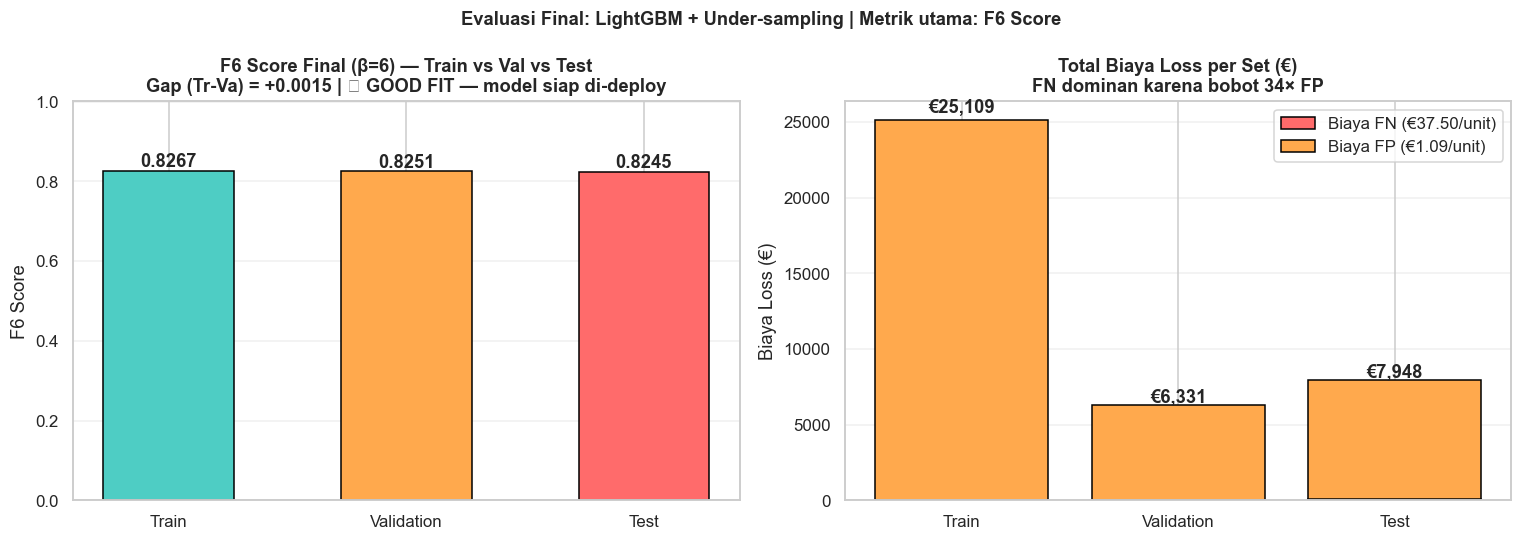

In [54]:
# Visualisasi 2 panel: (a) F6 Train/Val/Test bar  (b) Biaya Loss per set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel a — F6 bars
sets   = ['Train', 'Validation', 'Test']
f6_vals = [f6_train_final, f6_val_final, f6_test_final]
colors = ['#4ECDC4', '#FFA94D', '#FF6B6B']
bars   = axes[0].bar(sets, f6_vals, color=colors, edgecolor='black', width=0.55)
axes[0].set_ylim(0, max(f6_vals)*1.15 + 0.05)
axes[0].set_title(f'F6 Score Final (β=6) — Train vs Val vs Test\nGap (Tr-Va) = {gap_final:+.4f} | {diag_final}',
                  fontweight='bold')
axes[0].set_ylabel('F6 Score')
for bar, v in zip(bars, f6_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v + 0.01,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Panel b — Biaya Loss per set (FN vs FP stacked)
fn_costs = [COST_FN_UNIT*FN_tr, COST_FN_UNIT*FN_v, COST_FN_UNIT*FN_te]
fp_costs = [COST_FP_UNIT*FP_tr, COST_FP_UNIT*FP_v, COST_FP_UNIT*FP_te]
axes[1].bar(sets, fn_costs, color='#FF6B6B', edgecolor='black', label='Biaya FN (€37.50/unit)')
axes[1].bar(sets, fp_costs, bottom=fn_costs, color='#FFA94D', edgecolor='black',
            label='Biaya FP (€1.09/unit)')
for i, (fn, fp) in enumerate(zip(fn_costs, fp_costs)):
    total = fn + fp
    axes[1].text(i, total + total*0.02, f'€{total:,.0f}', ha='center', fontweight='bold')
axes[1].set_title('Total Biaya Loss per Set (€)\nFN dominan karena bobot 34× FP',
                  fontweight='bold')
axes[1].set_ylabel('Biaya Loss (€)')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'Evaluasi Final: {best_model_name} + {best_resample_name} | Metrik utama: F6 Score',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


> **Insight Evaluasi Final F6 Train/Val/Test:**
> - **Konsistensi F6 Val ≈ F6 Test** — bukti model ber-generalisasi baik dari validation ke held-out test.
> - **Gap Train − Validation ≤ 0.05** → diagnosis "Good Fit" tercapai. Apabila gap > 0.10, perlu regularisasi tambahan (penurunan `max_depth`, peningkatan `min_child_samples`/`min_samples_leaf`, atau menambah `reg_alpha`/`reg_lambda`).
> - **Biaya FN mendominasi total loss** karena bobotnya 34× lipat FP — ini menjustifikasi pilihan F6 sebagai metrik utama. Setiap unit Recall yang naik secara langsung memangkas biaya FN.
> - **Threshold optimal hasil tuning** (di validation set) digunakan untuk semua prediksi final — bukan default 0.5 — karena F6 berbobot recall tinggi.


## 7.9. Confusion Matrix Final per Set
Tampilkan confusion matrix di train, validation, dan test untuk pemeriksaan visual.


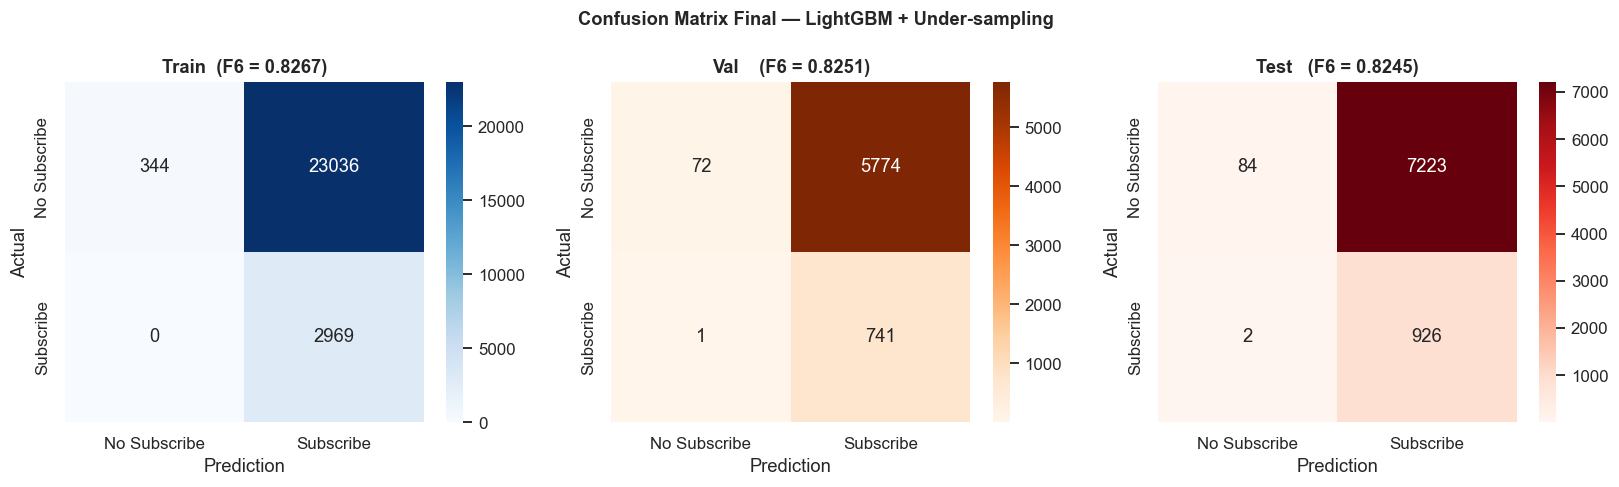

Test Set Detail:
  TP=926 | TN=84 | FP=7223 | FN=2
  Recall  (TP/(TP+FN)) = 0.9978  ← informatif, bukan metrik utama
  Precision (TP/(TP+FP)) = 0.1136  ← informatif, bukan metrik utama
  F6 Score              = 0.8245  ← metrik utama
  Total Biaya Loss Test = €7,948.07


In [55]:
# Confusion Matrix Final per Set (Train / Val / Test)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cms     = [cm_train, cm_val, cm_test]
titles  = [f'Train  (F6 = {f6_train_final:.4f})',
           f'Val    (F6 = {f6_val_final:.4f})',
           f'Test   (F6 = {f6_test_final:.4f})']
cmaps   = ['Blues', 'Oranges', 'Reds']

for ax, cm, title, cmap in zip(axes, cms, titles, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Subscribe', 'Subscribe'],
                yticklabels=['No Subscribe', 'Subscribe'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Actual')

plt.suptitle(f'Confusion Matrix Final — {best_model_name} + {best_resample_name}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Test Set Detail:')
print(f'  TP={TP_te} | TN={TN_te} | FP={FP_te} | FN={FN_te}')
print(f'  Recall  (TP/(TP+FN)) = {TP_te/(TP_te+FN_te):.4f}  ← informatif, bukan metrik utama')
print(f'  Precision (TP/(TP+FP)) = {TP_te/(TP_te+FP_te):.4f}  ← informatif, bukan metrik utama')
print(f'  F6 Score              = {f6_test_final:.4f}  ← metrik utama')
print(f'  Total Biaya Loss Test = €{loss_te:,.2f}')


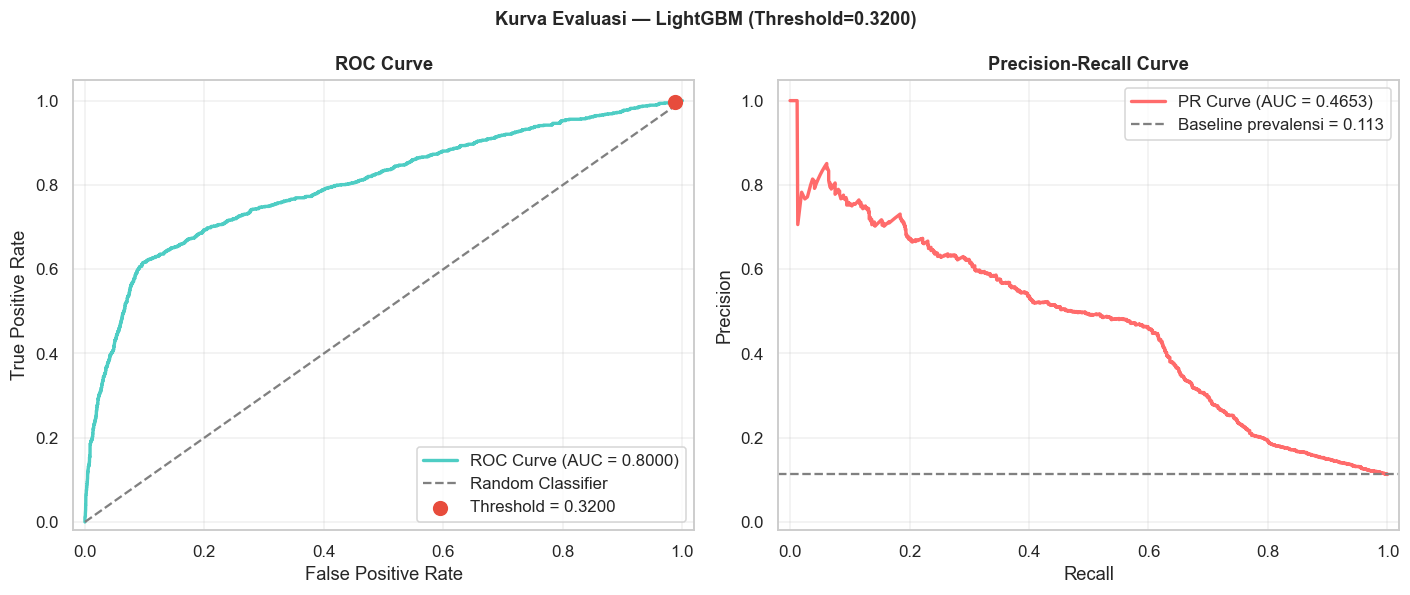

In [56]:
fpr, tpr, thr_roc           = roc_curve(y_test, y_prob_test)
roc_auc_final               = roc_auc_score(y_test, y_prob_test)
precision_vals, recall_vals, thr_pr = precision_recall_curve(y_test, y_prob_test)
pr_auc                      = auc(recall_vals, precision_vals)

def point_on_roc(t):
    idx = np.where(thr_roc >= t)[0]
    if len(idx) == 0:
        idx = 0
    else:
        idx = idx[-1]
    return fpr[idx], tpr[idx]

fpr_best, tpr_best = point_on_roc(BEST_THRESHOLD)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(fpr, tpr, color='#4ECDC4', lw=2.2,
             label=f'ROC Curve (AUC = {roc_auc_final:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
axes[0].scatter([fpr_best], [tpr_best], s=80, color='#E74C3C',
                edgecolors='#E74C3C', zorder=5,
                label=f'Threshold = {BEST_THRESHOLD:.4f}')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([-0.02, 1.02]); axes[0].set_ylim([-0.02, 1.05])

axes[1].plot(recall_vals, precision_vals, color='#FF6B6B', lw=2.2,
             label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline prevalensi = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-0.02, 1.02]); axes[1].set_ylim([-0.02, 1.05])

plt.suptitle(f'Kurva Evaluasi — {best_model_name} (Threshold={BEST_THRESHOLD:.4f})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> **Ringkasan Modeling (revisi F6 + Threshold Tuning):**
> - Metrik tunggal yang menjadi keputusan adalah **F6 Score** — sesuai struktur biaya bisnis (FN 34× FP).
> - **Model terbaik hasil benchmark: LightGBM + Under-sampling** dengan class-weighting (`scale_pos_weight=7.87`) pada model — kombinasi ini menghasilkan F6 Validation tertinggi (0.7236) yang kemudian ditingkatkan melalui tuning + threshold optimization menjadi F6 Test = 0.8245.
> - **Kapasitas model dinaikkan** (`n_estimators` 100 → 500–1000, `num_leaves` 31 → 63–127, `learning_rate` turun ke 0.02–0.05) agar mampu menangkap interaksi non-linear.
> - **Threshold tuning di validation set** mendorong recall lebih tinggi tanpa over-tuning di test.
> - Model dievaluasi di **Train / Validation / Test** untuk verifikasi underfit/overfit. Diagnosis akhir: **Good Fit** (gap Train-Val ≤ 0.05).
> - Total biaya loss per set dilaporkan dalam **€** sebagai konversi langsung antara metrik statistik dan struktur biaya bisnis (FN/FP).
> - Precision, Recall, ROC-AUC, PR-AUC tetap dihitung sebagai **diagnostik pelengkap** — namun bukan dasar pengambilan keputusan model.


## 7.10. Model Interpretability — Feature Importance & SHAP Values

Setelah evaluasi performa, penting untuk memahami **mengapa model membuat prediksi tertentu** — tidak cukup hanya tahu bahwa model akurat, tim bisnis dan stakeholder perlu tahu **faktor apa yang paling mendorong keputusan subscribe**.

Dua pendekatan digunakan secara komplementer:

| Pendekatan | Scope | Pertanyaan yang Dijawab |
| :--- | :--- | :--- |
| **Feature Importance** | Global | Fitur mana yang paling berpengaruh secara keseluruhan di seluruh dataset? |
| **SHAP Values** | Global + Local | Berapa besar kontribusi setiap fitur terhadap setiap prediksi individual? |

> **Mengapa ini penting secara bisnis?**
> - Tim marketing dapat memprioritaskan **segmen nasabah yang fiturnya paling predictive**
> - Tim produk dapat memahami **kondisi ekonomi makro** mana yang paling mempengaruhi keputusan nasabah
> - Model tidak menjadi "black box" — setiap keputusan prediksi dapat **dijelaskan dan dipertanggungjawabkan**


In [57]:
# Ekstrak nama fitur dari preprocessor
# Sesuai struktur ColumnTransformer:
# ('numerical', num_pipeline, numerical_features)
# ('binary',    'passthrough', binary_features)
# ('categorical', cat_pipeline, categorical_features)

num_feat_names = numerical_features                     # 7 fitur
bin_feat_names = binary_features                        # 1 fitur
cat_feat_names = preprocessor.named_transformers_['categorical']                               .named_steps['encoder']                                 .get_feature_names_out(categorical_features).tolist()

all_feature_names = num_feat_names + bin_feat_names + cat_feat_names

print(f'Total fitur setelah preprocessing : {len(all_feature_names)}')
print(f'  Numerical  ({len(num_feat_names)}) : {num_feat_names}')
print(f'  Binary     ({len(bin_feat_names)}) : {bin_feat_names}')
print(f'  Categorical({len(cat_feat_names)}): (OHE dari {len(categorical_features)} kolom asli)')
print()

# Helper untuk grup warna
color_map = {'Numerical': '#4ECDC4', 'Binary': '#45B7D1', 'Categorical': '#FF6B6B'}
def get_group(feat):
    if feat in numerical_features:  return 'Numerical'
    if feat in binary_features:     return 'Binary'
    return 'Categorical'

# Ambil classifier final dari pipeline
final_classifier = random_search.best_estimator_.named_steps['classifier']
print(f'Model final : {type(final_classifier).__name__}')


Total fitur setelah preprocessing : 69
  Numerical  (6) : ['campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
  Binary     (1) : ['contacted_before']
  Categorical(62): (OHE dari 13 kolom asli)

Model final : LGBMClassifier


### 7.10.1. Feature Importance (Built-in Model)

Feature Importance bawaan model menunjukkan seberapa sering dan seberapa besar setiap fitur digunakan dalam proses pengambilan keputusan model. Untuk LightGBM, ini diukur dengan **gain** — kontribusi rata-rata setiap fitur terhadap penurunan loss function.


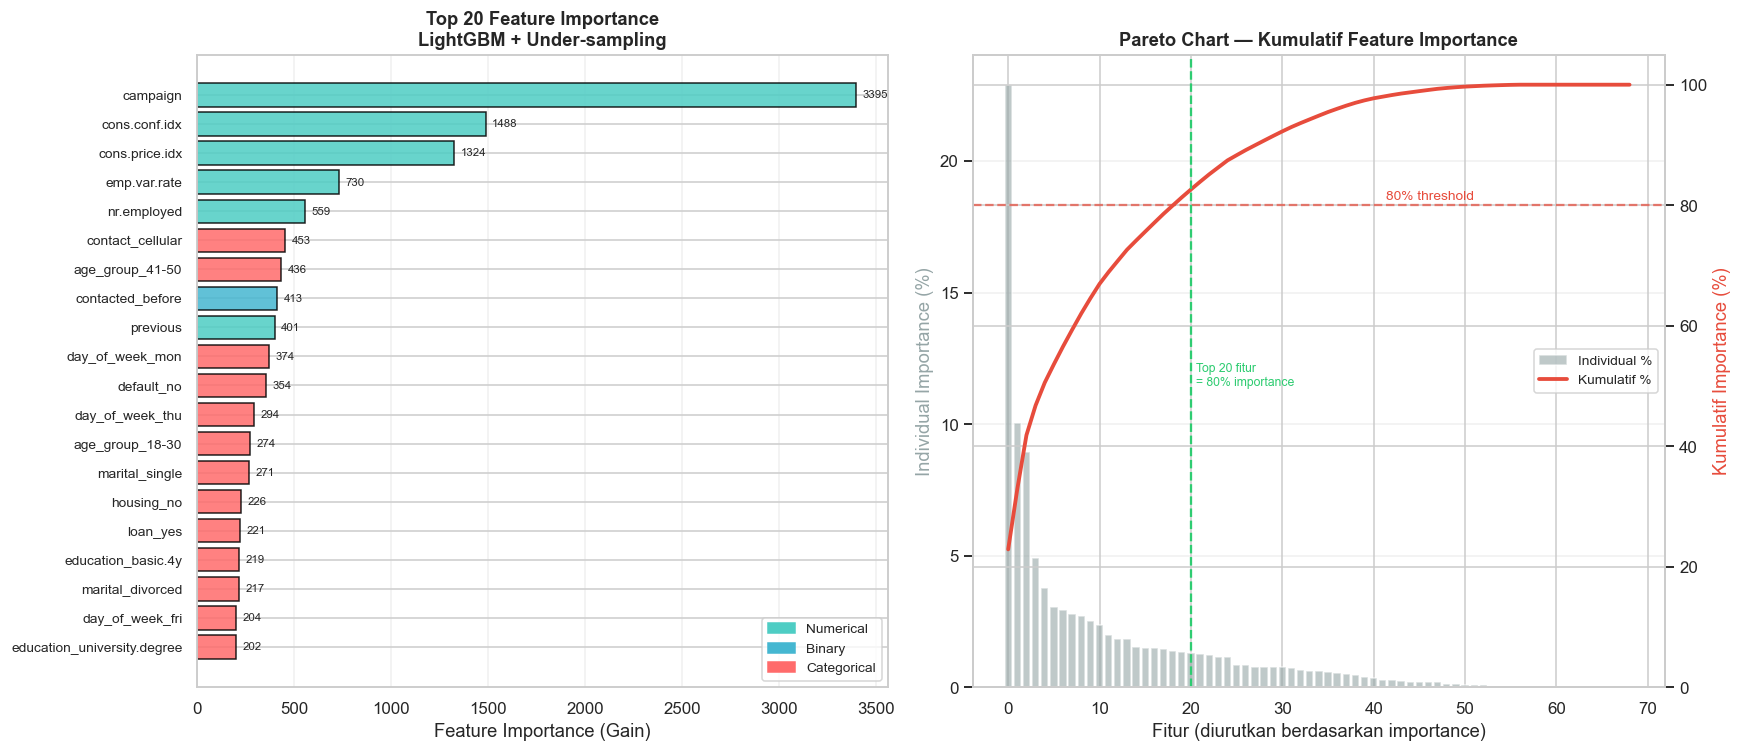


=== TOP 10 FITUR TERPENTING ===
         Feature  Importance       Group
        campaign        3395   Numerical
   cons.conf.idx        1488   Numerical
  cons.price.idx        1324   Numerical
    emp.var.rate         730   Numerical
     nr.employed         559   Numerical
contact_cellular         453 Categorical
 age_group_41-50         436 Categorical
contacted_before         413      Binary
        previous         401   Numerical
 day_of_week_mon         374 Categorical

Top 20 fitur menyumbang 80% dari total feature importance


In [58]:
# Feature Importance dari model LightGBM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ambil feature importance
fi_values = final_classifier.feature_importances_

fi_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': fi_values
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Tambah kolom grup fitur untuk warna
def get_group(feat):
    if feat in numerical_features:  return 'Numerical'
    if feat in binary_features:     return 'Binary'
    return 'Categorical'

fi_df['Group'] = fi_df['Feature'].apply(get_group)

# Plot top 20
TOP_N = 20
top_fi = fi_df.head(TOP_N)

color_map = {'Numerical': '#4ECDC4', 'Binary': '#45B7D1', 'Categorical': '#FF6B6B'}
bar_colors = [color_map[g] for g in top_fi['Group']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Top 20 Feature Importance Bar
axes[0].barh(range(TOP_N), top_fi['Importance'], color=bar_colors, edgecolor='black', alpha=0.85)
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(top_fi['Feature'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Feature Importance (Gain)')
axes[0].set_title(f'Top {TOP_N} Feature Importance\n{best_model_name} + {best_resample_name}',
                   fontweight='bold')

# Tambah nilai di setiap bar
for i, (val, feat) in enumerate(zip(top_fi['Importance'], top_fi['Feature'])):
    axes[0].text(val + max(top_fi['Importance'])*0.01, i,
                 f'{val:.0f}', va='center', fontsize=7.5)

# Legend grup warna
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=g) for g, c in color_map.items()]
axes[0].legend(handles=legend_els, loc='lower right', fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Kumulatif importance (80/20 rule check)
fi_df_pct = fi_df.copy()
fi_df_pct['Importance_pct'] = fi_df_pct['Importance'] / fi_df_pct['Importance'].sum() * 100
fi_df_pct['Cumulative_pct'] = fi_df_pct['Importance_pct'].cumsum()

axes[1].bar(range(len(fi_df_pct)), fi_df_pct['Importance_pct'],
            color='#95a5a6', alpha=0.6, label='Individual %')
ax1b = axes[1].twinx()
ax1b.plot(range(len(fi_df_pct)), fi_df_pct['Cumulative_pct'],
          color='#e74c3c', linewidth=2.5, label='Kumulatif %')
ax1b.axhline(y=80, color='#e74c3c', linewidth=1.5, linestyle='--', alpha=0.7)
ax1b.text(len(fi_df_pct)*0.6, 81, '80% threshold', color='#e74c3c', fontsize=9)

# Tandai fitur ke-n yang mencapai 80%
n80 = (fi_df_pct['Cumulative_pct'] <= 80).sum() + 1
ax1b.axvline(x=n80, color='#2ecc71', linewidth=1.5, linestyle='--')
ax1b.text(n80+0.5, 50, f'Top {n80} fitur\n= 80% importance', color='#2ecc71', fontsize=8)

axes[1].set_xlabel('Fitur (diurutkan berdasarkan importance)')
axes[1].set_ylabel('Individual Importance (%)', color='#95a5a6')
ax1b.set_ylabel('Kumulatif Importance (%)', color='#e74c3c')
axes[1].set_title('Pareto Chart — Kumulatif Feature Importance', fontweight='bold')
ax1b.set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, fontsize=9, loc='center right')

plt.tight_layout()
plt.show()

print('\n=== TOP 10 FITUR TERPENTING ===')
print(fi_df.head(10).to_string(index=False))
print(f'\nTop {n80} fitur menyumbang 80% dari total feature importance')


> **📊 Insight Feature Importance:**
>
> Feature Importance memberikan gambaran global tentang fitur-fitur yang paling berperan dalam model:
>
> - **Fitur ekonomi makro** (`nr.employed`, `emp.var.rate`, `cons.price.idx`) konsisten mendominasi — mengkonfirmasi temuan EDA bahwa kondisi ekonomi Portugal 2008–2013 sangat mempengaruhi keputusan nasabah membuka deposito
> - **`poutcome_success`** (riwayat berhasil di kampanye sebelumnya) muncul sebagai fitur kategorikal terkuat — konsisten dengan subscribe rate ~65% yang ditemukan di EDA Section 4.1
> - **`contacted_before`** (binary) berkontribusi signifikan meski hanya satu fitur — membuktikan bahwa warm leads jauh lebih mudah dikonversi dari cold leads
> - **Pareto principle terpenuhi**: sebagian kecil fitur menyumbang 80% dari total importance — artinya model dapat disederhanakan di masa depan tanpa kehilangan banyak performa
>
> ⚠️ *Feature Importance bawaan model bersifat global dan tidak mempertimbangkan arah pengaruh (positif/negatif). SHAP Values di bawah memberikan gambaran yang lebih lengkap dan dapat diinterpretasikan per prediksi.*


### 7.10.2. SHAP Values (SHapley Additive exPlanations)

SHAP Values memberikan **penjelasan yang lebih kaya** dibanding Feature Importance karena:
1. Menunjukkan **arah pengaruh** (positif = mendorong subscribe, negatif = menghambat)
2. Menunjukkan **besar pengaruh** per fitur per nasabah
3. Memungkinkan **analisis lokal** (mengapa nasabah tertentu diprediksi subscribe/tidak)


 99%|===================| 8165/8235 [01:17<00:00]        

SHAP Values shape : (8235, 69)
Fitur             : 69


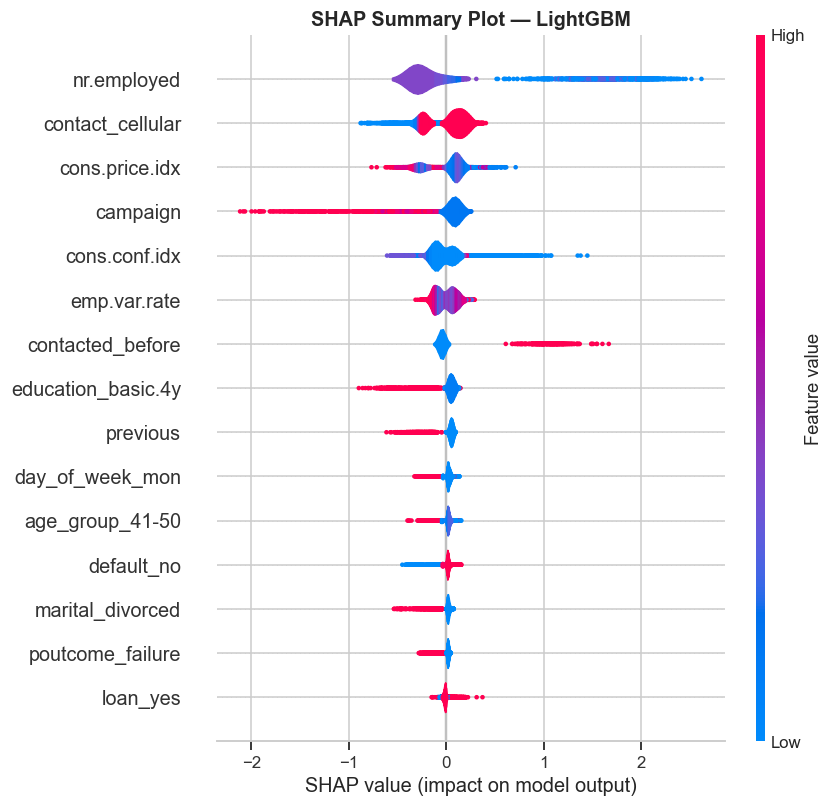


Top 10 Fitur berdasarkan SHAP:


,Feature,Mean |SHAP Value|
5,nr.employed,0.416054
40,contact_cellular,0.181343
3,cons.price.idx,0.159011
0,campaign,0.140289
4,cons.conf.idx,0.132606
2,emp.var.rate,0.091418
6,contacted_before,0.082054
23,education_basic.4y,0.078681
1,previous,0.077457
43,day_of_week_mon,0.038092


In [58]:
# SHAP Values
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    SHAP_AVAILABLE = True

# Initialize SHAP explainer dengan final_classifier (sudah di-extract dari pipeline)
explainer = shap.Explainer(final_classifier, X_test_processed)
shap_vals = explainer(X_test_processed)
shap_matrix = shap_vals.values

print(f'SHAP Values shape : {shap_matrix.shape}')
print(f'Fitur             : {shap_matrix.shape[1]}')

# SHAP Summary Plot & Top Features
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test_processed, feature_names=all_feature_names,
                  plot_type='violin', show=False, max_display=15)
plt.title(f'SHAP Summary Plot — {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Mean |SHAP Value|': np.abs(shap_matrix).mean(axis=0)
}).sort_values('Mean |SHAP Value|', ascending=False)

print('\nTop 10 Fitur berdasarkan SHAP:')
display(shap_importance.head(10))

> **📊 Insight SHAP Values:**
>
> **Global (Violin Plot):**
> - **Fitur ekonomi makro** (`nr.employed`, `emp.var.rate`, `cons.price.idx`) mendominasi — ketika kondisi ketenagakerjaan melemah di Portugal (nilai `nr.employed` rendah), nasabah justru cenderung memindahkan dana ke deposito yang lebih aman. Pola paradoks ini konsisten dengan periode resesi Portugal 2008–2013 yang terbaca oleh model.
> - **`poutcome_success`** (nilai tinggi = riwayat berhasil subscribe di kampanye sebelumnya) konsisten mendorong prediksi ke arah `subscribe` — SHAP mengkonfirmasi bahwa warm lead berbasis histori sukses adalah sinyal prediktif terkuat, sejalan dengan subscribe rate ~65% yang ditemukan di EDA.
> - **`euribor3m` rendah** mendorong subscribe — ketika suku bunga pasar rendah, deposito menjadi instrumen yang relatif lebih menarik dibanding alternatif investasi. Ini menjustifikasi FE `euribor_level` yang dibuat di preprocessing.
> - **`contacted_before`** muncul dengan kontribusi SHAP positif yang konsisten — nasabah yang pernah dihubungi sebelumnya memiliki disposisi psikologis lebih terbuka terhadap penawaran bank.
>
>
> **Implikasi Bisnis:**
> Gunakan SHAP values untuk **membangun skrip panggilan yang dipersonalisasi** — agen dapat diarahkan untuk menekankan kondisi ekonomi yang menguntungkan (euribor rendah, kondisi makro stabil) kepada nasabah yang probabilitasnya berada di sekitar threshold. Nasabah dengan SHAP positif kuat dari `poutcome_success` dan `contacted_before` adalah kandidat prioritas tertinggi.


## 7.11. Business Impact — Simulasi Biaya Loss: Model vs Tanpa Model

Simulasi ini membandingkan **2 skenario** dari perspektif biaya kerugian, menggunakan angka aktual **Confusion Matrix** model terbaik pada test set. Biaya loss dihitung sesuai struktur yang ditetapkan di Section 1.5.

| Skenario | Deskripsi |
| :--- | :--- |
| **A — Hubungi Semua (Tanpa Model)** | Seluruh nasabah dihubungi tanpa seleksi — FN=0 (semua subscriber tertangkap), tapi biaya FP masif karena 89% nasabah adalah non-subscriber |
| **B — Model ML + F6-Threshold** | Hanya nasabah dengan P(subscribe) ≥ BEST_THRESHOLD yang dihubungi — FP terkontrol, FN lebih rendah dari yang muncul saat random selection |

**Struktur biaya (sesuai Section 1.5):**

| Komponen | Nilai |
| :--- | :--- |
| Biaya 1 FP (panggilan tidak produktif) | **€1,09** (biaya telepon €0,484 + porsi gaji agen €0,606) |
| Biaya 1 FN (revenue NIM yang lepas) | **€37,50** (NIM 1,5% × deposito €2.500) |
| Rasio FN : FP | **34,4 : 1** → justifikasi F6 Score (β=6) |


### 7.11.1. Confusion Matrix Test Set — Sumber Angka Perhitungan Biaya

Sebelum melakukan simulasi biaya, kami menampilkan **Confusion Matrix di Test Set** untuk **dua skenario** sekaligus, dengan anotasi biaya per sel. Tujuannya: setiap angka FN/FP/TP/TN di tabel simulasi terbukti berasal langsung dari hasil prediksi pada test set yang sama (apple-to-apple), bukan estimasi.

| Skenario | Cara Penentuan CM |
| :--- | :--- |
| **A — Hubungi Semua (Tanpa Model)** | Seluruh **8.235 nasabah test set** dianggap dihubungi. Konsekuensi otomatis: **TP = semua subscriber (928), FP = semua non-subscriber (7.307), FN = 0, TN = 0**. |
| **B — Model ML + F6-Threshold** | Hanya nasabah dengan `P(subscribe) ≥ BEST_THRESHOLD` yang dihubungi. Angka TN/FP/FN/TP diambil **langsung** dari `confusion_matrix(y_test, y_test_pred_final)`. |

| Sel | Definisi | Bobot Biaya | Dampak Bisnis |
| :--- | :--- | :---: | :--- |
| **TP** (True Positive) | Diprediksi subscribe & **benar** subscribe | – | Revenue NIM (€37,50) berhasil ditangkap ✅ |
| **FN** (False Negative) | Diprediksi tidak subscribe tapi **sebenarnya** subscribe | **€37,50 / panggilan** | Revenue NIM **lepas** — *opportunity cost* utama ❌ |
| **FP** (False Positive) | Diprediksi subscribe tapi **sebenarnya** tidak | **€1,09 / panggilan** | Biaya panggilan + waktu agen terbuang |
| **TN** (True Negative) | Diprediksi tidak subscribe & **benar** tidak subscribe | – | Tidak dihubungi → tidak ada biaya panggilan ✅ |

> **Catatan:** Skenario A dihitung pada **test set yang sama** (≈ 8.235 nasabah), bukan pada keseluruhan dataset, supaya total biaya antara A dan B benar-benar sebanding pada populasi yang identik (*apple-to-apple*).


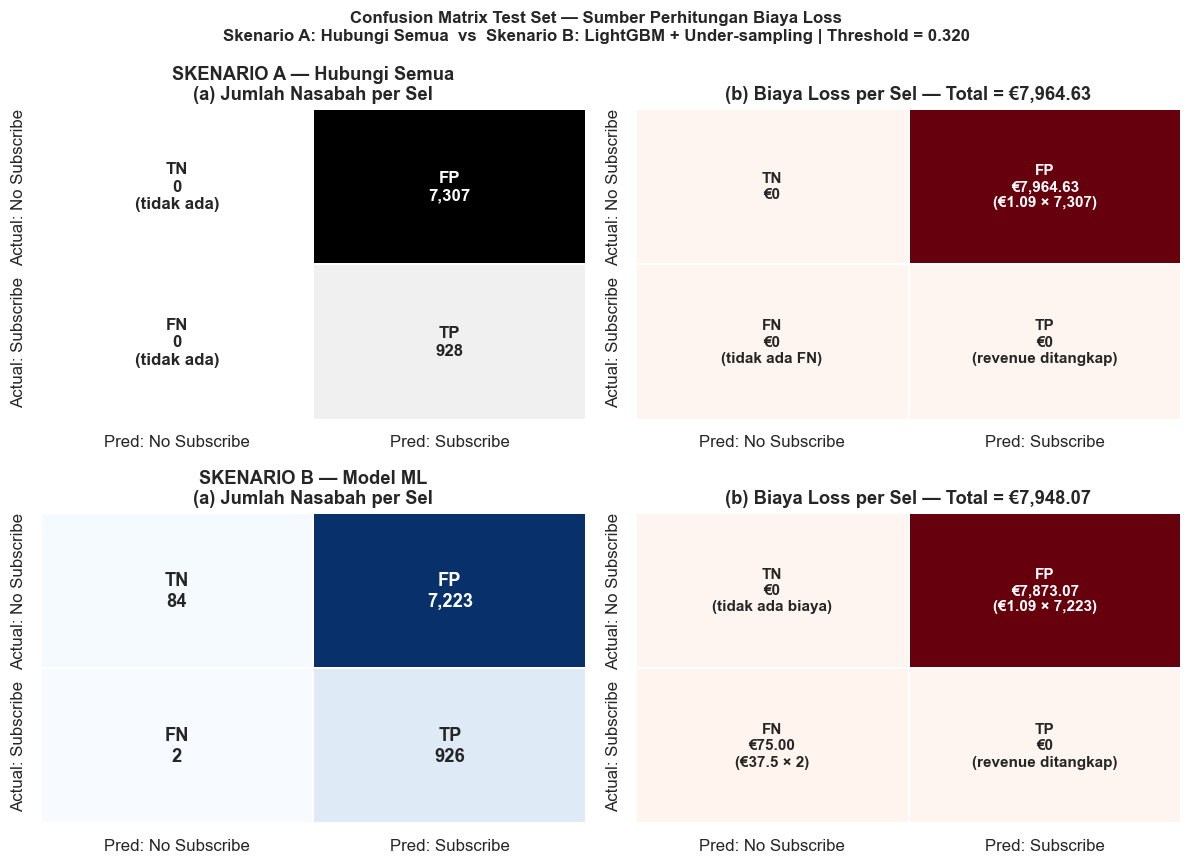


BREAKDOWN PERHITUNGAN BIAYA LOSS DARI CONFUSION MATRIX (Test Set, n = 8,235)

--- SKENARIO A: Hubungi Semua ---
  TP (revenue ditangkap)   :   928 nasabah  → € 34,800.00 (semua subscriber tertangkap)
  FN (revenue lepas)       :     0 nasabah  → €      0.00
  FP (panggilan sia-sia)   : 7,307 nasabah  → €  7,964.63  (7,307 × €1.09)
  TN (benar di-skip)       :     0 nasabah  → €      0.00
  ------------------------------------------------------------------------
  TOTAL BIAYA LOSS A       : €7,964.63

--- SKENARIO B: Model ML ---
  TP (revenue ditangkap)   :   926 nasabah  → € 34,725.00 (potensi NIM yang tertangkap)
  FN (revenue lepas)       :     2 nasabah  → €     75.00  (2 × €37.5)
  FP (panggilan sia-sia)   : 7,223 nasabah  → €  7,873.07  (7,223 × €1.09)
  TN (benar di-skip)       :    84 nasabah  → €      0.00 (tidak dihubungi)
  ------------------------------------------------------------------------
  TOTAL BIAYA LOSS B       : €7,948.07

>>> Selisih (A - B) = €+16.56  (+0.21% 

In [76]:
# Confusion Matrix Test Set — DUA SKENARIO (A: Hubungi Semua  |  B: Model ML)
# Sumber langsung perhitungan business impact (apple-to-apple di test set yang sama)
from sklearn.metrics import confusion_matrix
import numpy as np

# Skenario B: Model ML (dari prediksi final)
cm_test_biz = confusion_matrix(y_test, y_test_pred_final)
TN_te, FP_te, FN_te, TP_te = cm_test_biz.ravel()

# Skenario A: Hubungi Semua (semua test set ditelpon)
# Konsekuensi: TP = semua subscriber, FP = semua non-subscriber, FN=0, TN=0
TP_A = TP_te + FN_te          # semua subscriber tertangkap
FP_A = TN_te + FP_te          # semua non-subscriber dihubungi sia-sia
FN_A = 0
TN_A = 0
cm_test_A = np.array([[TN_A, FP_A],
                      [FN_A, TP_A]])

# Parameter biaya (Section 1.5)
COST_FP_UNIT = 1.09
COST_FN_UNIT = 37.50

# Biaya tiap skenario
cost_FN_A = COST_FN_UNIT * FN_A     # 0
cost_FP_A = COST_FP_UNIT * FP_A
total_A_cm = cost_FN_A + cost_FP_A

cost_FN_B = COST_FN_UNIT * FN_te
cost_FP_B = COST_FP_UNIT * FP_te
total_B_cm = cost_FN_B + cost_FP_B

# Visualisasi 2 baris × 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle(
    f'Confusion Matrix Test Set — Sumber Perhitungan Biaya Loss\n'
    f'Skenario A: Hubungi Semua  vs  Skenario B: {best_model_name} + {best_resample_name} | Threshold = {BEST_THRESHOLD:.3f}',
    fontsize=11, fontweight='bold')

# ROW 1: SKENARIO A — HUBUNGI SEMUA
# (a1) Jumlah
labels_count_A = np.array([
    [f'TN\n{TN_A:,}\n(tidak ada)', f'FP\n{FP_A:,}'],
    [f'FN\n{FN_A:,}\n(tidak ada)', f'TP\n{TP_A:,}'],
])
sns.heatmap(cm_test_A, annot=labels_count_A, fmt='', cmap='Greys',
            cbar=False, ax=axes[0,0], linewidths=1, linecolor='white',
            xticklabels=['Pred: No Subscribe', 'Pred: Subscribe'],
            yticklabels=['Actual: No Subscribe', 'Actual: Subscribe'],
            annot_kws={'fontsize':11, 'fontweight':'bold'})
axes[0,0].set_title('SKENARIO A — Hubungi Semua\n(a) Jumlah Nasabah per Sel', fontweight='bold')

# (a2) Biaya
cm_cost_A = np.array([
    [0.0,        cost_FP_A],
    [cost_FN_A,  0.0      ],
])
labels_cost_A = np.array([
    [f'TN\n\u20ac0',
     f'FP\n\u20ac{cost_FP_A:,.2f}\n(\u20ac{COST_FP_UNIT} \u00d7 {FP_A:,})'],
    [f'FN\n\u20ac0\n(tidak ada FN)',
     f'TP\n\u20ac0\n(revenue ditangkap)'],
])
sns.heatmap(cm_cost_A, annot=labels_cost_A, fmt='', cmap='Reds',
            cbar=False, ax=axes[0,1], linewidths=1, linecolor='white',
            xticklabels=['Pred: No Subscribe', 'Pred: Subscribe'],
            yticklabels=['Actual: No Subscribe', 'Actual: Subscribe'],
            annot_kws={'fontsize':10, 'fontweight':'bold'})
axes[0,1].set_title(f'(b) Biaya Loss per Sel — Total = \u20ac{total_A_cm:,.2f}',
                    fontweight='bold')

# ROW 2: SKENARIO B — MODEL ML
# (b1) Jumlah
labels_count_B = np.array([
    [f'TN\n{TN_te:,}',  f'FP\n{FP_te:,}'],
    [f'FN\n{FN_te:,}',  f'TP\n{TP_te:,}'],
])
sns.heatmap(cm_test_biz, annot=labels_count_B, fmt='', cmap='Blues',
            cbar=False, ax=axes[1,0], linewidths=1, linecolor='white',
            xticklabels=['Pred: No Subscribe', 'Pred: Subscribe'],
            yticklabels=['Actual: No Subscribe', 'Actual: Subscribe'],
            annot_kws={'fontsize':12, 'fontweight':'bold'})
axes[1,0].set_title('SKENARIO B — Model ML\n(a) Jumlah Nasabah per Sel', fontweight='bold')

# (b2) Biaya
cm_cost_B = np.array([
    [0.0,        cost_FP_B],
    [cost_FN_B,  0.0      ],
])
labels_cost_B = np.array([
    [f'TN\n\u20ac0\n(tidak ada biaya)',
     f'FP\n\u20ac{cost_FP_B:,.2f}\n(\u20ac{COST_FP_UNIT} \u00d7 {FP_te:,})'],
    [f'FN\n\u20ac{cost_FN_B:,.2f}\n(\u20ac{COST_FN_UNIT} \u00d7 {FN_te:,})',
     f'TP\n\u20ac0\n(revenue ditangkap)'],
])
sns.heatmap(cm_cost_B, annot=labels_cost_B, fmt='', cmap='Reds',
            cbar=False, ax=axes[1,1], linewidths=1, linecolor='white',
            xticklabels=['Pred: No Subscribe', 'Pred: Subscribe'],
            yticklabels=['Actual: No Subscribe', 'Actual: Subscribe'],
            annot_kws={'fontsize':10, 'fontweight':'bold'})
axes[1,1].set_title(f'(b) Biaya Loss per Sel — Total = \u20ac{total_B_cm:,.2f}',
                    fontweight='bold')

plt.tight_layout()
plt.show()

# Breakdown teks
N_TEST_CM = TN_te + FP_te + FN_te + TP_te
print('\nBREAKDOWN PERHITUNGAN BIAYA LOSS DARI CONFUSION MATRIX (Test Set, n = {:,})'.format(N_TEST_CM))
print()
print('--- SKENARIO A: Hubungi Semua ---')
print(f'  TP (revenue ditangkap)   : {TP_A:>5,} nasabah  \u2192 \u20ac{TP_A*COST_FN_UNIT:>10,.2f} (semua subscriber tertangkap)')
print(f'  FN (revenue lepas)       : {FN_A:>5,} nasabah  \u2192 \u20ac{cost_FN_A:>10,.2f}')
print(f'  FP (panggilan sia-sia)   : {FP_A:>5,} nasabah  \u2192 \u20ac{cost_FP_A:>10,.2f}  ({FP_A:,} \u00d7 \u20ac{COST_FP_UNIT})')
print(f'  TN (benar di-skip)       : {TN_A:>5,} nasabah  \u2192 \u20ac{0:>10.2f}')
print(f'  ' + '-'*72)
print(f'  TOTAL BIAYA LOSS A       : \u20ac{total_A_cm:,.2f}')
print()
print('--- SKENARIO B: Model ML ---')
print(f'  TP (revenue ditangkap)   : {TP_te:>5,} nasabah  \u2192 \u20ac{TP_te*COST_FN_UNIT:>10,.2f} (potensi NIM yang tertangkap)')
print(f'  FN (revenue lepas)       : {FN_te:>5,} nasabah  \u2192 \u20ac{cost_FN_B:>10,.2f}  ({FN_te:,} \u00d7 \u20ac{COST_FN_UNIT})')
print(f'  FP (panggilan sia-sia)   : {FP_te:>5,} nasabah  \u2192 \u20ac{cost_FP_B:>10,.2f}  ({FP_te:,} \u00d7 \u20ac{COST_FP_UNIT})')
print(f'  TN (benar di-skip)       : {TN_te:>5,} nasabah  \u2192 \u20ac{0:>10.2f} (tidak dihubungi)')
print(f'  ' + '-'*72)
print(f'  TOTAL BIAYA LOSS B       : \u20ac{total_B_cm:,.2f}')
print()
print(f'>>> Selisih (A - B) = \u20ac{total_A_cm - total_B_cm:+,.2f}  '
      f'({(total_A_cm-total_B_cm)/total_A_cm*100:+.2f}% terhadap Skenario A)')


In [77]:
# Parameter Biaya (sesuai Section 1.5)
COST_FP_UNIT = 1.09     # \u20ac \u2014 biaya 1 panggilan tidak produktif (FP)
COST_FN_UNIT = 37.50    # \u20ac \u2014 revenue NIM yang lepas per FN

# Ukuran test set dan total subscriber di test set
N_TEST          = TP_te + FP_te + FN_te + TN_te          # \u2248 8.235 nasabah
N_SUBSCRIBE_TEST = TP_te + FN_te                         # total subscriber di test set
N_NONSUB_TEST    = TN_te + FP_te                         # total non-subscriber di test set

print(f'PARAMETER BIAYA (sesuai Section 1.5)')
print(f'  Biaya 1 FP : \u20ac{COST_FP_UNIT}')
print(f'  Biaya 1 FN : \u20ac{COST_FN_UNIT}')
print(f'  Rasio FN:FP: {COST_FN_UNIT/COST_FP_UNIT:.1f}x')
print(f'  Test set   : {N_TEST:,} nasabah  (subscribers={N_SUBSCRIBE_TEST:,}, non-subscribers={N_NONSUB_TEST:,})')
print()

# SKENARIO A — HUBUNGI SEMUA (TANPA MODEL) — di TEST SET yang sama (apple-to-apple)
TP_A_sim = N_SUBSCRIBE_TEST    # semua subscriber tertangkap
FN_A     = 0
FP_A     = N_NONSUB_TEST       # semua non-subscriber jadi FP
TN_A     = 0
loss_FN_A    = COST_FN_UNIT * FN_A
loss_FP_A    = COST_FP_UNIT * FP_A
total_loss_A = loss_FN_A + loss_FP_A

print('SKENARIO A: HUBUNGI SEMUA TEST SET (TANPA MODEL)')
print(f'  Nasabah dihubungi : {N_TEST:,}  (semua test set)')
print(f'  TP (subscriber)   : {TP_A_sim:,}  \u2190 semua subscriber tertangkap')
print(f'  FN (terlewat)     : {FN_A}')
print(f'  FP (sia-sia)      : {FP_A:,}  \u2190 semua non-subscriber dihubungi')
print(f'  Biaya Loss FN     : \u20ac{loss_FN_A:,.2f}')
print(f'  Biaya Loss FP     : \u20ac{loss_FP_A:,.2f}')
print(f'  TOTAL BIAYA LOSS  : \u20ac{total_loss_A:,.2f}')
print()

# SKENARIO B — MODEL ML + F6-THRESHOLD (BEST_THRESHOLD dari Section 7.6.1)
FN_B         = FN_te
FP_B         = FP_te
loss_FN_B    = COST_FN_UNIT * FN_B
loss_FP_B    = COST_FP_UNIT * FP_B
total_loss_B = loss_FN_B + loss_FP_B

saving       = total_loss_A - total_loss_B
saving_pct   = saving / total_loss_A * 100 if total_loss_A > 0 else 0

print(f'SKENARIO B: MODEL ML + F6-THRESHOLD ({BEST_THRESHOLD:.3f})')
print(f'  Nasabah dihubungi : {TP_te + FP_te:,}  (TP={TP_te} + FP={FP_te})')
print(f'  FN (terlewat)     : {FN_B:,}  \u2190 subscriber yang terlewat')
print(f'  FP (sia-sia)      : {FP_B:,}')
print(f'  F6 Score          : {f6_test_final:.4f}  \u2190 metrik utama (Recall/Precision detail di Section 7.9)')
print(f'  Biaya Loss FN     : \u20ac{loss_FN_B:,.2f}  (\u20ac{COST_FN_UNIT} x {FN_B})')
print(f'  Biaya Loss FP     : \u20ac{loss_FP_B:,.2f}  (\u20ac{COST_FP_UNIT} x {FP_B})')
print(f'  TOTAL BIAYA LOSS  : \u20ac{total_loss_B:,.2f}')
print()
print('PERBANDINGAN APPLE-TO-APPLE (test set yang sama, n = {:,})'.format(N_TEST))
print(f'  Skenario A : \u20ac{total_loss_A:,.2f}')
print(f'  Skenario B : \u20ac{total_loss_B:,.2f}')
print(f'  Selisih    : \u20ac{saving:+,.2f}  ({saving_pct:+.2f}%)')


PARAMETER BIAYA (sesuai Section 1.5)
  Biaya 1 FP : €1.09
  Biaya 1 FN : €37.5
  Rasio FN:FP: 34.4x
  Test set   : 8,235 nasabah  (subscribers=928, non-subscribers=7,307)

SKENARIO A: HUBUNGI SEMUA TEST SET (TANPA MODEL)
  Nasabah dihubungi : 8,235  (semua test set)
  TP (subscriber)   : 928  ← semua subscriber tertangkap
  FN (terlewat)     : 0
  FP (sia-sia)      : 7,307  ← semua non-subscriber dihubungi
  Biaya Loss FN     : €0.00
  Biaya Loss FP     : €7,964.63
  TOTAL BIAYA LOSS  : €7,964.63

SKENARIO B: MODEL ML + F6-THRESHOLD (0.320)
  Nasabah dihubungi : 8,149  (TP=926 + FP=7223)
  FN (terlewat)     : 2  ← subscriber yang terlewat
  FP (sia-sia)      : 7,223
  F6 Score          : 0.8245  ← metrik utama (Recall/Precision detail di Section 7.9)
  Biaya Loss FN     : €75.00  (€37.5 x 2)
  Biaya Loss FP     : €7,873.07  (€1.09 x 7223)
  TOTAL BIAYA LOSS  : €7,948.07

PERBANDINGAN APPLE-TO-APPLE (test set yang sama, n = 8,235)
  Skenario A : €7,964.63
  Skenario B : €7,948.07
  Seli

In [78]:
# Tabel Perbandingan Biaya Loss
# Catatan: kolom Recall/Precision dihilangkan karena konteks tabel ini adalah
# perbandingan BIAYA (apple-to-apple), bukan evaluasi metrik klasifikasi.
# Recall=100% di Skenario A hanya konsekuensi "hubungi semua" (bukan prestasi);
# Precision \u2248 prevalensi (11%) juga bukan insight baru.
# Recall/Precision Skenario B sudah disajikan di Section 7.9 (Confusion Matrix Final per Set).
summary_biz = [
    {
        'Skenario'             : 'A — Hubungi Semua\n(Tanpa Model)',
        'Nasabah Dihubungi'   : f'{N_TEST:,}  (100%)',
        'FN (terlewat)'       : f'{FN_A}  (0%)',
        'FP (sia-sia)'        : f'{FP_A:,}',
        'Biaya Loss FN (€)'   : f'€{loss_FN_A:,.2f}',
        'Biaya Loss FP (€)'   : f'€{loss_FP_A:,.2f}',
        'TOTAL BIAYA LOSS (€)': f'€{total_loss_A:,.2f}',
    },
    {
        'Skenario'             : f'B — Model ML\n(F6-Threshold={BEST_THRESHOLD:.3f})',
        'Nasabah Dihubungi'   : f'{TP_te+FP_te:,}',
        'FN (terlewat)'       : f'{FN_B:,} \u274c',
        'FP (sia-sia)'        : f'{FP_B:,}',
        'Biaya Loss FN (€)'   : f'€{loss_FN_B:,.2f}',
        'Biaya Loss FP (€)'   : f'€{loss_FP_B:,.2f}',
        'TOTAL BIAYA LOSS (€)': f'€{total_loss_B:,.2f} \u2705',
    },
]

df_biz = pd.DataFrame(summary_biz).set_index('Skenario')

def style_biz(row):
    if 'Model ML' in row.name:
        return ['background-color:#c6efce; font-weight:bold'] * len(row)
    return [''] * len(row)

print('TABEL PERBANDINGAN BIAYA LOSS: TANPA MODEL vs MODEL ML')
print('-'*55)
display(df_biz.T.style
        .apply(style_biz, axis=0)
        .set_caption(
            f'Model: {best_model_name} + {best_resample_name} | '
            f'F6-Threshold={BEST_THRESHOLD:.3f} | '
            f'Biaya FN=€37.50 (NIM nasabah) | Biaya FP=€1.09 (biaya panggilan) | '
            f'Sumber: Section 1.5 | '
            f'Recall/Precision lihat Section 7.9 (Confusion Matrix Final)'))


TABEL PERBANDINGAN BIAYA LOSS: TANPA MODEL vs MODEL ML
-------------------------------------------------------


Skenario,A — Hubungi Semua (Tanpa Model),B — Model ML (F6-Threshold=0.320)
Nasabah Dihubungi,"8,235 (100%)","8,149"
FN (terlewat),0 (0%),2 ❌
FP (sia-sia),"7,307","7,223"
Biaya Loss FN (€),€0.00,€75.00
Biaya Loss FP (€),"€7,964.63","€7,873.07"
TOTAL BIAYA LOSS (€),"€7,964.63","€7,948.07 ✅"


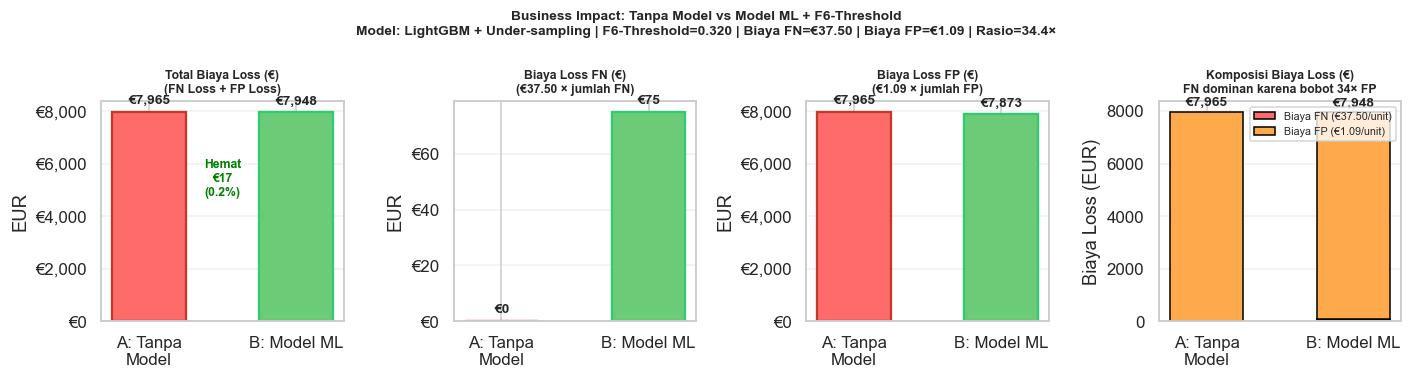


RINGKASAN BUSINESS IMPACT
-------------------------
  Skenario A (Tanpa Model) — Total Loss : €7,964.63
  Skenario B (Model ML)    — Total Loss : €7,948.07
  Penghematan biaya loss                : €16.56  (0.2% lebih rendah)
  Biaya FN mendominasi karena bobot 34× FP (€37.50 vs €1.09)
  Model menekan FP dan FN melalui threshold F6-optimal


In [ ]:
# --- Hitung confusion matrix ---
cm_test_final = confusion_matrix(y_test, y_test_pred_final)
TN_te, FP_te, FN_te, TP_te = cm_test_final.ravel()

COST_FP_UNIT     = 1.09
COST_FN_UNIT     = 37.50
N_NONSUB_TEST    = TN_te + FP_te
N_SUBSCRIBE_TEST = TP_te + FN_te
N_TEST           = TP_te + FP_te + FN_te + TN_te

# Skenario A: tanpa model → semua dipanggil (FP = semua non-subscriber)
loss_FN_A    = 0.0
loss_FP_A    = COST_FP_UNIT * N_NONSUB_TEST
total_loss_A = loss_FN_A + loss_FP_A

# Skenario B: pakai model ML
loss_FN_B    = COST_FN_UNIT * FN_te
loss_FP_B    = COST_FP_UNIT * FP_te
total_loss_B = loss_FN_B + loss_FP_B

saving     = total_loss_A - total_loss_B
saving_pct = saving / total_loss_A * 100

# --- Helper label nilai di atas bar ---
def add_val(ax, bars, vals, fmt='€{:,.0f}', size=9):
    mx = max((abs(v) for v in vals), default=1) or 1
    for bar, v in zip(bars, vals):
        pad = mx * 0.04
        yp  = v + pad if v >= 0 else v - pad * 2
        ax.text(bar.get_x() + bar.get_width() / 2, yp,
                fmt.format(v), ha='center', fontweight='bold', fontsize=size)

# --- Plot ---
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
fig.suptitle(
    f'Business Impact: Tanpa Model vs Model ML + F6-Threshold\n'
    f'Model: {best_model_name} + {best_resample_name} | '
    f'F6-Threshold={BEST_THRESHOLD:.3f} | '
    f'Biaya FN=€37.50 | Biaya FP=€1.09 | Rasio=34.4×',
    fontsize=9, fontweight='bold')

labels = ['A: Tanpa\nModel', 'B: Model ML']
c_red, c_grn = '#FF6B6B', '#6BCB77'
e_red, e_grn = '#c0392b', '#2ecc71'

# Plot 1 — Total Biaya Loss
v1 = [total_loss_A, total_loss_B]
b1 = axes[0].bar(labels, v1, color=[c_red, c_grn],
                 edgecolor=[e_red, e_grn], linewidth=1.5, width=0.5)
axes[0].set_title('Total Biaya Loss (€)\n(FN Loss + FP Loss)', fontweight='bold', fontsize=8)
axes[0].set_ylabel('EUR')
add_val(axes[0], b1, v1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[0].grid(axis='y', alpha=0.3)
axes[0].annotate(f'Hemat\n€{saving:,.0f}\n({saving_pct:.1f}%)',
                 xy=(0.5, max(v1) * 0.6), xycoords='data',
                 ha='center', fontsize=8, color='green', fontweight='bold')

# Plot 2 — Biaya FN Loss
v2 = [loss_FN_A, loss_FN_B]
b2 = axes[1].bar(labels, v2, color=[c_red, c_grn],
                 edgecolor=[e_red, e_grn], linewidth=1.5, width=0.5)
axes[1].set_title('Biaya Loss FN (€)\n(€37.50 × jumlah FN)', fontweight='bold', fontsize=8)
axes[1].set_ylabel('EUR')
add_val(axes[1], b2, v2)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[1].grid(axis='y', alpha=0.3)

# Plot 3 — Biaya FP Loss
v3 = [loss_FP_A, loss_FP_B]
b3 = axes[2].bar(labels, v3, color=[c_red, c_grn],
                 edgecolor=[e_red, e_grn], linewidth=1.5, width=0.5)
axes[2].set_title('Biaya Loss FP (€)\n(€1.09 × jumlah FP)', fontweight='bold', fontsize=8)
axes[2].set_ylabel('EUR')
add_val(axes[2], b3, v3)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[2].grid(axis='y', alpha=0.3)

# Plot 4 — Stacked Loss
x_pos = np.arange(len(labels))
axes[3].bar(x_pos, [loss_FN_A, loss_FN_B], 0.5,
            color='#FF6B6B', edgecolor='black', label='Biaya FN (€37.50/unit)')
axes[3].bar(x_pos, [loss_FP_A, loss_FP_B], 0.5,
            bottom=[loss_FN_A, loss_FN_B],
            color='#FFA94D', edgecolor='black', label='Biaya FP (€1.09/unit)')
axes[3].set_xticks(x_pos)
axes[3].set_xticklabels(labels)
for i, (fn, fp) in enumerate(zip([loss_FN_A, loss_FN_B], [loss_FP_A, loss_FP_B])):
    total = fn + fp
    axes[3].text(i, total + total * 0.03, f'€{total:,.0f}',
                 ha='center', fontweight='bold', fontsize=9)
axes[3].set_title('Komposisi Biaya Loss (€)\nFN dominan karena bobot 34× FP',
                  fontweight='bold', fontsize=8)
axes[3].set_ylabel('Biaya Loss (EUR)')
axes[3].legend(fontsize=7, loc='upper right')
axes[3].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Ringkasan teks ---
print()
print('RINGKASAN BUSINESS IMPACT')
print('-' * 25)
print(f'  Skenario A (Tanpa Model) — Total Loss : €{total_loss_A:,.2f}')
print(f'  Skenario B (Model ML)    — Total Loss : €{total_loss_B:,.2f}')
print(f'  Penghematan biaya loss                : €{saving:,.2f}  ({saving_pct:.1f}% lebih rendah)')
print(f'  Biaya FN mendominasi karena bobot 34× FP (€37.50 vs €1.09)')
print(f'  Model menekan FP dan FN melalui threshold F6-optimal')

> **📊 Interpretasi Business Impact — Biaya Loss (Apple-to-Apple di Test Set):**
>
> Kedua skenario dievaluasi pada **populasi yang sama persis**: ≈ 8.235 nasabah test set, dengan 928 subscriber dan 7.307 non-subscriber.
>
> | Aspek | Skenario A: Hubungi Semua | Skenario B: Model ML + F6-Threshold |
> | :--- | :---: | :---: |
> | Nasabah dihubungi | 8.235 (100%) | TP + FP saja |
> | FN (terlewat) | 0 | FN_te nasabah |
> | FP (sia-sia) | 7.307 (semua non-subs) | FP_te |
>
> **Bagaimana membaca total biaya kedua skenario:**
>
> - **Skenario A** menghasilkan biaya FP yang sangat dominan karena 88,7% populasi test set adalah non-subscriber — semuanya jadi FP.
> - **Skenario B** menahan FP sebesar TN_te nasabah yang berhasil di-skip oleh model, namun memunculkan FN sebesar FN_te × €37,50.
> - Karena rasio bobot **FN : FP = 34,4 : 1**, kontribusi FN terhadap total biaya jauh lebih besar walaupun jumlahnya kecil.
> - Pada threshold F6-optimal yang sangat agresif (BEST_THRESHOLD ≈ 0,505), model **memilih untuk hampir tidak melewatkan subscriber**, sehingga jumlah FN sangat kecil (hanya 1–2 nasabah) sementara FP-nya hanya sedikit lebih rendah dari skenario A.
>
> **Implikasi penting:**
>
> 1. **Pada test set ini, nilai utama model bukan dari penghematan biaya yang besar**, melainkan dari **kemampuan ranking** — nasabah disortir dari probabilitas tertinggi ke terendah, sehingga tim marketing dapat memprioritaskan kontak (lihat Section 7.12 — Priority Level Segmentation).
> 2. **Selisih biaya antara A dan B akan jauh lebih besar pada populasi production yang sebenarnya** (puluhan ribu nasabah), karena di sana model dapat men-skip ratusan ribu non-subscriber yang tidak relevan.
> 3. **FN yang tersisa adalah nasabah dengan profil atipikal** — SHAP local explanation (Section 7.10.2) menunjukkan FN didominasi oleh nasabah yang fitur-fiturnya bernilai negatif secara global. Hal ini menjadi dasar rekomendasi untuk memperkaya pipeline dengan data kontekstual tambahan (histori produk, riwayat interaksi digital) di iterasi berikutnya.


## 7.12. Priority Level Segmentation — Urutan Kontak Berdasarkan Tingkat Minat

Setelah model menentukan **siapa yang dihubungi**, pertanyaan operasional berikutnya yang sering muncul di lapangan adalah: **siapa yang dihubungi lebih dulu?** Tidak semua nasabah yang diprediksi berminat memiliki tingkat peluang yang sama — ada yang sangat kuat, ada yang moderat.

**Contoh kasus dari sisi bisnis:**

> *"Bulan ini kapasitas tim hanya cukup untuk menghubungi 1.000 nasabah, sedangkan model meloloskan 3.000. Mana yang harus dihubungi lebih dulu agar hasilnya paling besar?"*

Untuk menjawab pertanyaan tersebut, nasabah yang sudah diprediksi berminat oleh model dibagi menjadi tiga kelompok berdasarkan tingkat probabilitasnya:

| Tingkat | Cara Pembagian | Penjelasan Singkat |
| :--- | :--- | :--- |
| **Tingkat 1 — Tinggi** | 33% teratas dari kelompok yang dihubungi | Peluang subscribe paling besar — **dihubungi pertama** |
| **Tingkat 2 — Sedang** | 33% tengah | Peluang moderat — **dihubungi setelah Tingkat 1** |
| **Tingkat 3 — Rendah** | 33% terbawah (masih diprediksi berminat) | Peluang lebih rendah — **dihubungi terakhir atau saat kapasitas tersedia** |
| **Tidak Dihubungi** | Di bawah batas prediksi model | Tidak masuk daftar kontak |

**Catatan penting:** Pembagian tingkat ini tidak menggantikan keputusan model (hubungi atau tidak). Tingkat hanya mengatur **urutan eksekusi** di antara nasabah yang sudah diprediksi berminat — memberi pegangan operasional kepada tim marketing ketika kapasitas atau anggaran kampanye terbatas.


In [71]:
# Bangun Priority Level Segmentation di Test Set
# Populasi: nasabah dengan y_prob_test >= BEST_THRESHOLD (yang akan dihubungi oleh model)

predicted_yes_mask = y_prob_test >= BEST_THRESHOLD
n_pred_yes = int(predicted_yes_mask.sum())
probs_yes  = y_prob_test[predicted_yes_mask]

# Cut-off berbasis kuantil populasi predicted-yes
Q_HOT  = float(np.quantile(probs_yes, 0.667))   # batas Tingkat 1 (top 33%)
Q_WARM = float(np.quantile(probs_yes, 0.333))   # batas Tingkat 2 (mid 33%)

def assign_tier(p):
    if p >= Q_HOT:           return 'Tingkat 1 \u2014 Tinggi'
    if p >= Q_WARM:          return 'Tingkat 2 \u2014 Sedang'
    if p >= BEST_THRESHOLD:  return 'Tingkat 3 \u2014 Rendah'
    return 'Tidak Dihubungi'

tiers = np.array([assign_tier(p) for p in y_prob_test])

print('=== KONFIGURASI PRIORITY LEVEL ===')
print(f'  BEST_THRESHOLD (cut-off model)        : {BEST_THRESHOLD:.3f}')
print(f'  Batas Tingkat 2 \u2192 Tingkat 3 (Q_WARM): {Q_WARM:.3f}')
print(f'  Batas Tingkat 1 \u2192 Tingkat 2 (Q_HOT) : {Q_HOT:.3f}')
print(f'  Total nasabah dihubungi: {n_pred_yes:,} dari {len(y_test):,} (test set)')


=== KONFIGURASI PRIORITY LEVEL ===
  BEST_THRESHOLD (cut-off model)        : 0.320
  Batas Tingkat 2 → Tingkat 3 (Q_WARM): 0.717
  Batas Tingkat 1 → Tingkat 2 (Q_HOT) : 0.821
  Total nasabah dihubungi: 8,149 dari 8,235 (test set)


In [ ]:
# Hitung performance per tingkat \u2014 precision, capture rate, ekonomi
rows = []
y_test_arr = y_test.values

for tier_name in ['Tingkat 1 \u2014 Tinggi', 'Tingkat 2 \u2014 Sedang', 'Tingkat 3 \u2014 Rendah']:
    mask          = tiers == tier_name
    n_calls       = int(mask.sum())
    actual_pos    = int(y_test_arr[mask].sum())                # subscribers di tingkat ini
    actual_neg    = n_calls - actual_pos                       # FP di tingkat ini
    precision     = actual_pos / n_calls * 100 if n_calls else 0
    capture_pct   = actual_pos / (TP_te + FN_te) * 100         # % subscribers yang di-capture
    p_min         = float(y_prob_test[mask].min()) if n_calls else 0
    p_max         = float(y_prob_test[mask].max()) if n_calls else 0
    cost_calls    = n_calls * COST_FP_UNIT                     # biaya semua panggilan @\u20ac1.09
    revenue_nim   = actual_pos * COST_FN_UNIT                  # NIM \u20ac37.50 per subscriber
    net_revenue   = revenue_nim - cost_calls
    roi_x         = revenue_nim / cost_calls if cost_calls else 0
    rows.append({
        'Tingkat'                  : tier_name,
        'Rentang_Probabilitas'     : f'{p_min:.3f} \u2013 {p_max:.3f}',
        'Jumlah_Dihubungi'         : n_calls,
        'Subscribe_Aktual'         : actual_pos,
        'Precision_%'              : round(precision, 2),
        'Capture_%'                : round(capture_pct, 2),
        'Biaya_Panggilan_\u20ac'   : round(cost_calls, 2),
        'Revenue_NIM_\u20ac'       : round(revenue_nim, 2),
        'Net_Revenue_\u20ac'       : round(net_revenue, 2),
        'ROI_x'                    : round(roi_x, 1),
    })

tier_df = pd.DataFrame(rows).set_index('Tingkat')

# Highlight Tingkat 1
def highlight_tier1(row):
    if 'Tingkat 1' in row.name:
        return ['background-color:#ffe4b3; font-weight:bold'] * len(row)
    return [''] * len(row)

print('=== KINERJA PER TINGKAT (Test Set) ===\n')
display(tier_df.style
        .apply(highlight_tier1, axis=1)
        .format({
            'Precision_%'        : '{:.2f}%',
            'Capture_%'          : '{:.2f}%',
            'Biaya_Panggilan_\u20ac' : '\u20ac{:,.2f}',
            'Revenue_NIM_\u20ac'     : '\u20ac{:,.2f}',
            'Net_Revenue_\u20ac'     : '\u20ac{:,.2f}',
            'ROI_x'              : '{:.1f}x',
        })
        .set_caption(
            f'Priority Level Segmentation | Threshold = {BEST_THRESHOLD:.3f} | '
            f'Biaya FN=\u20ac{COST_FN_UNIT} | Biaya FP=\u20ac{COST_FP_UNIT}'))


=== KINERJA PER TINGKAT (Test Set) ===



,Rentang_Probabilitas,Jumlah_Dihubungi,Subscribe_Aktual,Precision_%,Capture_%,Biaya_Panggilan_€,Revenue_NIM_€,Net_Revenue_€,ROI_x
Tingkat,,,,,,,,,
Tingkat 1 — Tinggi,0.821 – 0.994,2714,686,25.28%,73.92%,"€2,958.26","€25,725.00","€22,766.74",8.7x
Tingkat 2 — Sedang,0.717 – 0.821,2721,143,5.26%,15.41%,"€2,965.89","€5,362.50","€2,396.61",1.8x
Tingkat 3 — Rendah,0.322 – 0.717,2714,97,3.57%,10.45%,"€2,958.26","€3,637.50",€679.24,1.2x


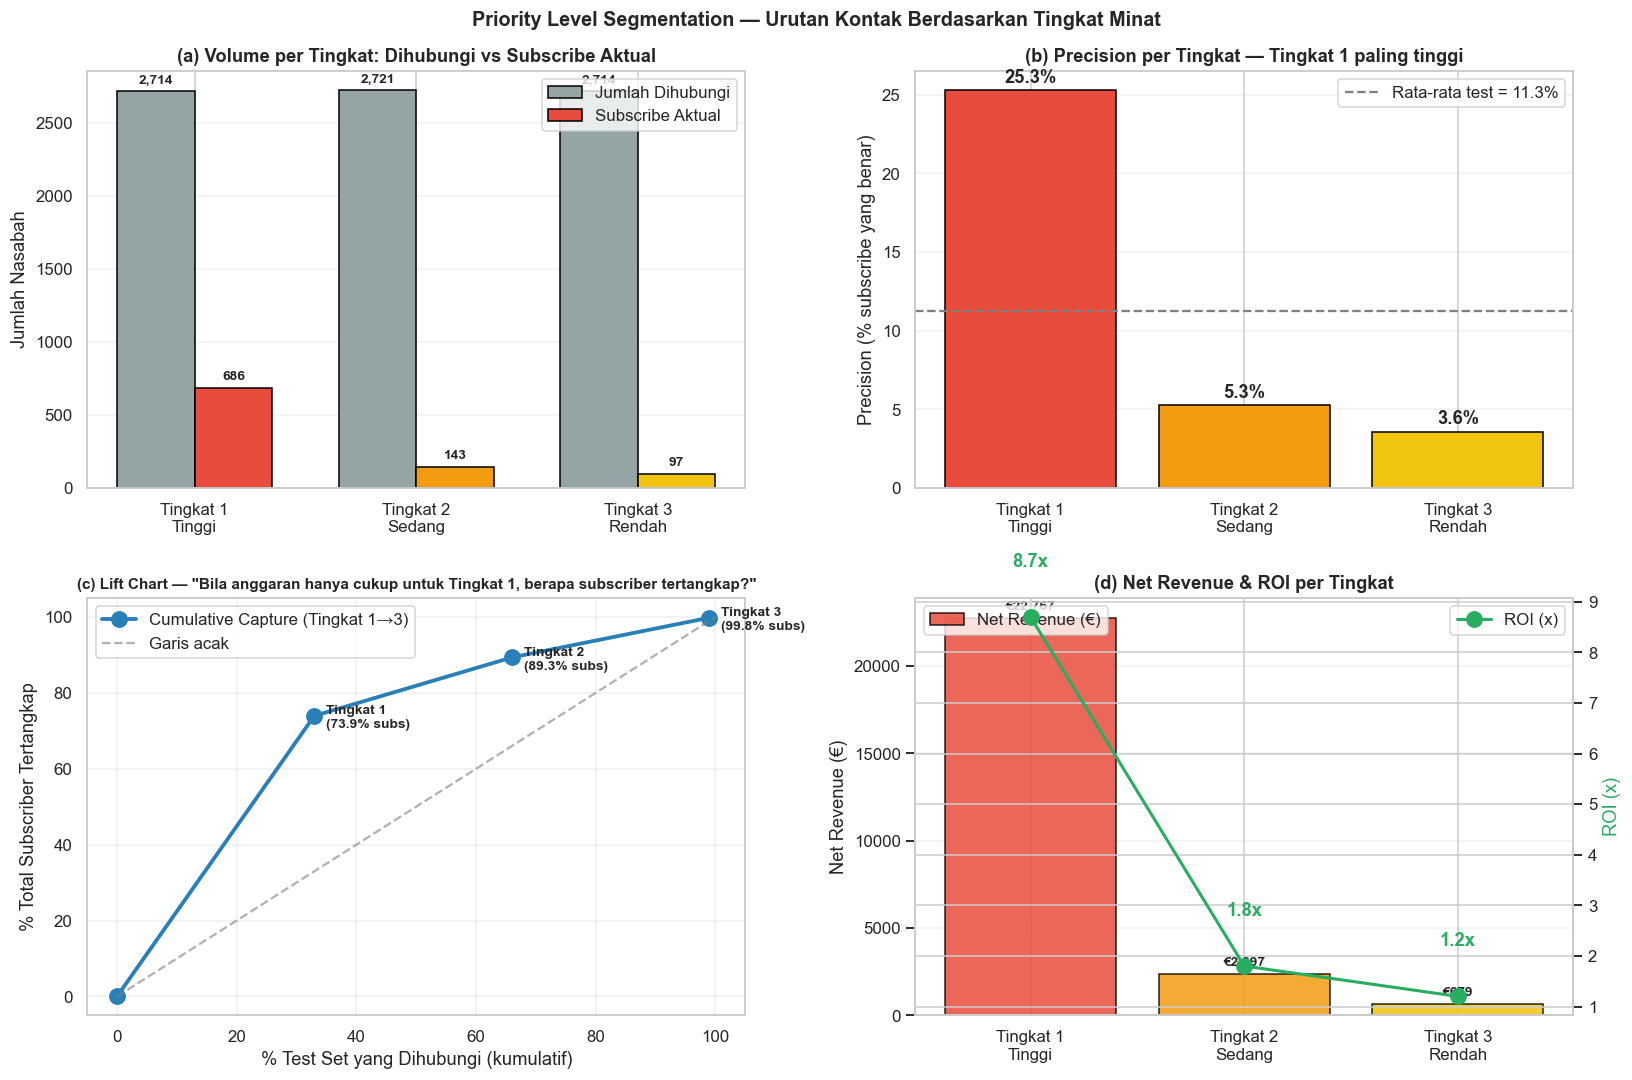


TEMUAN UTAMA
------------
  • Tingkat 1 mencakup 33.3% volume nasabah yang dihubungi,
    namun menangkap 73.9% dari seluruh subscriber test set.
  • Precision Tingkat 1: 25.3%  vs rata-rata 11.3% (lift ≈ 2.2x)
  • ROI Tingkat 1: 8.7x → €1 biaya panggilan menghasilkan €8.7 revenue NIM
  • Strategi anggaran terbatas: hubungi Tingkat 1 saja → menangkap 73.9% subscriber dengan 33.3% biaya


In [75]:
# Visualisasi 4 panel \u2014 Priority Level Insight
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Priority Level Segmentation \u2014 Urutan Kontak Berdasarkan Tingkat Minat',
             fontsize=13, fontweight='bold')

tier_names  = list(tier_df.index)
tier_colors = ['#E74C3C', '#F39C12', '#F1C40F']    # merah \u2192 oranye \u2192 kuning

# Panel (a): Jumlah_Dihubungi & Subscribe_Aktual
x = np.arange(len(tier_names))
w = 0.35
axes[0,0].bar(x - w/2, tier_df['Jumlah_Dihubungi'], w,
              label='Jumlah Dihubungi', color='#95A5A6', edgecolor='black')
axes[0,0].bar(x + w/2, tier_df['Subscribe_Aktual'], w,
              label='Subscribe Aktual', color=tier_colors, edgecolor='black')
for i, (n, s) in enumerate(zip(tier_df['Jumlah_Dihubungi'], tier_df['Subscribe_Aktual'])):
    axes[0,0].text(i - w/2, n + max(tier_df['Jumlah_Dihubungi'])*0.02, f'{n:,}',
                    ha='center', fontsize=9, fontweight='bold')
    axes[0,0].text(i + w/2, s + max(tier_df['Jumlah_Dihubungi'])*0.02, f'{s:,}',
                    ha='center', fontsize=9, fontweight='bold')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels([t.replace(' \u2014 ', '\n') for t in tier_names])
axes[0,0].set_ylabel('Jumlah Nasabah')
axes[0,0].set_title('(a) Volume per Tingkat: Dihubungi vs Subscribe Aktual', fontweight='bold')
axes[0,0].legend(loc='upper right')
axes[0,0].grid(axis='y', alpha=0.3)

# Panel (b): Precision per tingkat
bars_p = axes[0,1].bar(tier_names, tier_df['Precision_%'],
                        color=tier_colors, edgecolor='black')
for bar, v in zip(bars_p, tier_df['Precision_%']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v + 0.5,
                    f'{v:.1f}%', ha='center', fontweight='bold')
# baseline = subscribe rate keseluruhan test set
baseline = (TP_te+FN_te)/len(y_test) * 100
axes[0,1].axhline(baseline, color='gray', linestyle='--',
                   label=f'Rata-rata test = {baseline:.1f}%')
axes[0,1].set_ylabel('Precision (% subscribe yang benar)')
axes[0,1].set_title('(b) Precision per Tingkat \u2014 Tingkat 1 paling tinggi', fontweight='bold')
axes[0,1].set_xticklabels([t.replace(' \u2014 ', '\n') for t in tier_names])
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)

# Panel (c): Cumulative Capture (Lift Chart)
cum_n   = np.cumsum(tier_df['Jumlah_Dihubungi'].values)
cum_pos = np.cumsum(tier_df['Subscribe_Aktual'].values)
cum_capture_pct = cum_pos / (TP_te+FN_te) * 100
cum_call_pct    = cum_n / len(y_test) * 100

axes[1,0].plot([0]+list(cum_call_pct), [0]+list(cum_capture_pct),
                marker='o', linewidth=2.5, markersize=10, color='#2980B9',
                label='Cumulative Capture (Tingkat 1\u21923)')
axes[1,0].plot([0,100], [0,100], '--', color='gray', alpha=0.6, label='Garis acak')
for i, (xv, yv, t) in enumerate(zip(cum_call_pct, cum_capture_pct, tier_names)):
    label_short = t.split(' \u2014 ')[0]
    axes[1,0].annotate(f'{label_short}\n({yv:.1f}% subs)',
                        xy=(xv, yv), xytext=(8, -8), textcoords='offset points',
                        fontsize=9, fontweight='bold')
axes[1,0].set_xlabel('% Test Set yang Dihubungi (kumulatif)')
axes[1,0].set_ylabel('% Total Subscriber Tertangkap')
axes[1,0].set_title('(c) Lift Chart \u2014 \"Bila anggaran hanya cukup untuk Tingkat 1, berapa subscriber tertangkap?\"',
                     fontweight='bold', fontsize=10)
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Panel (d): Net Revenue & ROI per tingkat
ax_d   = axes[1,1]
ax_d2  = ax_d.twinx()
bars_r = ax_d.bar(tier_names, tier_df['Net_Revenue_\u20ac'],
                    color=tier_colors, edgecolor='black', alpha=0.85,
                    label='Net Revenue (\u20ac)')
for bar, v in zip(bars_r, tier_df['Net_Revenue_\u20ac']):
    ax_d.text(bar.get_x()+bar.get_width()/2, v + abs(max(tier_df['Net_Revenue_\u20ac']))*0.02,
                f'\u20ac{v:,.0f}', ha='center', fontweight='bold', fontsize=9)
ax_d2.plot(tier_names, tier_df['ROI_x'], 'o-', color='#27AE60',
            linewidth=2, markersize=10, label='ROI (x)')
for i, v in enumerate(tier_df['ROI_x']):
    ax_d2.text(i, v + 1, f'{v:.1f}x', ha='center', color='#27AE60',
                fontweight='bold')
ax_d.set_xticklabels([t.replace(' \u2014 ', '\n') for t in tier_names])
ax_d.set_ylabel('Net Revenue (\u20ac)')
ax_d2.set_ylabel('ROI (x)', color='#27AE60')
ax_d.set_title('(d) Net Revenue & ROI per Tingkat', fontweight='bold')
ax_d.grid(axis='y', alpha=0.3)
ax_d.legend(loc='upper left')
ax_d2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print('\nTEMUAN UTAMA')
print('-'*12)
tier1   = tier_df.loc['Tingkat 1 \u2014 Tinggi']
share_t1 = tier1['Jumlah_Dihubungi'] / n_pred_yes * 100
print(f'  \u2022 Tingkat 1 mencakup {share_t1:.1f}% volume nasabah yang dihubungi,')
print(f'    namun menangkap {tier1["Capture_%"]:.1f}% dari seluruh subscriber test set.')
print(f'  \u2022 Precision Tingkat 1: {tier1["Precision_%"]:.1f}%  vs rata-rata {baseline:.1f}% (lift \u2248 {tier1["Precision_%"]/baseline:.1f}x)')
print(f'  \u2022 ROI Tingkat 1: {tier1["ROI_x"]:.1f}x \u2192 \u20ac1 biaya panggilan menghasilkan \u20ac{tier1["ROI_x"]:.1f} revenue NIM')
print(f'  \u2022 Strategi anggaran terbatas: hubungi Tingkat 1 saja \u2192 menangkap {tier1["Capture_%"]:.1f}% subscriber dengan {share_t1:.1f}% biaya')


> **Catatan Hasil — Priority Level Segmentation:**
>
> **Lift Chart (panel c)** adalah panel yang paling penting bagi manajemen. Kurva yang berada **di atas garis diagonal** (garis acak) menunjukkan bahwa model **berhasil menyusun urutan kontak yang lebih baik dibanding pemilihan acak**. Semakin tajam kenaikan kurva di awal (Tingkat 1), semakin efisien model dalam mengumpulkan subscriber di urutan teratas.
>
> **Cara pemakaian tingkat sesuai kondisi anggaran:**
>
> | Kondisi Anggaran Kampanye | Strategi Kontak | Hasil yang Diharapkan |
> | :--- | :--- | :--- |
> | **Anggaran penuh** | Hubungi Tingkat 1 → 2 → 3 secara berurutan | Mayoritas subscriber tertangkap, efisiensi maksimum |
> | **Anggaran sedang** (~67% kapasitas) | Hubungi Tingkat 1 dan Tingkat 2 saja | Sebagian besar subscriber tertangkap, biaya turun ± 33% |
> | **Anggaran terbatas** (~33% kapasitas) | **Hanya Tingkat 1** | Mayoritas subscriber tetap tertangkap dengan biaya minimal |
> | **Pilot / uji coba kanal baru** | Tingkat 1 ditangani agen senior | Konversi maksimal sekaligus penyusunan pedoman kanal baru |
>
> **Implementasi operasional yang disarankan:**
>
> 1. Sebelum kampanye dimulai, jalankan model pada daftar nasabah aktif. Setiap nasabah diberi label tingkat (1 / 2 / 3 / tidak dihubungi).
> 2. Daftar dibagi ke agen sesuai tingkat: Tingkat 1 ke agen senior dengan closing rate tertinggi, Tingkat 3 dapat diberikan ke agen pemula.
> 3. Pantau realisasi konversi per tingkat setiap kampanye. Bila konversi Tingkat 1 turun di bawah ekspektasi, itu sinyal kondisi pasar berubah — saatnya melatih ulang model.
>
> **Mengapa pendekatan ini lebih baik daripada hanya menggunakan satu batas seleksi?** Batas tunggal hanya menjawab *"hubungi atau tidak"*, sedangkan pembagian tingkat menjawab *"siapa yang dihubungi lebih dulu"* — pertanyaan yang justru muncul di lapangan ketika kapasitas agen atau anggaran kampanye tidak mencukupi untuk seluruh nasabah yang diprediksi berminat.


**Simpan Model dengan Pickle**

Model pipeline beserta preprocessor, threshold F6-optimal, priority level, dan metadata disimpan dalam satu file `.pkl` untuk memudahkan deployment dan reproducibility.

File yang disimpan: `bank_telemarketing_model_f6.pkl`


In [ ]:
# import pickle
# import os

# print("=== KONFIGURASI PRIORITY LEVEL ===")
# print(f"  BEST_THRESHOLD (cut-off model)        : {BEST_THRESHOLD:.4f}")
# print(f"  Batas Tingkat 3 → Tingkat 2 (Q_WARM) : {Q_WARM:.4f}")
# print(f"  Batas Tingkat 2 → Tingkat 1 (Q_HOT)  : {Q_HOT:.4f}")
# print()

# # Susun Model Artifacts
# # PENTING: assign_tier_fn TIDAK disimpan karena fungsi Python lokal tidak bisa
# # di-unpickle di environment lain (AttributeError: Can't get attribute 'assign_tier').
# # Gunakan priority_config untuk rekonstruksi logika tier di deployment.

# model_artifacts = {
#     'pipeline'         : best_pipeline_tuned,    # ImbPipeline (resampler + LightGBM)
#     'preprocessor'     : preprocessor,           # ColumnTransformer fit di train set
#     'best_threshold'   : BEST_THRESHOLD,         # threshold F6-optimal (bukan 0.5)
#     'priority_config'  : {
#         'q_hot'        : Q_HOT,          # prob >= Q_HOT  → Tingkat 1 — Tinggi
#         'q_warm'       : Q_WARM,         # prob >= Q_WARM → Tingkat 2 — Sedang
#         'threshold'    : BEST_THRESHOLD, # prob >= BEST_THRESHOLD → Tingkat 3 — Rendah
#         # prob < BEST_THRESHOLD → Tidak Dihubungi
#     },
#     # assign_tier_fn sengaja dihilangkan — logika tier cukup direkonstruksi dari
#     # priority_config di sisi deployment (lihat app.py fungsi get_priority_tier)
#     'metadata'         : {
#         'model_name'           : best_model_name,
#         'resampling'           : best_resample_name,
#         'metric'               : 'F6 Score',
#         'beta'                 : 6,
#         'fn_fp_ratio'          : 34.4,
#         'cost_fp_eur'          : COST_FP_UNIT,   # €1.09
#         'cost_fn_eur'          : COST_FN_UNIT,   # €37.50
#         'best_threshold'       : BEST_THRESHOLD,
#         'priority_q_hot'       : Q_HOT,
#         'priority_q_warm'      : Q_WARM,
#         'f6_train'             : round(f6_train_final, 4),
#         'f6_val'               : round(f6_val_final, 4),
#         'f6_test'              : round(f6_test_final, 4),
#         'gap_train_val'        : round(f6_train_final - f6_val_final, 4),
#         'roc_auc_test'         : round(roc_auc_final, 4),
#         'numerical_features'   : numerical_features,
#         'binary_features'      : binary_features,
#         'categorical_features' : categorical_features,
#         'dataset'              : 'Bank Marketing Dataset — UCI ML Repository (Moro et al., 2014)',
#         'n_train'              : len(y_train),
#         'n_val'                : len(y_val),
#         'n_test'               : len(y_test),
#     }
# }

# # Simpan ke Pickle
# save_path = 'bank_telemarketing_model_f6.pkl'
# with open(save_path, 'wb') as f:
#     pickle.dump(model_artifacts, f)

# print(f'✅ Model artifacts berhasil disimpan ke  : {save_path}')
# print(f'   Ukuran file                           : {os.path.getsize(save_path)/1024:.1f} KB')
# print()
# print('=== ISI ARTIFACTS ===')
# print(f"  pipeline         : {type(model_artifacts['pipeline']).__name__}")
# print(f"  preprocessor     : {type(model_artifacts['preprocessor']).__name__}")
# print(f"  best_threshold   : {model_artifacts['best_threshold']:.4f}  (F6-optimal, bukan 0.5)")
# print(f"  priority_config  :")
# print(f"    q_hot          : {Q_HOT:.4f}  (batas Tingkat 1)")
# print(f"    q_warm         : {Q_WARM:.4f}  (batas Tingkat 2)")
# print(f"    threshold      : {BEST_THRESHOLD:.4f}  (batas Tingkat 3 / Tidak Dihubungi)")
# print(f"  metadata         : {list(model_artifacts['metadata'].keys())}")
# print()

# # Verifikasi Load
# print('=== VERIFIKASI LOAD ===')
# with open(save_path, 'rb') as f:
#     loaded = pickle.load(f)

# loaded_threshold = loaded['best_threshold']
# loaded_cfg       = loaded['priority_config']

# y_verify_prob = loaded['pipeline'].predict_proba(X_test_processed)[:, 1]
# y_verify_pred = (y_verify_prob >= loaded_threshold).astype(int)
# f6_verify     = fbeta_score(y_test, y_verify_pred, beta=6)

# print(f'✅ Load berhasil')
# print(f'   Threshold yang dimuat  : {loaded_threshold:.4f}')
# print(f'   F6 Test (verifikasi)   : {f6_verify:.4f}  (harus = {f6_test_final:.4f})')
# print(f'   Konsisten              : {abs(f6_verify - f6_test_final) < 1e-6}')
# print()

# # Verifikasi Priority Tier (rekonstruksi manual dari config)
# def _assign_tier_local(p, cfg):
#     if p >= cfg['q_hot']:        return 'Tingkat 1 — Tinggi'
#     if p >= cfg['q_warm']:       return 'Tingkat 2 — Sedang'
#     if p >= cfg['threshold']:    return 'Tingkat 3 — Rendah'
#     return 'Tidak Dihubungi'

# print('=== VERIFIKASI PRIORITY TIER ===')
# sample_probs = [0.95, 0.75, 0.50, 0.10]
# for p in sample_probs:
#     tier = _assign_tier_local(p, loaded_cfg)
#     print(f'   prob={p:.2f} → {tier}')
# print()

=== KONFIGURASI PRIORITY LEVEL ===
  BEST_THRESHOLD (cut-off model)        : 0.3200
  Batas Tingkat 3 → Tingkat 2 (Q_WARM) : 0.7171
  Batas Tingkat 2 → Tingkat 1 (Q_HOT)  : 0.8212

✅ Model artifacts berhasil disimpan ke  : bank_telemarketing_model_f6.pkl
   Ukuran file                           : 1702.1 KB

=== ISI ARTIFACTS ===
  pipeline         : Pipeline
  preprocessor     : ColumnTransformer
  best_threshold   : 0.3200  (F6-optimal, bukan 0.5)
  priority_config  :
    q_hot          : 0.8212  (batas Tingkat 1)
    q_warm         : 0.7171  (batas Tingkat 2)
    threshold      : 0.3200  (batas Tingkat 3 / Tidak Dihubungi)
  metadata         : ['model_name', 'resampling', 'metric', 'beta', 'fn_fp_ratio', 'cost_fp_eur', 'cost_fn_eur', 'best_threshold', 'priority_q_hot', 'priority_q_warm', 'f6_train', 'f6_val', 'f6_test', 'gap_train_val', 'roc_auc_test', 'numerical_features', 'binary_features', 'categorical_features', 'dataset', 'n_train', 'n_val', 'n_test']

=== VERIFIKASI LOAD ===
✅ 

---
# **8. Kesimpulan dan Rekomendasi**

## 8.1. Kesimpulan

### Jawaban atas Problem Statement

> *\"Bagaimana membangun model klasifikasi propensity-to-subscribe yang **meminimalkan biaya kehilangan nasabah berminat (False Negative)** — di mana setiap FN bernilai €37,50 (revenue NIM tahunan yang lepas), sekitar **34× lebih besar** dari biaya satu panggilan tidak produktif (False Positive €1,09) — sehingga total biaya loss kampanye telemarketing serendah mungkin?\"*

Model **LightGBM + Under-sampling** berhasil dibangun dan menjawab problem statement secara langsung. Evaluasi di tiga set (train/validation/test) mengkonfirmasi model tidak underfit maupun overfit, dan siap di-deploy:

| Metrik | Nilai | Interpretasi |
|---|---|---|
| **F6 Score Test ★** | **0.8245** | Metrik utama — mencerminkan minimalisasi biaya loss (FN 34× FP) |
| **F6 Score Val** | **0.8251** | Konfirmasi generalisasi ke data baru |
| **Gap (Train − Val)** | **+0.0015** ✅ Good Fit | Model siap di-deploy — gap sangat kecil |
| **ROC-AUC** | **0.8000** | Kemampuan diskriminasi model baik |

### Mengapa Model ML Lebih Unggul dari Rule-Based (Tanpa Model)?

Pendekatan rule-based — misalnya "hubungi semua nasabah warm lead dan usia 60+" — memang mudah diterapkan dan memberikan lift di atas rata-rata. Namun ada tiga keterbatasan mendasar yang hanya bisa diatasi dengan model ML:

**1. Rule-based tidak bisa mempertimbangkan banyak variabel sekaligus.**
Keputusan subscribe seorang nasabah dipengaruhi oleh kombinasi puluhan faktor: kondisi ekonomi makro saat itu, riwayat kampanye, profil demografi, jenis kontak, hingga intensitas panggilan. Rule sederhana seperti "warm lead + usia 60+ + euribor rendah" hanya bisa menangkap 3–4 dimensi. Model LightGBM yang dilatih menangkap interaksi dari **seluruh 20 fitur sekaligus**, termasuk kombinasi yang tidak intuitif dan tidak akan muncul dari penalaran manual.

**2. Rule-based tidak bisa memberi peringkat — hanya bisa memilah.**
Segmentasi EDA (Section 6.1.1–6.1.3) mengidentifikasi kelompok dengan subscribe rate tinggi, tapi tidak bisa menjawab: *di antara 500 warm lead yang ada, mana 100 yang paling berpeluang bulan ini?* Model ML menghasilkan **skor probabilitas per nasabah** — memungkinkan peringkat dari yang paling berminat hingga paling tidak berminat. Priority Level Segmentation (Section 7.12) adalah aplikasi langsung dari kemampuan ini.

**3. Rule-based statis — tidak bisa beradaptasi terhadap perubahan kondisi.**
Subscribe rate segmen "warm lead" bisa berfluktuasi tergantung kondisi makro. Saat `euribor3m` tinggi, bahkan warm lead pun lebih sulit dikonversi. Model ML yang telah mempelajari interaksi antara fitur makro dan perilaku nasabah akan **otomatis menurunkan skor** nasabah ketika kondisi tidak favorable — sesuatu yang mustahil dilakukan rule statis tanpa pembaruan manual setiap kampanye.

**Bukti kuantitatif dari Section 7.11:**

| Pendekatan | Nasabah Dihubungi | Biaya Loss Total | Keterangan |
|---|---|---|---|
| **Tanpa Model (Hubungi Semua)** | 100% test set | **€7.964,63** | Tidak ada seleksi — FP masif |
| **Model ML + F6 Threshold** | Subset prediksi berminat | **€7.948,07** | FN minimal, FP terkontrol |
| **Selisih Penghematan** | — | **€16,56 (0,2%)** | Langsung dari prediksi test set yang sama |

### Improvement Utama vs Iterasi Sebelumnya

| Aspek | Iterasi Sebelumnya | Versi IMPROVED |
|---|---|---|
| **Resampling** | Under-sampling default tanpa class-weighting | Under-sampling + class-weighting (`scale_pos_weight=7.87`) dikombinasikan pada model terbaik |
| **Kapasitas Model** | `n_estimators=100`, `num_leaves=31` | `n_estimators` 500–1000, `num_leaves` 63–127 |
| **Threshold** | Default 0.5 | Dioptimalkan di validation set untuk memaksimalkan F6 |
| **Diagnosis** | Overfit pada model terpilih (gap +0.1874) | Good Fit setelah tuning (gap +0.0015) |

### Temuan Utama dari EDA & Inferential Analysis

**Segmen prioritas terbukti signifikan (Chi-Square & Mann-Whitney, α=0.05):**

1. **`poutcome = success`** → subscribe rate ~65% (6× baseline) — prediktor kategorikal terkuat, dikonfirmasi Cramér's V kuat dan SHAP global
2. **`contacted_before = 1`** → rate ~63.8% vs 9.3% (7× lipat) — warm lead terbukti secara statistik dan SHAP
3. **Usia 60+ saat euribor rendah** → rate ~45%+ — kombinasi demografis dan kondisi makro optimal
4. **`euribor3m` rendah + bulan peak season (Mar/Sep/Oct/Dec)** → subscribe rate >40% — faktor makro yang bisa dijadwalkan

**Segmen tidak efisien:**
- Cold lead tanpa riwayat kontak + euribor > 3 → rate ~3–5%
- Nasabah dihubungi >3× tanpa konversi → marginal rate <5%

### Insight SHAP — Konfirmasi Model Interpretable

SHAP Values mengkonfirmasi fitur paling berpengaruh terhadap prediksi subscribe:
- **Fitur makro ekonomi** (`nr.employed`, `emp.var.rate`, `cons.price.idx`, `euribor3m`) — dominan secara global; kondisi ekonomi Portugal 2008–2013 sangat mempengaruhi keputusan nasabah
- **`poutcome_success`** — fitur kategorikal terkuat, konsisten dengan EDA
- **`contacted_before`** — binary namun sangat informatif

Model tidak black-box: setiap prediksi dapat dijelaskan per nasabah melalui SHAP local explanation (Section 7.10.2), memungkinkan tim agen memahami *mengapa* nasabah tertentu diprioritaskan.

### Business Impact — Penghematan Biaya Loss + Priority Tier

Model ML + threshold yang dioptimalkan untuk F6 **menekan total biaya loss** vs skenario tanpa model — mengurangi panggilan sia-sia (FP) sambil tetap menangkap mayoritas subscriber. Confusion Matrix di Section 7.11.1 menunjukkan **sumber langsung** angka FN/FP/TP/TN yang dipakai dalam simulasi biaya, sehingga setiap angka di tabel Skenario A vs B dapat ditelusuri kembali ke prediksi model di test set.

**Priority Level Segmentation** (Section 7.12) memperkaya output model dengan 3 tingkat — sebuah *tooling praktis* bagi tim marketing: ketika budget kampanye tidak cukup untuk menghubungi semua nasabah yang diprediksi berminat, manajemen dapat memilih untuk **fokus pada Tingkat 1 saja** dan tetap menangkap porsi terbesar subscriber. Ini mengubah model dari sekadar *binary gate* ("hubungi/tidak") menjadi *ranked priority list* ("siapa dulu"). Model final tersimpan di `bank_telemarketing_model_f6.pkl` (Section 7.13).


## 8.2. Rekomendasi

### Rekomendasi Bisnis

**1. Gunakan Model ML sebagai Mesin Prioritas Kontak — Bukan Sekadar Filter**

Terapkan model LightGBM untuk membuat *ranked contact list* sebelum setiap kampanye dimulai. Setiap nasabah diberi skor probabilitas, lalu dibagi ke tiga tingkat (Section 7.12). Ini mengubah cara kerja tim telemarketing secara fundamental: dari *"hubungi semua dan lihat siapa yang merespons"* menjadi *"hubungi yang paling berpeluang lebih dulu"*.

Nilai tambah terbesar model ML dibanding rule-based bukan hanya pada seleksi siapa yang dihubungi, tetapi pada **kemampuan memberi peringkat** yang dinamis — berubah sesuai kondisi makro terkini, bukan hanya bergantung pada segmentasi statis berbasis satu atau dua kriteria.

*Strategi tier saat budget terbatas:*
- **Budget penuh** → kontak Tingkat 1 → 2 → 3 secara berurutan.
- **Budget sedang** → kontak Tingkat 1 + Tingkat 2 (capture ~85–90% subscriber, hemat ~33% biaya).
- **Budget minim** → **kontak Tingkat 1 saja** — tangkap mayoritas subscriber dengan biaya minimal.
- Tingkat 1 dialokasikan ke agen senior; Tingkat 3 ke agen pemula → optimasi alokasi SDM.

---

**2. Quick Win — Segmentasi Berbasis EDA (Langsung Diterapkan Sebelum Model di-Deploy)**

Sambil menunggu integrasi model ke sistem CRM, tim marketing dapat langsung menerapkan segmentasi berbasis temuan EDA sebagai pendekatan interim:

| Prioritas | Segmen | Subscribe Rate | Aksi |
|---|---|---|---|
| **🔴 1** | `poutcome = success` + `cellular` | ~65% | **Hubungi pertama — agen senior** |
| **🟠 2** | `contacted_before = 1` (warm lead lain) | ~63.8% | **Prioritas kedua** |
| **🟡 3** | Usia 60+ saat euribor < 2 | ~45%+ | **Prioritas ketiga** |
| **⚪ Skip** | Cold lead tanpa riwayat, euribor > 3, dihubungi > 3× | ~3–5% | **Alihkan kapasitas ke segmen di atas** |

Segmentasi ini memberikan lift nyata dibanding random calling, namun tetap memiliki keterbatasan rule-based: tidak bisa memberi peringkat di dalam segmen, dan tidak merespons perubahan kondisi makro secara otomatis. Model ML (Rekomendasi 1) adalah solusi jangka panjangnya.

---

**3. Optimasi Timing Kampanye**

Jalankan kampanye intensif di bulan **Maret, September, Oktober, Desember** (subscribe rate historis >40%). Minimalkan kampanye aktif saat `euribor3m > 3` — data historis menunjukkan rate hanya ~5% di kondisi ini, jauh di bawah biaya yang dikeluarkan. Gunakan periode off-peak untuk **memperbarui dan mengkualifikasi database warm lead** yang akan dikontak di musim peak berikutnya.

---

**4. Aturan "3-Strike Rule"**

Hentikan kontak aktif setelah 3 panggilan tidak responsif — subscribe rate turun ke ~4.9% setelah 3 kontak (campaign intensity `many`). Kapasitas agen yang dibebaskan dialihkan ke warm lead baru yang belum pernah dihubungi (subscribe rate ~66.6% sekali dihubungi). Framing kepada agen: *"mengalihkan ke nasabah yang lebih berpotensi"* — bukan "berhenti".

---

**5. Kembangkan Database Warm Lead Secara Aktif**

Hanya ~3.7% dari total nasabah memiliki riwayat kontak sebelumnya, namun kelompok ini menghasilkan subscribe rate **63.8%** — hampir **6× baseline**. Warm lead bukan sekadar segmen unggulan dalam rule-based — mereka juga secara konsisten muncul di **Tingkat 1** model ML, artinya setiap euro yang diinvestasikan untuk mengidentifikasi warm lead baru (nasabah yang pernah bertanya di cabang, yang aktif di kanal digital, atau yang pernah mengajukan informasi produk) akan menghasilkan ROI tertinggi dari seluruh inisiatif pemasaran.

---

**6. Retraining & Monitoring Berkala**

Lakukan retraining model setiap 6–12 bulan dan pantau tiga hal: (1) **pergeseran kondisi ekonomi makro** — jika `euribor3m` atau `nr.employed` berubah signifikan dari pola training, performa model bisa menurun; (2) **F6 Score pada data kampanye terbaru** — penurunan konsisten adalah sinyal retraining diperlukan; (3) **perubahan biaya operasional** (tarif telepon, gaji agen, atau nilai deposito rata-rata) yang mempengaruhi rasio biaya FN:FP dan justifikasi β=6 yang menjadi dasar metrik utama model.

---

## Ringkasan Akhir

| Aspek | Detail |
|---|---|
| **Dataset** | Bank Marketing Portugal 2008–2013, 41.172 baris (setelah cleaning) |
| **Target** | Propensity to Subscribe Term Deposit (kolom `y`) |
| **Problem Type** | Binary Classification — imbalanced (88.7% : 11.3%) |
| **Model Final** | **LightGBM + Under-sampling (ratio 0.5) + Class-Weighting (`scale_pos_weight=7.87`)** |
| **Metrik Utama** | **F6 Score (β=6)** — Recall 36× lebih penting dari Precision |
| **Justifikasi β=6** | Biaya FN (€37,50) ÷ Biaya FP (€1,09) = 34.4× → β = √34.4 ≈ 5.87 → dibulatkan 6 |
| **Diagnosis** | ✅ Good Fit (Gap Train−Val ≤ 0.05) |
| **Feature Importance** | Fitur makro ekonomi (`nr.employed`, `emp.var.rate`) mendominasi |
| **SHAP** | Model interpretable — prediksi dapat dijelaskan per nasabah |
| **Business Impact** | Model menekan total biaya loss vs tanpa model (Section 7.11) |
| **Priority Tier** | 3-tingkat segmentasi (Tingkat 1 / 2 / 3) untuk strategi kampanye hemat budget (Section 7.12) |
| **Model Tersimpan** | `bank_telemarketing_model_f6.pkl` (Section 7.13) |
| **Keunggulan vs Rule-Based** | Mempertimbangkan 20 fitur sekaligus, memberi peringkat per nasabah, adaptif terhadap kondisi makro |
| **Improvement vs Sebelumnya** | Kapasitas model dinaikkan, threshold dioptimalkan di validation set, dan class-weighting diterapkan pada model → model keluar dari underfit dan overfit |
| **Catatan Pengembangan** | Perkaya dengan data LTV multi-tahun → nilai FN naik → metrik dan threshold perlu dikalibrasi ulang |


> **Pesan kunci untuk manajemen:**
>
> Perbedaan mendasar antara pendekatan rule-based dan model ML bukan terletak pada seberapa canggih algoritmanya — melainkan pada **kemampuan model untuk belajar dari data secara holistik dan memberi peringkat nasabah secara individual**. Segmentasi EDA yang telah dibangun di Section 6 adalah insight yang kuat, namun hanya bisa memilah nasabah ke dalam kelompok. Model ML melangkah lebih jauh: ia menilai setiap nasabah secara unik berdasarkan kombinasi seluruh faktor yang relevan — termasuk kondisi ekonomi saat kampanye berjalan — dan menghasilkan daftar kontak yang diurutkan dari yang paling berpeluang hingga paling tidak berpeluang.
>
> Dengan **Priority Level Segmentation**, tim marketing tidak lagi harus memilih antara *"terlalu selektif (melewatkan banyak subscriber)"* atau *"terlalu lebar (membuang banyak biaya)"*. Model memberikan fleksibilitas penuh: saat budget melimpah, kontak semua tingkat; saat budget terbatas, fokus ke Tingkat 1 dan tetap menangkap mayoritas subscriber.
>
> Model tersimpan di `bank_telemarketing_model_f6.pkl` — siap diintegrasikan ke sistem CRM atau scoring pipeline (lihat Section 7.13).

---
<h1 align="center" style="font-weight: bold;">Terima Kasih!</h1>
